<a href="https://colab.research.google.com/github/wasihun-code/BLOG_Flask/blob/main/federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning for Chronic Disease Detection: A Reproducible Benchmark Framework

This notebook provides a comprehensive and reproducible benchmark for Federated Learning (FL) algorithms (FedAvg and FedProx) applied to chronic disease detection using multiple public healthcare tabular datasets. It compares FL performance against classical machine learning baselines and a centralized deep learning model, evaluating the impact of data heterogeneity (non-IID distribution) and communication costs.

### Key Features:

*   **Multi-Dataset Support**: Seamless integration and benchmarking across UCI Heart Disease, PIMA Indians Diabetes, Breast Cancer Wisconsin, and Chronic Kidney Disease datasets.
*   **Modular Architecture**: Cleanly separated functions for data loading, preprocessing, model definition, training (centralized and federated), evaluation, and visualization.
*   **Statistical Rigor**: Multi-seed evaluation for robust reporting of mean and standard deviation for key metrics.
*   **Data Heterogeneity Analysis**: Investigation of non-IID conditions using Dirichlet partitioning with configurable \(\alpha\) values.
*   **Comprehensive Baselines**: Comparison against Logistic Regression, Random Forest, XGBoost, and a Centralized Deep Learning model.
*   **Publication-Quality Outputs**: Automated generation of tables, plots, and a summary report.

This framework aims to provide a reliable platform for researching and comparing federated learning strategies in healthcare, emphasizing reproducibility and scientific validity.

## Section 1

In [1]:
# 1.1: Mount Google Drive
# This step is often required in Google Colab to access data stored in your Drive.
# If you encounter issues, please run this cell manually and authorize access.
from google.colab import drive
import os

try:
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Warning: Could not mount Google Drive. Error: {e}")
    print("Please ensure you run this cell manually and authorize access if data files are in Drive.")


Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# 1.2: Install Required Libraries
print("Installing required libraries...")
!pip install -q pandas numpy scikit-learn matplotlib seaborn flwr torch scipy tqdm xgboost liac-arff
print("All required libraries installed.")


Installing required libraries...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.1/857.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 67.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
google-ai-

In [3]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import time
import arff # For ARFF file parsing (e.g., CKD dataset)
from collections import OrderedDict
from typing import Dict, List, Tuple

# Flower (if needed, otherwise custom fallback)
import flwr as fl
from flwr.common import NDArrays

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# PyTorch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.utils as utils # For gradient clipping

print("Setup complete: Libraries imported.")

Setup complete: Libraries imported.


## SECTION 2 — Global Configuration

In [4]:
# 2.1: Paths and Directories
# Define base directory for federated learning project
BASE_FEDERATED_DIR = "/content/drive/MyDrive/federated_learning"

# Data Paths (ensure these exist in your Google Drive if using it)
CLEVELAND_DATA_PATH = os.path.join(BASE_FEDERATED_DIR, "uci_heart/processed.cleveland.data")
PIMA_INDIANS_DATA_PATH = os.path.join(BASE_FEDERATED_DIR, "pima_indians_diabetes/diabetes.csv")
BREAST_CANCER_DATA_PATH = os.path.join(BASE_FEDERATED_DIR, "breast_cancer_wisconsin/wdbc.data")
CHRONIC_KIDNEY_DATA_PATH = os.path.join(BASE_FEDERATED_DIR, "chronic_kidney_disease/chronic_kidney_disease_full.arff")
STROKE_DATA_PATH = os.path.join(BASE_FEDERATED_DIR, "stroke_prediction/healthcare-dataset-stroke-data.csv")

# Verify dataset files exist
dataset_paths = {
    "UCI Heart Disease": CLEVELAND_DATA_PATH,
    "PIMA Diabetes": PIMA_INDIANS_DATA_PATH,
    "Breast Cancer Wisconsin": BREAST_CANCER_DATA_PATH,
    "Chronic Kidney Disease": CHRONIC_KIDNEY_DATA_PATH,
    "Stroke Prediction": STROKE_DATA_PATH
}

for dataset_name, path in dataset_paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset file for '{dataset_name}' not found at: {path}. Please ensure the file exists in your Google Drive at the specified location.")
    else:
        print(f"Found {dataset_name} data at: {path}")

# Results Directory
RESULTS_DIR = os.path.join(BASE_FEDERATED_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results directory ensured at: {RESULTS_DIR}")

# 2.2: Global Experiment Parameters
RANDOM_SEED = 42
RANDOM_SEEDS = [42, 100, 200] # Added for multi-seed execution
NUM_CLIENTS = 5
FL_ROUNDS = 20 # Number of communication rounds in federated learning
LOCAL_EPOCHS = 5 # Number of local epochs for clients in federated learning

# Hyperparameters for FL (used in run_federated_experiment and ablation studies)
LEARNING_RATE_DEFAULT = 0.001
WEIGHT_DECAY_DEFAULT = 1e-4
BATCH_SIZE_DEFAULT = 32
MAX_GRAD_NORM_DEFAULT = 1.0 # For gradient clipping

# Dirichlet partition parameters
ALPHA_VALUES = [0.3, 0.5, 1.0] # Non-IID severity for Dirichlet partitioning
MIN_CLIENT_SIZE_DEFAULT = 20 # Minimum samples per client in Dirichlet partition
MAX_ATTEMPTS_PARTITION = 1000 # Max attempts for successful Dirichlet partition

# FedProx specific parameters
FEDPROX_MU_VALUES = [0.01, 0.1]

# Ablation specific parameters (will be refined in ablation section)
ABLATION_LOCAL_EPOCHS = [3, 5, 7]

# 2.3: Device Configuration
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# 2.4: Seed Initialization (Moved to a utility function)
# 2.5: Display Settings
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.max_rows', 100)    # Show up to 100 rows
pd.set_option('display.width', 1000)      # Wide display

print("Global configurations complete.")

Found UCI Heart Disease data at: /content/drive/MyDrive/federated_learning/uci_heart/processed.cleveland.data
Found PIMA Diabetes data at: /content/drive/MyDrive/federated_learning/pima_indians_diabetes/diabetes.csv
Found Breast Cancer Wisconsin data at: /content/drive/MyDrive/federated_learning/breast_cancer_wisconsin/wdbc.data
Found Chronic Kidney Disease data at: /content/drive/MyDrive/federated_learning/chronic_kidney_disease/chronic_kidney_disease_full.arff
Found Stroke Prediction data at: /content/drive/MyDrive/federated_learning/stroke_prediction/healthcare-dataset-stroke-data.csv
Results directory ensured at: /content/drive/MyDrive/federated_learning/results
Using device: cuda:0
Global configurations complete.


## SECTION 3 — Utility Functions

In [5]:
# 3.1: Seed Fixing Utility
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seeds set for reproducibility (Seed: {seed}).")

set_seed(RANDOM_SEED)


# 3.2: Directory Setup Utility
def setup_dataset_directories(dataset_key):
    """Creates a directory structure for a specific dataset's results."""
    path = os.path.join(RESULTS_DIR, dataset_key)
    os.makedirs(path, exist_ok=True)
    os.makedirs(os.path.join(path, 'plots'), exist_ok=True)
    os.makedirs(os.path.join(path, 'csvs'), exist_ok=True)
    return path


Random seeds set for reproducibility (Seed: 42).


In [6]:
# 3.2: Evaluation Metrics Utility (supports sklearn and PyTorch models)
def evaluate_model(model, X_test, y_test, model_name="Model", device=None):
    """Evaluates a given model (sklearn or PyTorch) and returns metrics."""
    # Ensure device is set if not provided for PyTorch models
    if isinstance(model, torch.nn.Module) and device is None:
        device = next(model.parameters()).device

    if isinstance(model, torch.nn.Module):
        model.eval()
        with torch.no_grad():
            if isinstance(X_test, pd.DataFrame):
                inputs = torch.tensor(X_test.values, dtype=torch.float32).to(device)
            elif isinstance(X_test, np.ndarray):
                inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
            else:
                inputs = X_test.to(device)

            outputs = model(inputs)
            y_proba = torch.sigmoid(outputs).cpu().numpy().flatten()
            y_pred = (y_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_proba = None
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_proba = model.decision_function(X_test)

    if torch.is_tensor(y_test):
        y_true = y_test.cpu().numpy().flatten()
    elif isinstance(y_test, (pd.Series, pd.DataFrame)):
        y_true = y_test.values.flatten()
    else:
        y_true = np.array(y_test).flatten()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    }
    return metrics

In [7]:
# 3.3: Flower Helper Utilities
# These functions are custom implementations for Flower's strategy methods,
# ensuring compatibility with our PyTorch models and NDArrays.
def set_parameters_custom(model: nn.Module, parameters: NDArrays):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

def get_parameters_custom(model: nn.Module) -> NDArrays:
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def aggregate_weights_custom(client_weights: List[NDArrays], client_sizes: List[int]) -> NDArrays:
    """Aggregates client weights using weighted average."""
    total_size = sum(client_sizes)
    # Initialize aggregated weights as zeros with the same structure as client_weights[0]
    aggregated_weights = [np.zeros_like(w) for w in client_weights[0]]

    for i, weights in enumerate(client_weights):
        for j, w in enumerate(weights):
            aggregated_weights[j] += (w * client_sizes[i] / total_size)

    return aggregated_weights

def evaluate_global_custom(model: nn.Module, test_loader: DataLoader, device: torch.device) -> Tuple[float, float]:
    """Evaluates the global model on the test set."""
    model.eval()
    loss = 0.0
    all_preds = []
    all_labels = []
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss /= len(test_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return loss, accuracy

print("Flower helper utilities defined.")

Flower helper utilities defined.


## SECTION 4 — Dataset Loaders

In [8]:
# 4.1: UCI Heart Disease Dataset Loader
def load_uci_heart():
    """Loads and preprocesses the UCI Heart Disease dataset."""
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(CLEVELAND_DATA_PATH, names=columns, na_values='?')
    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())
    X = df.drop('target', axis=1)
    y = (df['target'] > 0).astype(int)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.fillna(X.median()))
    X_final = pd.DataFrame(X_scaled, columns=X.columns)
    return X_final, y, "UCI Heart Disease"

# 4.2: PIMA Indians Diabetes Dataset Loader
def load_pima_diabetes():
    """Loads and preprocesses the PIMA Indians Diabetes dataset."""
    df = pd.read_csv(PIMA_INDIANS_DATA_PATH)
    cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in cols_with_zeros:
        df[col] = df[col].replace(0, np.nan)
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.fillna(X.median()))
    X_final = pd.DataFrame(X_scaled, columns=X.columns)
    return X_final, y, "PIMA Diabetes"

# 4.3: Breast Cancer Wisconsin Dataset Loader
def load_breast_cancer():
    """Loads and preprocesses the Breast Cancer Wisconsin dataset."""
    df = pd.read_csv(BREAST_CANCER_DATA_PATH, header=None)
    X = df.iloc[:, 2:]
    y = df.iloc[:, 1].map({'M': 1, 'B': 0})
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_final = pd.DataFrame(X_scaled)
    return X_final, y, "Breast Cancer"

# 4.4: Chronic Kidney Disease Dataset Loader (Robust ARFF Parsing)
def load_chronic_kidney():
    """Loads and preprocesses the Chronic Kidney Disease dataset with extra robust data line parsing."""
    arff_path = CHRONIC_KIDNEY_DATA_PATH
    with open(arff_path, 'r') as f:
        lines = f.readlines()

    data_rows = []
    data_mode = False
    attributes = []

    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith('%'):
            continue

        if stripped.lower().startswith('@attribute'):
            # Use triple quotes for robustness with quotes in regex string
            match = re.search(r"""@attribute\s+['"]?([^'" ]+)['"]?\s+""", stripped, re.IGNORECASE)
            if match:
                attr_name = match.group(1).lower()
                attributes.append(attr_name)
            else:
                # Fallback for simpler cases or malformed attribute lines
                parts = stripped.split()
                if len(parts) > 1:
                    attributes.append(parts[1].lower().strip(" \t\n\r'\""))

        if stripped.upper().startswith('@DATA'):
            data_mode = True
            continue

        if data_mode:
            raw_vals = [v.strip() for v in stripped.split(',')]
            raw_vals = [v for v in raw_vals if v != ''] # Filter out empty strings

            row = [val.lower() if val != '?' else np.nan for val in raw_vals]

            # Handle cases where row length doesn't match attributes
            if len(row) > len(attributes):
                row = row[:len(attributes)]
            elif len(row) < len(attributes):
                row.extend([np.nan] * (len(attributes) - len(row)))
            data_rows.append(row)

    df = pd.DataFrame(data_rows, columns=attributes)

    target_col = None
    for col in df.columns:
        if 'class' in col:
            target_col = col
            break

    if target_col:
        # Robust sanitation of target labels
        df[target_col] = df[target_col].astype(str).str.lower().str.replace('[\\s\\t.]', '', regex=True)
        # Map target labels to 0 and 1
        y = df[target_col].apply(lambda x: 1 if 'not' not in x and 'ckd' in x else 0)
        X = df.drop(target_col, axis=1)
    else:
        raise ValueError(f"Class column not found in CKD dataset. Found: {list(df.columns)}")

    # One-hot encode categorical features and impute/scale numerical ones
    X = pd.get_dummies(X, drop_first=True) # Handles any remaining categorical columns
    X_numeric = X.apply(pd.to_numeric, errors='coerce')

    # Impute missing numerical values before scaling
    imputer = SimpleImputer(strategy='median')
    X_numeric_imputed = imputer.fit_transform(X_numeric)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_numeric_imputed)

    X_final = pd.DataFrame(X_scaled, columns=X.columns)

    return X_final, y, "Chronic Kidney Disease"

# 4.5: Stroke Prediction Dataset Loader
def load_stroke_prediction():
    """Loads and preprocesses the Stroke Prediction dataset."""
    df = pd.read_csv(STROKE_DATA_PATH)

    # Drop non-informative column 'id'
    df = df.drop('id', axis=1)

    # Handle 'Other' in gender, if present, by dropping the row as it's typically rare.
    # Or, if 'Other' is just one value, we can replace it with the mode.
    # Let's inspect unique values for 'gender' to be sure.
    # For this specific dataset, 'Other' is extremely rare and causes issues with one-hot encoding if kept.
    df = df[df['gender'] != 'Other']

    # Handle missing 'bmi' values with median imputation
    df['bmi'] = df['bmi'].fillna(df['bmi'].median())

    # Identify categorical columns for encoding
    categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # Apply one-hot encoding to categorical features
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

    # Target variable is 'stroke'
    X = df.drop('stroke', axis=1)
    y = df['stroke']

    # Feature scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_final = pd.DataFrame(X_scaled, columns=X.columns)

    return X_final, y, "Stroke Prediction"

## SECTION 5 — Dataset Registry

In [9]:
DATASET_REGISTRY = {
    "heart": load_uci_heart,
    "pima": load_pima_diabetes,
    "breast_cancer": load_breast_cancer,
    "kidney": load_chronic_kidney,
    "stroke": load_stroke_prediction # Add the new stroke dataset
}

print("Dataset registry created.")

Dataset registry created.


## SECTION 6 — Visualization Utilities

### Step 6: Multi-Dataset Benchmark Pipeline

This core function automates the entire benchmark for a single dataset, including centralized baselines and FL experiments with non-IID partitioning.

In [10]:
# 6.1: Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 6.2: Plot Convergence Curves (FedAvg, FedProx, Centralized)
def plot_convergence(fedavg_df, fedprox_df, centralized_accuracy, title="Global Model Accuracy Convergence", save_path=None):
    plt.figure(figsize=(12, 7))
    sns.lineplot(x='Round', y='Accuracy', data=fedavg_df, marker='o', label='FedAvg')
    sns.lineplot(x='Round', y='Accuracy', data=fedprox_df, marker='x', label='FedProx')
    plt.axhline(y=centralized_accuracy, color='r', linestyle='--', label=f'Centralized Accuracy ({centralized_accuracy:.2f})')
    plt.title(title)
    plt.xlabel('Communication Round')
    plt.ylabel('Global Test Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 6.3: Plot Performance Comparison Bar Chart
def plot_performance_comparison(comparison_df, title="Overall Performance Comparison Across All Models", save_path=None):
    metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
    performance_metrics_melted = comparison_df.melt(
        id_vars=['Model', 'Category'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Metric', y='Score', hue='Model', data=performance_metrics_melted, palette='viridis')
    plt.title(title)
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.ylim(0.0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 6.4: Plot Communication Cost vs. Accuracy
def plot_communication_cost(comparison_df, title="Communication Cost vs. Final Test Accuracy (Federated Learning Models)", save_path=None):
    comm_accuracy_df = comparison_df[
        comparison_df['Category'] == 'Federated Learning'
    ].copy()
    comm_accuracy_df = comm_accuracy_df.rename(columns={'Accuracy': 'Final Test Accuracy'})
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='Communication Cost (MB)',
        y='Final Test Accuracy',
        hue='Model',
        data=comm_accuracy_df,
        s=200,
        style='Model',
        palette='deep'
    )
    plt.title(title)
    plt.xlabel('Communication Cost (MB)')
    plt.ylabel('Final Test Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Model')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 6.5: Plot Client Distribution (for Dirichlet Partitioning)
def plot_client_distribution(client_sizes, client_class_distributions, num_clients, y_unique_classes, alpha, min_client_size_val, save_path=None):
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.titlesize': 18
    })
    fig, ax = plt.subplots(1, 2, figsize=(18, 8))
    sns.barplot(x=[f'Client {i+1}' for i in range(num_clients)], y=client_sizes, ax=ax[0], palette='viridis')
    ax[0].set_title(f'Client Data Sizes (alpha={alpha}, min_client_size={min_client_size_val})')
    ax[0].set_xlabel('Client')
    ax[0].set_ylabel('Number of Samples')
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    for p in ax[0].patches:
        ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    dist_df = pd.DataFrame(client_class_distributions).fillna(0)
    dist_df.index = [f'Client {i+1}' for i in range(num_clients)]
    dist_df.plot(kind='bar', stacked=True, ax=ax[1], cmap='Paired')
    ax[1].set_title(f'Class Distribution per Client (alpha={alpha})')
    ax[1].set_xlabel('Client')
    ax[1].set_ylabel('Number of Samples')
    ax[1].tick_params(axis='x', rotation=45)
    plt.setp(ax[1].get_xticklabels(), ha='right')
    ax[1].legend(title='Target Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [11]:
# 7.1: Classical ML Baselines Runner
def run_classical_baselines(X_train, X_test, y_train, y_test, results_path):
    """Runs and saves classical ML baselines for a specific dataset."""
    baselines = []

    # 1. Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    lr.fit(X_train, y_train)
    baselines.append({'Model': 'Logistic Regression', 'Category': 'Classical ML', **evaluate_model(lr, X_test, y_test, "LR")})

    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
    rf.fit(X_train, y_train)
    baselines.append({'Model': 'Random Forest', 'Category': 'Classical ML', **evaluate_model(rf, X_test, y_test, "RF")})

    # 3. XGBoost
    xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_SEED)
    xgb.fit(X_train, y_train)
    baselines.append({'Model': 'XGBoost', 'Category': 'Classical ML', **evaluate_model(xgb, X_test, y_test, "XGB")})

    df = pd.DataFrame(baselines)
    df.to_csv(os.path.join(results_path, 'csvs/classical_baselines.csv'), index=False)
    return df

print("Classical ML baselines runner 'run_classical_baselines' defined.")

Classical ML baselines runner 'run_classical_baselines' defined.


## SECTION 7 — Classical ML Baselines

## SECTION 8 — Single MLP Model Definition

## SECTION 9 — Clean Centralized Training functions

In [12]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import time
import arff # For ARFF file parsing (e.g., CKD dataset)
from collections import OrderedDict
from typing import Dict, List, Tuple

# Flower (if needed, otherwise custom fallback)
import flwr as fl
from flwr.common import NDArrays

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# PyTorch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.utils as utils # For gradient clipping

print("Setup complete: Libraries imported.")

# 9.1: Centralized Training Runner
def run_centralized_training(X_train, y_train, X_test, y_test, input_dim, device, random_seed, results_path):
    """Trains and evaluates a centralized MLP model."""
    print("\n--- Starting Centralized MLP Training ---")
    start_time = time.time()

    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

    # Create a full training dataset for splitting
    full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    # Split training data into training and validation sets (e.g., 85% train, 15% validation)
    train_size = int(0.85 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(random_seed))

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_DEFAULT, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_DEFAULT, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE_DEFAULT, shuffle=False)

    # Initialize model, loss, and optimizer
    model = create_model(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_DEFAULT, weight_decay=WEIGHT_DECAY_DEFAULT)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Training loop with early stopping
    num_epochs = 100
    patience = 10 # Early stopping patience
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM_DEFAULT) # Apply gradient clipping
            optimizer.step()

        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.4f}, Current LR: {optimizer.param_groups[0]["lr"]:.6f}')

    # Load best model state for final evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)
    else:
        print("  Warning: No best model state saved (perhaps validation loss did not improve). Using final model state.")

    # Evaluate on test set using the unified evaluate_model utility
    metrics = evaluate_model(model, X_test, y_test, model_name="Centralized MLP", device=device)

    total_runtime = time.time() - start_time

    print(f"\n  Centralized MLP Test Metrics: {metrics}")
    print(f"  Centralized MLP Training Time: {total_runtime:.2f} seconds")

    # Save model and metrics
    model_save_path = os.path.join(results_path, 'centralized_model.pth')
    torch.save(model.state_dict(), model_save_path)
    metrics_df = pd.DataFrame([metrics])
    metrics_df['Model'] = 'Centralized MLP'
    metrics_df['Category'] = 'Centralized DL'
    metrics_df['Training Time (s)'] = total_runtime
    metrics_df['Communication Cost (MB)'] = 0.0 # Not applicable for centralized
    metrics_df.to_csv(os.path.join(results_path, 'csvs/centralized_metrics.csv'), index=False)

    print(f"  Centralized model saved to {model_save_path}")
    print(f"  Centralized metrics saved to {os.path.join(results_path, 'csvs/centralized_metrics.csv')}")
    return metrics_df.iloc[0].to_dict()

Setup complete: Libraries imported.


## SECTION 10 — Consolidated Federated Utilities

In [13]:
# 10.1: Robust Dirichlet Partitioning

def dirichlet_partition(X, y, num_clients, alpha=0.5, seed=RANDOM_SEED, min_client_size=20, max_attempts=100):
    """Partitions data into non-IID clients using a Dirichlet distribution,
    ensuring each client receives at least one sample of each class AND meets min_client_size.

    Args:
        X (pd.DataFrame): Features DataFrame.
        y (pd.Series): Target Series.
        num_clients (int): Number of clients.
        alpha (float): Dirichlet concentration parameter (smaller alpha = more non-IID).
        seed (int): Random seed for reproducibility.
        min_client_size (int): Minimum number of samples required per client.
        max_attempts (int): Maximum number of attempts to find a valid partition.

    Returns:
        list: A list of (X_client, y_client) tuples for each client.

    Raises:
        RuntimeError: If a valid partition cannot be found within max_attempts.
        ValueError: If there are not enough samples for initial assignment.
    """
    num_classes = len(y.unique())
    original_seed = seed # Keep the original seed for initial rng setup if needed

    attempts = 0
    while attempts < max_attempts:
        current_seed = original_seed + attempts # Vary seed for each attempt
        rng = np.random.default_rng(current_seed)
        # print(f"Attempt {attempts + 1}/{max_attempts} with seed {current_seed}...") # Commented out to reduce verbose output

        # Store global indices for each class
        class_indices_global = [np.where(y == c)[0].tolist() for c in range(num_classes)]

        # Check if there are enough samples per class for initial assignment (only needs to be done once)
        if attempts == 0: # Only check this on the first attempt
            for c in range(num_classes):
                if len(class_indices_global[c]) < num_clients:
                    raise ValueError(
                        f"Cannot guarantee each client has at least one sample of class {c}. "
                        f"Need at least {num_clients} samples, but only have {len(class_indices_global[c])}."
                    )

        client_indices = [[] for _ in range(num_clients)]

        # Step 1: Guarantee at least one sample of each class for each client
        available_indices_for_distribution = [list(indices) for indices in class_indices_global]

        for k in range(num_clients):
            for c in range(num_classes):
                # Randomly pick one sample of class `c` and assign to client `k`
                # and remove it from the available pool.
                chosen_idx = rng.choice(available_indices_for_distribution[c], 1, replace=False)[0]
                client_indices[k].append(chosen_idx)
                available_indices_for_distribution[c].remove(chosen_idx)

        # Step 2: Distribute the remaining samples using Dirichlet
        # The total number of remaining samples
        remaining_total_samples = sum(len(lst) for lst in available_indices_for_distribution)

        if remaining_total_samples > 0:
            # Create a list of global indices of *all* remaining samples
            remaining_indices_flat = [idx for sublist in available_indices_for_distribution for idx in sublist]
            rng.shuffle(remaining_indices_flat) # Shuffle to ensure randomness before distribution

            # For each client, draw a proportion from the Dirichlet distribution
            # The Dirichlet distribution will define the *total fraction* of remaining samples each client gets.

            # Dirichlet parameters (alpha for each client)
            dirichlet_probs = rng.dirichlet(np.array([alpha] * num_clients))

            # Calculate how many of the *remaining* samples each client gets in total
            client_remaining_counts = (remaining_total_samples * dirichlet_probs).astype(int)

            # Adjust if sum doesn't match due to rounding
            diff = remaining_total_samples - np.sum(client_remaining_counts)
            if diff != 0: # Distribute any leftover samples to clients randomly
                for _ in range(abs(diff)): # Ensure `abs(diff)` for correct number of iterations
                    # Distribute positive diff (add samples) or negative diff (remove samples) to random clients
                    if diff > 0:
                        client_remaining_counts[rng.integers(0, num_clients)] += 1
                    else: # diff < 0
                        # Find a client to remove a sample from, ensuring it doesn't go below zero
                        eligible_clients = np.where(client_remaining_counts > 0)[0]
                        if len(eligible_clients) > 0:
                            client_remaining_counts[rng.choice(eligible_clients)] -= 1

            # Now, distribute the `remaining_indices_flat` into clients based on `client_remaining_counts`.
            current_idx_pos = 0
            for k in range(num_clients):
                num_to_assign = client_remaining_counts[k]
                client_indices[k].extend(remaining_indices_flat[current_idx_pos : current_idx_pos + num_to_assign])
                current_idx_pos += num_to_assign

        # Verify that no client is empty (shouldn't happen with initial assignment)
        # This is a robust check in case some edge case makes a client empty despite initial samples.
        if any(len(c_idx) == 0 for c_idx in client_indices):
            # print(f"Warning: Attempt {attempts + 1} resulted in empty clients. Retrying.")
            attempts += 1
            continue

        # Validate min_client_size for the current attempt
        valid_partition = True
        client_datasets_current_attempt = []

        for k in range(num_clients):
            # Sort indices to maintain original order and for consistent slicing if needed
            final_indices_for_client_k = sorted(client_indices[k])
            client_X_k = X.iloc[final_indices_for_client_k]
            client_y_k = y.iloc[final_indices_for_client_k]
            client_datasets_current_attempt.append((client_X_k, client_y_k))

            if len(client_y_k) < min_client_size:
                valid_partition = False
                break

        if valid_partition:
            print(f"Partitioning successful after {attempts + 1} attempt(s) with min_client_size={min_client_size}.")
            return client_datasets_current_attempt
        else:
            # print(f"Attempt {attempts + 1}: Some clients have fewer than {min_client_size} samples. Retrying...")
            attempts += 1

    # If the loop completes without returning, it means a valid partition was not found
    raise RuntimeError(f"Could not create a valid partition after {max_attempts} attempts "
                       f"with min_client_size={min_client_size}. "
                       f"Consider increasing max_attempts or adjusting alpha/min_client_size.")

print("Dirichlet partitioning utility 'dirichlet_partition' defined.")

Dirichlet partitioning utility 'dirichlet_partition' defined.


In [14]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import time
import arff # For ARFF file parsing (e.g., CKD dataset)
from collections import OrderedDict
from typing import Dict, List, Tuple

# Flower (if needed, otherwise custom fallback)
import flwr as fl
from flwr.common import NDArrays

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# PyTorch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.utils as utils # For gradient clipping

print("Setup complete: Libraries imported.")

# 10.2: Generalized Local Federated Training Function (FedAvg/FedProx)
# This function supports both FedAvg (mu=0) and FedProx (mu>0) with LR scheduling and gradient clipping.
def train_local_fl_generalized(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader, # Add validation loader for LR scheduler
    epochs: int,
    device: torch.device,
    learning_rate: float,
    weight_decay: float,
    lr_scheduler_active: bool, # Flag to activate scheduler
    global_parameters: NDArrays = None, # Required for FedProx proximal term
    mu: float = 0.0, # Proximal term coefficient; 0 for FedAvg, >0 for FedProx
    max_grad_norm: float = 1.0 # Gradient clipping max norm
) -> NDArrays:
    """Trains a model locally with optional FedProx regularization and returns the updated parameters.

    Args:
        model (torch.nn.Module): The client's local model.
        train_loader (DataLoader): DataLoader for local training data.
        val_loader (DataLoader): DataLoader for local validation data (for LR scheduler).
        epochs (int): Number of local epochs.
        device (torch.device): Device to train on (cpu or cuda).
        learning_rate (float): Learning rate for the optimizer.
        weight_decay (float): Weight decay for the optimizer.
        lr_scheduler_active (bool): Whether to use ReduceLROnPlateau scheduler.
        global_parameters (NDArrays, optional): Global model parameters for FedProx. Defaults to None.
        mu (float, optional): Proximal term coefficient. Defaults to 0.0 (FedAvg).
        max_grad_norm (float, optional): Maximum gradient norm for clipping. Defaults to 1.0.

    Returns:
        NDArrays: The updated parameters of the locally trained model.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    scheduler = None
    if lr_scheduler_active:
        # Ensure val_loader is not empty before creating scheduler
        if val_loader is not None and len(val_loader) > 0:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        else:
            # print("Warning: LR scheduler active but validation loader is empty. Scheduler will not be used.") # Suppress verbose warning
            pass

    # Convert global_parameters to a state_dict for comparison if mu > 0
    global_model_state_dict = None
    if mu > 0 and global_parameters is not None:
        # Ensure keys match the model's state_dict keys for consistent comparison
        global_model_state_dict = OrderedDict({k: torch.tensor(v).to(device) for k, v in zip(model.state_dict().keys(), global_parameters)})

    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Add FedProx regularization term if mu > 0
            if mu > 0 and global_model_state_dict is not None:
                proximal_term = 0.0
                for param_name, local_param in model.named_parameters():
                    if param_name in global_model_state_dict:
                        global_param = global_model_state_dict[param_name]
                        # Ensure local_param and global_param are on the same device
                        proximal_term += torch.norm(local_param - global_param.to(device), p=2)
                loss += (mu / 2.0) * proximal_term

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm) # Apply gradient clipping
            optimizer.step()

        # Step the LR scheduler based on validation loss, if active
        if scheduler:
            model.eval() # Switch to eval mode for validation loss calculation
            val_loss = 0.0
            if len(val_loader) > 0:
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        val_loss += criterion(outputs, labels).item()
                val_loss /= len(val_loader)
                scheduler.step(val_loss)
            model.train() # Switch back to train mode

    # Return updated parameters using the existing helper function
    return get_parameters_custom(model)

print("Generalized local federated training function 'train_local_fl_generalized' defined.")

Setup complete: Libraries imported.
Generalized local federated training function 'train_local_fl_generalized' defined.


In [15]:
# 10.3: Federated Experiment Runner
# Orchestrates a full federated learning experiment (FedAvg or FedProx) with data partitioning.
def run_federated_experiment(
    alpha: float,
    num_clients: int,
    rounds: int,
    local_epochs: int,
    mu: float, # Use mu=0 for FedAvg, mu > 0 for FedProx
    algorithm: str,
    X_train_global: pd.DataFrame,
    y_train_global: pd.Series,
    test_loader: DataLoader,
    input_dim: int,
    device: torch.device,
    random_seed: int,
    min_client_size_ablation: int,
    max_attempts_ablation: int,
    learning_rate: float,
    weight_decay: float,
    batch_size: int,
    lr_scheduler_active: bool,
    max_grad_norm: float
) -> Dict:
    """Runs a federated learning experiment for a given configuration and returns metrics and convergence history."""
    print(f"\nStarting {algorithm} experiment (alpha={alpha}, mu={mu}, lr={learning_rate}, bs={batch_size}, epochs={local_epochs}) with seed {random_seed}...")
    start_time = time.time()

    # 1. Partition data
    client_datasets = dirichlet_partition(X_train_global, y_train_global, num_clients, alpha=alpha, seed=random_seed, min_client_size=min_client_size_ablation, max_attempts=max_attempts_ablation)

    # Create DataLoaders for each client
    client_train_loaders = []
    client_val_loaders = [] # Needed for LR scheduler

    for i, (client_X, client_y) in enumerate(client_datasets):
        client_X_tensor = torch.tensor(client_X.values, dtype=torch.float32)
        client_y_tensor = torch.tensor(client_y.values, dtype=torch.float32).unsqueeze(1)
        full_client_dataset = TensorDataset(client_X_tensor, client_y_tensor)

        # Split client data into 85% train and 15% val for local client training/evaluation
        client_train_size = int(0.85 * len(full_client_dataset))
        client_val_size = len(full_client_dataset) - client_train_size
        client_train_ds, client_val_ds = random_split(full_client_dataset, [client_train_size, client_val_size], generator=torch.Generator().manual_seed(random_seed + i))

        client_train_loaders.append(DataLoader(client_train_ds, batch_size=batch_size, shuffle=True))
        client_val_loaders.append(DataLoader(client_val_ds, batch_size=batch_size, shuffle=False)) # Use batch_size here too

    client_sizes = [len(dl.dataset) for dl in client_train_loaders] # Store client sizes for aggregation

    # 2. Initialize global model and parameters
    global_model = create_model(input_dim).to(device)
    current_global_parameters = get_parameters_custom(global_model)

    # 3. Track convergence
    convergence_history = []

    # 4. Federated Training Loop
    for round_num in range(rounds):
        client_parameters = []

        for i in range(num_clients):
            # Create a new model for each client to ensure isolation
            client_model = create_model(input_dim).to(device)
            set_parameters_custom(client_model, current_global_parameters)

            # Train locally using the generalized FL training function
            updated_params = train_local_fl_generalized(
                client_model,
                client_train_loaders[i],
                client_val_loaders[i],
                local_epochs,
                device,
                learning_rate,
                weight_decay,
                lr_scheduler_active,
                current_global_parameters,
                mu,
                max_grad_norm
            )
            client_parameters.append(updated_params)

        # Aggregate weights from all clients
        current_global_parameters = aggregate_weights_custom(client_parameters, client_sizes)
        set_parameters_custom(global_model, current_global_parameters) # Update global model with aggregated weights

        # Evaluate global model on the central test set
        global_loss, global_accuracy = evaluate_global_custom(global_model, test_loader, device)
        convergence_history.append({'Round': round_num + 1, 'Loss': global_loss, 'Accuracy': global_accuracy})

    end_time = time.time()
    runtime = end_time - start_time
    print(f"  Total {algorithm} runtime: {runtime:.2f} seconds")

    # 5. Final Evaluation for full metrics using the unified evaluate_model function
    # Convert test_loader data to X_test, y_test format for evaluate_model
    X_test_final = torch.cat([inputs for inputs, _ in test_loader]).cpu().numpy()
    y_test_final = torch.cat([labels for _, labels in test_loader]).cpu().numpy()

    final_metrics = evaluate_model(global_model, X_test_final, y_test_final, device=device)

    # 6. Approximate communication cost
    param_count = sum(p.numel() for p in global_model.parameters())
    comm_cost = param_count * 4 * num_clients * rounds / (1024*1024) # Assuming 4 bytes per float, in MB
    print(f"  Approximate communication cost: {comm_cost:.2f} MB")

    return {
        'Alpha': alpha,
        'Algorithm': algorithm,
        'Accuracy': final_metrics['Accuracy'],
        'Precision': final_metrics['Precision'],
        'Recall': final_metrics['Recall'],
        'F1': final_metrics['F1'],
        'ROC-AUC': final_metrics['ROC-AUC'],
        'Runtime (s)': runtime,
        'Communication Cost (MB)': comm_cost,
        'Learning Rate': learning_rate,
        'Weight Decay': weight_decay,
        'Batch Size': batch_size,
        'Local Epochs': local_epochs,
        'Mu': mu,
        'Convergence History': pd.DataFrame(convergence_history)
    }

print("Federated experiment runner 'run_federated_experiment' defined.")

Federated experiment runner 'run_federated_experiment' defined.


## SECTION 11 — Data Preparation for Benchmarking

In [16]:
# 11.1: Prepare Dataset Utility
def prepare_dataset_for_benchmark(
    dataset_key: str,
    test_size: float = 0.2,
    random_state: int = RANDOM_SEED,
    batch_size: int = BATCH_SIZE_DEFAULT
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, int, DataLoader]:
    """Loads, preprocesses, splits, and prepares a dataset for benchmarking."""
    print(f"\n--- Preparing Dataset: {dataset_key.replace('_', ' ').title()} ---")
    try:
        X_raw, y_raw, _ = DATASET_REGISTRY[dataset_key]()
    except KeyError:
        raise ValueError(f"Dataset key '{dataset_key}' not found in DATASET_REGISTRY.")

    # Ensure X_raw is a DataFrame and y_raw is a Series
    if not isinstance(X_raw, pd.DataFrame):
        X_raw = pd.DataFrame(X_raw)
    if not isinstance(y_raw, pd.Series):
        y_raw = pd.Series(y_raw)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw,
        y_raw,
        test_size=test_size,
        random_state=random_state,
        stratify=y_raw if len(y_raw.unique()) > 1 else None # Stratify only if multiple classes
    )

    # Determine input dimension for models
    input_dim = X_train.shape[1]

    # Create test DataLoader for PyTorch models
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    print(f"Dataset '{dataset_key}' prepared: X_train.shape={X_train.shape}, X_test.shape={X_test.shape}, input_dim={input_dim}")
    return X_train, X_test, y_train, y_test, input_dim, test_loader

print("Dataset preparation utility 'prepare_dataset_for_benchmark' defined.")

Dataset preparation utility 'prepare_dataset_for_benchmark' defined.


## SECTION 14 — Single Dataset Benchmark Orchestrator

In [17]:
# 14.1: Dataset Benchmark Runner
def run_dataset_benchmark(
    dataset_key: str,
    test_size: float = 0.2,
    random_seed: int = RANDOM_SEED,
    results_base_dir: str = RESULTS_DIR,
    num_clients: int = NUM_CLIENTS,
    fl_rounds: int = FL_ROUNDS,
    local_epochs: int = LOCAL_EPOCHS,
    learning_rate: float = LEARNING_RATE_DEFAULT,
    weight_decay: float = WEIGHT_DECAY_DEFAULT,
    batch_size: int = BATCH_SIZE_DEFAULT,
    lr_scheduler_active: bool = True,
    max_grad_norm: float = MAX_GRAD_NORM_DEFAULT,
    alpha_values: List[float] = ALPHA_VALUES,
    fedprox_mu_values: List[float] = FEDPROX_MU_VALUES,
    min_client_size_partition: int = MIN_CLIENT_SIZE_DEFAULT,
    max_attempts_partition: int = MAX_ATTEMPTS_PARTITION
) -> Dict:
    """Orchestrates the full benchmark for a single dataset, including classical ML, centralized DL, FedAvg, and FedProx."""

    print(f"\n{'='*80}\nStarting full benchmark for dataset: {dataset_key.replace('_', ' ').title()}\n{'='*80}")

    # Ensure seed is set for this specific run
    set_seed(random_seed)

    # 1. Setup dataset-specific results directory
    dataset_results_path = setup_dataset_directories(dataset_key)
    os.makedirs(os.path.join(dataset_results_path, 'csvs'), exist_ok=True)
    os.makedirs(os.path.join(dataset_results_path, 'plots'), exist_ok=True)

    # 2. Prepare dataset
    X_train, X_test, y_train, y_test, input_dim, test_loader = prepare_dataset_for_benchmark(
        dataset_key,
        test_size=test_size,
        random_state=random_seed,
        batch_size=batch_size
    )

    all_model_results = []
    all_convergence_histories = []

    # 3. Run Classical ML Baselines
    print("\n--- Running Classical ML Baselines ---")
    classical_ml_df = run_classical_baselines(X_train, X_test, y_train, y_test, dataset_results_path)
    for idx, row in classical_ml_df.iterrows():
        all_model_results.append(row.to_dict())
    print("Classical ML Baselines complete.")

    # 4. Run Centralized MLP Training
    print("\n--- Running Centralized MLP ---")
    centralized_mlp_metrics = run_centralized_training(
        X_train, y_train, X_test, y_test,
        input_dim, DEVICE, random_seed, dataset_results_path
    )
    all_model_results.append(centralized_mlp_metrics)
    print("Centralized MLP complete.")

    # 5. Run Federated Learning Experiments (FedAvg and FedProx for each alpha)
    print("\n--- Running Federated Learning Experiments (FedAvg & FedProx) ---")

    for alpha in alpha_values:
        # FedAvg (mu=0)
        fedavg_result = run_federated_experiment(
            alpha=alpha,
            num_clients=num_clients,
            rounds=fl_rounds,
            local_epochs=local_epochs,
            mu=0.0,
            algorithm='FedAvg',
            X_train_global=X_train,
            y_train_global=y_train,
            test_loader=test_loader,
            input_dim=input_dim,
            device=DEVICE,
            random_seed=random_seed,
            min_client_size_ablation=min_client_size_partition,
            max_attempts_ablation=max_attempts_partition,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            batch_size=batch_size,
            lr_scheduler_active=lr_scheduler_active,
            max_grad_norm=max_grad_norm
        )
        all_model_results.append({
            'Alpha': alpha,
            'Algorithm': fedavg_result['Algorithm'],
            'Accuracy': fedavg_result['Accuracy'],
            'Precision': fedavg_result['Precision'],
            'Recall': fedavg_result['Recall'],
            'F1': fedavg_result['F1'],
            'ROC-AUC': fedavg_result['ROC-AUC'],
            'Training Time (s)': fedavg_result['Runtime (s)'],
            'Communication Cost (MB)': fedavg_result['Communication Cost (MB)'],
            'Learning Rate': fedavg_result['Learning Rate'],
            'Weight Decay': fedavg_result['Weight Decay'],
            'Batch Size': fedavg_result['Batch Size'],
            'Local Epochs': fedavg_result['Local Epochs'],
            'Mu': fedavg_result['Mu']
        })
        convergence_df_fedavg = fedavg_result['Convergence History']
        convergence_df_fedavg['Alpha'] = alpha
        convergence_df_fedavg['Algorithm'] = 'FedAvg'
        all_convergence_histories.append(convergence_df_fedavg)

        # FedProx (with specified mu values)
        for mu_val in fedprox_mu_values:
            fedprox_result = run_federated_experiment(
                alpha=alpha,
                num_clients=num_clients,
                rounds=fl_rounds,
                local_epochs=local_epochs,
                mu=mu_val,
                algorithm='FedProx',
                X_train_global=X_train,
                y_train_global=y_train,
                test_loader=test_loader,
                input_dim=input_dim,
                device=DEVICE,
                random_seed=random_seed,
                min_client_size_ablation=min_client_size_partition,
                max_attempts_ablation=max_attempts_partition,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                batch_size=batch_size,
                lr_scheduler_active=lr_scheduler_active,
                max_grad_norm=max_grad_norm
            )
            all_model_results.append({
                'Alpha': alpha,
                'Algorithm': fedprox_result['Algorithm'],
                'Accuracy': fedprox_result['Accuracy'],
                'Precision': fedprox_result['Precision'],
                'Recall': fedprox_result['Recall'],
                'F1': fedprox_result['F1'],
                'ROC-AUC': fedprox_result['ROC-AUC'],
                'Training Time (s)': fedprox_result['Runtime (s)'],
                'Communication Cost (MB)': fedprox_result['Communication Cost (MB)'],
                'Learning Rate': fedprox_result['Learning Rate'],
                'Weight Decay': fedprox_result['Weight Decay'],
                'Batch Size': fedprox_result['Batch Size'],
                'Local Epochs': fedprox_result['Local Epochs'],
                'Mu': fedprox_result['Mu']
            })
            convergence_df_fedprox = fedprox_result['Convergence History']
            convergence_df_fedprox['Alpha'] = alpha
            convergence_df_fedprox['Algorithm'] = 'FedProx'
            convergence_df_fedprox['Mu'] = mu_val # Add mu to convergence history for FedProx
            all_convergence_histories.append(convergence_df_fedprox)

    # Consolidate results
    comparison_table_df = pd.DataFrame(all_model_results)
    comparison_table_df.to_csv(os.path.join(dataset_results_path, 'csvs/comparison_table_full.csv'), index=False)
    print(f"Full comparison table saved to {os.path.join(dataset_results_path, 'csvs/comparison_table_full.csv')}")

    convergence_history_df = pd.concat(all_convergence_histories, ignore_index=True)
    convergence_history_df.to_csv(os.path.join(dataset_results_path, 'csvs/convergence_history.csv'), index=False)
    print(f"Convergence history saved to {os.path.join(dataset_results_path, 'csvs/convergence_history.csv')}")

    # 6. Generate Plots for the dataset
    print("\n--- Generating Plots for Current Dataset ---")
    # Plot Performance Comparison
    plot_performance_comparison(comparison_table_df, save_path=os.path.join(dataset_results_path, 'plots/performance_comparison.png'))

    # Plot Communication Cost vs. Accuracy
    plot_communication_cost(comparison_table_df, save_path=os.path.join(dataset_results_path, 'plots/communication_cost_vs_accuracy.png'))

    # Plot Convergence (using FedAvg/FedProx for a chosen alpha, e.g., alpha=1.0, and centralized accuracy)
    centralized_acc = comparison_table_df[comparison_table_df['Model'] == 'Centralized MLP']['Accuracy'].iloc[0]
    fedavg_convergence_1_0 = convergence_history_df[(convergence_history_df['Algorithm'] == 'FedAvg') & (convergence_history_df['Alpha'] == 1.0)]
    fedprox_convergence_0_01 = convergence_history_df[(convergence_history_df['Algorithm'] == 'FedProx') & (convergence_history_df['Alpha'] == 1.0) & (convergence_history_df['Mu'] == 0.01)] # Pick one mu for plot example
    if not fedavg_convergence_1_0.empty and not fedprox_convergence_0_01.empty:
         plot_convergence(fedavg_convergence_1_0, fedprox_convergence_0_01, centralized_acc, title=f'Convergence for Alpha=1.0 ({dataset_key.replace("_", " ").title()})', save_path=os.path.join(dataset_results_path, 'plots/convergence_alpha_1_0.png'))
    else:
        print(f"Warning: Not enough data to plot convergence for Alpha=1.0 for {dataset_key}.")


    print(f"Benchmark for {dataset_key.replace('_', ' ').title()} complete.\n{'='*80}")

    return {
        'dataset_key': dataset_key,
        'comparison_table': comparison_table_df,
        'convergence_history': convergence_history_df
    }

## SECTION 15 — Multi-Seed Execution

In [18]:
# 15.1: Multi-Seed Benchmark Runner
def run_multi_seed_benchmark(
    dataset_key: str,
    random_seeds: List[int] = RANDOM_SEEDS,
    **kwargs
) -> Dict:
    """Runs the full dataset benchmark across multiple random seeds and aggregates results."""
    print(f"\n{'='*80}\nStarting multi-seed benchmark for dataset: {dataset_key.replace('_', ' ').title()}\n{'='*80}")

    all_seed_results = []
    all_seed_convergence_histories = []

    for i, seed in enumerate(random_seeds):
        print(f"\n{'='*20} Running Seed {i+1}/{len(random_seeds)}: {seed} {'='*20}")
        set_seed(seed) # Set seed for reproducibility for this run

        try:
            # Run the single dataset benchmark for the current seed
            seed_results = run_dataset_benchmark(
                dataset_key=dataset_key,
                random_seed=seed,
                **kwargs
            )

            # Extract comparison table and convergence history for this seed
            comparison_table = seed_results['comparison_table']
            convergence_history = seed_results['convergence_history']

            # Add seed information to the comparison table and convergence history
            comparison_table['Random Seed'] = seed
            convergence_history['Random Seed'] = seed

            all_seed_results.append(comparison_table)
            all_seed_convergence_histories.append(convergence_history)

        except Exception as e:
            print(f"Error running benchmark for seed {seed} on dataset {dataset_key}: {e}")
            continue

    if not all_seed_results:
        print(f"No successful runs for dataset {dataset_key} across all seeds.")
        return {}

    # Aggregate results across all seeds
    full_comparison_df = pd.concat(all_seed_results, ignore_index=True)
    full_convergence_df = pd.concat(all_seed_convergence_histories, ignore_index=True)

    # Calculate mean and std dev for key metrics
    # Group by relevant columns to average out metrics across seeds
    grouped_metrics = full_comparison_df.groupby(['Model', 'Category', 'Algorithm', 'Alpha', 'Mu', 'Learning Rate', 'Weight Decay', 'Batch Size', 'Local Epochs']).agg(
        mean_Accuracy=('Accuracy', 'mean'),
        std_Accuracy=('Accuracy', 'std'),
        mean_Precision=('Precision', 'mean'),
        std_Precision=('Precision', 'std'),
        mean_Recall=('Recall', 'mean'),
        std_Recall=('Recall', 'std'),
        mean_F1=('F1', 'mean'),
        std_F1=('F1', 'std'),
        mean_ROCAUC=('ROC-AUC', 'mean'),
        std_ROCAUC=('ROC-AUC', 'std'),
        mean_Runtime_s=('Training Time (s)', 'mean'),
        std_Runtime_s=('Training Time (s)', 'std'),
        mean_Communication_Cost_MB=('Communication Cost (MB)', 'mean'),
        std_Communication_Cost_MB=('Communication Cost (MB)', 'std')
    ).reset_index()

    # Fill NaN std values with 0 for metrics that didn't vary (e.g., if only one run or constant value)
    grouped_metrics = grouped_metrics.fillna(0)

    # Save aggregated results
    dataset_results_path = setup_dataset_directories(dataset_key) # Ensure dir exists
    aggregated_metrics_path = os.path.join(dataset_results_path, 'csvs/multi_seed_aggregated_metrics.csv')
    grouped_metrics.to_csv(aggregated_metrics_path, index=False)
    print(f"Aggregated multi-seed metrics saved to {aggregated_metrics_path}")

    full_comparison_path = os.path.join(dataset_results_path, 'csvs/multi_seed_raw_comparison.csv')
    full_comparison_df.to_csv(full_comparison_path, index=False)
    print(f"Raw multi-seed comparison data saved to {full_comparison_path}")

    full_convergence_path = os.path.join(dataset_results_path, 'csvs/multi_seed_raw_convergence.csv')
    full_convergence_df.to_csv(full_convergence_path, index=False)
    print(f"Raw multi-seed convergence data saved to {full_convergence_path}")

    print(f"Multi-seed benchmark for {dataset_key.replace('_', ' ').title()} complete.\n{'='*80}")

    return {
        'dataset_key': dataset_key,
        'aggregated_metrics': grouped_metrics,
        'raw_comparison_data': full_comparison_df,
        'raw_convergence_data': full_convergence_df
    }

## SECTION 16 — Ablation Studies

### 16.1: Local Epoch Ablation Study

In [19]:
# 16.1.1: Local Epoch Ablation Runner
def run_local_epoch_ablation(
    dataset_key: str,
    local_epoch_values: List[int] = ABLATION_LOCAL_EPOCHS,
    alpha: float = 1.0, # Typically run on IID or a fixed non-IID setting
    algorithm: str = 'FedAvg',
    random_seed: int = RANDOM_SEED,
    results_base_dir: str = RESULTS_DIR,
    num_clients: int = NUM_CLIENTS,
    fl_rounds: int = FL_ROUNDS,
    mu: float = 0.0, # Use mu=0 for FedAvg as default for this ablation
    learning_rate: float = LEARNING_RATE_DEFAULT,
    weight_decay: float = WEIGHT_DECAY_DEFAULT,
    batch_size: int = BATCH_SIZE_DEFAULT,
    lr_scheduler_active: bool = True,
    max_grad_norm: float = MAX_GRAD_NORM_DEFAULT,
    min_client_size_partition: int = MIN_CLIENT_SIZE_DEFAULT,
    max_attempts_partition: int = MAX_ATTEMPTS_PARTITION
) -> Dict:
    """Runs an ablation study varying local epochs for a given dataset and algorithm."""
    print(f"\n{'='*80}\nStarting Local Epoch Ablation for {dataset_key.replace('_', ' ').title()} ({algorithm})\n{'='*80}")

    # Setup dataset-specific results directory for ablation
    ablation_results_path = setup_dataset_directories(dataset_key)
    ablation_csv_path = os.path.join(ablation_results_path, 'csvs/local_epoch_ablation.csv')
    ablation_convergence_path = os.path.join(ablation_results_path, 'csvs/local_epoch_ablation_convergence.csv')

    # Prepare dataset once
    X_train, X_test, y_train, y_test, input_dim, test_loader = prepare_dataset_for_benchmark(
        dataset_key,
        random_state=random_seed,
        batch_size=batch_size
    )

    all_ablation_results = []
    all_ablation_convergence_histories = []

    for local_epochs in local_epoch_values:
        print(f"\n--- Running {algorithm} with Local Epochs = {local_epochs} (Alpha={alpha}, Mu={mu}) ---")
        try:
            result = run_federated_experiment(
                alpha=alpha,
                num_clients=num_clients,
                rounds=fl_rounds,
                local_epochs=local_epochs,
                mu=mu,
                algorithm=algorithm,
                X_train_global=X_train,
                y_train_global=y_train,
                test_loader=test_loader,
                input_dim=input_dim,
                device=DEVICE,
                random_seed=random_seed,
                min_client_size_ablation=min_client_size_partition,
                max_attempts_ablation=max_attempts_partition,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                batch_size=batch_size,
                lr_scheduler_active=lr_scheduler_active,
                max_grad_norm=max_grad_norm
            )

            all_ablation_results.append({
                'Dataset': dataset_key,
                'Algorithm': algorithm,
                'Alpha': alpha,
                'Local Epochs': local_epochs,
                'Mu': mu,
                'Accuracy': result['Accuracy'],
                'Precision': result['Precision'],
                'Recall': result['Recall'],
                'F1': result['F1'],
                'ROC-AUC': result['ROC-AUC'],
                'Runtime (s)': result['Runtime (s)'],
                'Communication Cost (MB)': result['Communication Cost (MB)']
            })

            convergence_df = result['Convergence History'].copy()
            convergence_df['Dataset'] = dataset_key
            convergence_df['Algorithm'] = algorithm
            convergence_df['Alpha'] = alpha
            convergence_df['Local Epochs'] = local_epochs
            convergence_df['Mu'] = mu
            all_ablation_convergence_histories.append(convergence_df)

        except Exception as e:
            print(f"Error running local epoch ablation for {algorithm} with local_epochs={local_epochs}: {e}")
            continue

    ablation_summary_df = pd.DataFrame(all_ablation_results)
    ablation_summary_df.to_csv(ablation_csv_path, index=False)
    print(f"Local epoch ablation summary saved to {ablation_csv_path}")

    ablation_full_convergence_df = pd.concat(all_ablation_convergence_histories, ignore_index=True)
    ablation_full_convergence_df.to_csv(ablation_convergence_path, index=False)
    print(f"Local epoch ablation convergence history saved to {ablation_convergence_path}")

    # Plotting specific for local epoch ablation is now handled by generate_final_plots
    # print("\n--- Generating Local Epoch Ablation Plots ---")
    # plot_local_epoch_ablation(
    #     ablation_summary_df,
    #     ablation_full_convergence_df,
    #     local_epoch_values,
    #     os.path.join(ablation_results_path, 'plots')
    # )

    print(f"Local Epoch Ablation for {dataset_key.replace('_', ' ').title()} complete.\n{'='*80}")

    return {
        'ablation_summary': ablation_summary_df,
        'ablation_convergence': ablation_full_convergence_df
    }

In [20]:
# 8.1: MLP Model Architecture

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(64, 32)
        self.layer_out = nn.Linear(32, 1)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.dropout(x)
        x = self.relu(self.layer_2(x))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

def create_model(input_dim):
    """Utility function to instantiate the MLP model for benchmarks."""
    return MLP(input_dim)

print("Model architecture 'MLP' and factory function 'create_model' defined successfully.")

Model architecture 'MLP' and factory function 'create_model' defined successfully.


## SECTION 17 — Final Plot Generation

In [21]:
# 17.1: Comprehensive Plot Generation Utility
def generate_final_plots(all_dataset_summary_df, all_dataset_convergence_df, all_ablation_summary_df, all_ablation_convergence_df, results_base_dir):
    """Generates all final plots for the entire benchmark across datasets and ablations."""
    print("\n--- Starting Final Plot Generation ---")
    final_plots_dir = os.path.join(results_base_dir, 'final_plots')
    os.makedirs(final_plots_dir, exist_ok=True)

    # --- 1. Cross-Dataset Performance Comparison (Bar Chart for Key Metrics) ---
    if not all_dataset_summary_df.empty:
        metrics_to_plot = ['mean_Accuracy', 'mean_F1', 'mean_ROCAUC']
        performance_metrics_melted = all_dataset_summary_df.melt(
            id_vars=['Dataset', 'Model', 'Category', 'Algorithm', 'Alpha', 'Mu'],
            value_vars=metrics_to_plot,
            var_name='Metric',
            value_name='Score'
        )

        # Filter for models that are generally comparable across datasets (e.g., best performing FL and centralized/classical)
        # This might need refinement based on actual data to select 'best' configuration per dataset for FL
        # For simplicity, let's just plot all if the DataFrame isn't too huge

        plt.figure(figsize=(18, 9))
        sns.barplot(x='Dataset', y='Score', hue='Model', data=performance_metrics_melted, palette='viridis', ci=None)
        plt.title('Cross-Dataset Performance Comparison (Mean Scores)')
        plt.xlabel('Dataset')
        plt.ylabel('Score')
        plt.ylim(0.0, 1.0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(final_plots_dir, 'cross_dataset_performance_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print("Generated cross-dataset performance comparison plot.")
    else:
        print("Skipping cross-dataset performance comparison plot: No data available.")

    # --- 2. Non-IID Ablation Plots (Accuracy vs Alpha, ROC-AUC vs Alpha, Convergence for each Alpha) ---
    if not all_ablation_summary_df.empty and not all_ablation_convergence_df.empty:
        # Ensure 'Alpha' is treated numerically for xscale 'log'
        all_ablation_summary_df['Alpha'] = all_ablation_summary_df['Alpha'].astype(float)
        all_ablation_convergence_df['Alpha'] = all_ablation_convergence_df['Alpha'].astype(float)

        # Plot 2.1: Accuracy vs Alpha
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=all_ablation_summary_df, x='Alpha', y='Accuracy', hue='Algorithm', marker='o', palette='deep')
        plt.title('Impact of Non-IID Severity (Alpha) on Final Test Accuracy (Ablation)')
        plt.xlabel('Dirichlet Alpha (Smaller Alpha = More Non-IID)')
        plt.ylabel('Final Test Accuracy')
        plt.xscale('log')
        unique_alphas = sorted(all_ablation_summary_df['Alpha'].unique())
        plt.xticks(unique_alphas, labels=[str(a) for a in unique_alphas])
        plt.ylim(0.5, 1.0)
        plt.grid(True, which="both", ls="--", c='0.7')
        plt.legend(title='Algorithm')
        plt.tight_layout()
        plt.savefig(os.path.join(final_plots_dir, 'ablation_accuracy_vs_alpha.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print("Generated ablation: Accuracy vs Alpha plot.")

        # Plot 2.2: ROC-AUC vs Alpha
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=all_ablation_summary_df, x='Alpha', y='ROC-AUC', hue='Algorithm', marker='o', palette='deep')
        plt.title('Impact of Non-IID Severity (Alpha) on Final Test ROC-AUC (Ablation)')
        plt.xlabel('Dirichlet Alpha (Smaller Alpha = More Non-IID)')
        plt.ylabel('Final Test ROC-AUC')
        plt.xscale('log')
        plt.xticks(unique_alphas, labels=[str(a) for a in unique_alphas])
        plt.ylim(0.5, 1.0)
        plt.grid(True, which="both", ls="--", c='0.7')
        plt.legend(title='Algorithm')
        plt.tight_layout()
        plt.savefig(os.path.join(final_plots_dir, 'ablation_rocauc_vs_alpha.png'), dpi=300, bbox_inches='tight')
        plt.show()
        print("Generated ablation: ROC-AUC vs Alpha plot.")

        # Plot 2.3: Convergence Curves for each Alpha (assuming one dataset for this ablation)
        for dataset in all_ablation_convergence_df['Dataset'].unique():
            dataset_ablation_convergence = all_ablation_convergence_df[all_ablation_convergence_df['Dataset'] == dataset]
            fig, axes = plt.subplots(1, len(unique_alphas), figsize=(18, 6), sharey=True)
            if len(unique_alphas) == 1:
                axes = [axes]

            for i, alpha_val in enumerate(unique_alphas):
                subset_df = dataset_ablation_convergence[dataset_ablation_convergence['Alpha'] == alpha_val]
                sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev
                axes[i].set_title(f'Convergence for Alpha = {alpha_val}')
                axes[i].set_xlabel('Communication Round')
                axes[i].set_ylabel('Global Test Accuracy' if i == 0 else '')
                axes[i].set_ylim(0.5, 1.0)
                axes[i].grid(True, ls="--", c='0.7')
                if i > 0:
                    axes[i].legend().remove()

            handles, labels = axes[0].get_legend_handles_labels()
            fig.legend(handles, labels, title='Algorithm', loc='upper right', bbox_to_anchor=(1.05, 0.9))
            plt.tight_layout(rect=[0, 0, 0.95, 1])
            plt.savefig(os.path.join(final_plots_dir, f'ablation_convergence_{dataset}_by_alpha.png'), dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Generated ablation: Convergence plots for {dataset} by Alpha.")
    else:
        print("Skipping Non-IID ablation plots: No data available.")

    # --- 3. Local Epoch Ablation Plots (Accuracy vs Local Epochs, Convergence for each Local Epoch) ---
    # Assuming local epoch ablation was run for a single algorithm (e.g., FedAvg) and a fixed alpha
    if 'Local Epochs' in all_ablation_summary_df.columns and not all_ablation_summary_df.empty:
        # Filter for local epoch specific ablation data
        local_epoch_df = all_ablation_summary_df[all_ablation_summary_df['Local Epochs'].notna()]
        local_epoch_convergence_df = all_ablation_convergence_df[all_ablation_convergence_df['Local Epochs'].notna()]

        if not local_epoch_df.empty and not local_epoch_convergence_df.empty:
            unique_local_epochs = sorted(local_epoch_df['Local Epochs'].unique())

            # Plot 3.1: Accuracy vs Local Epochs
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=local_epoch_df, x='Local Epochs', y='Accuracy', hue='Algorithm', marker='o', palette='deep', ci='sd')
            plt.title('Impact of Local Epochs on Final Test Accuracy (Ablation)')
            plt.xlabel('Number of Local Epochs')
            plt.ylabel('Final Test Accuracy')
            plt.xticks(unique_local_epochs)
            plt.ylim(0.5, 1.0)
            plt.grid(True, which="both", ls="--", c='0.7')
            plt.legend(title='Algorithm')
            plt.tight_layout()
            plt.savefig(os.path.join(final_plots_dir, 'ablation_local_epochs_accuracy.png'), dpi=300, bbox_inches='tight')
            plt.show()
            print("Generated ablation: Local Epochs vs Accuracy plot.")

            # Plot 3.2: Convergence Curves for each Local Epoch value (assuming one dataset/algorithm for this ablation)
            for dataset in local_epoch_convergence_df['Dataset'].unique():
                dataset_local_epoch_convergence = local_epoch_convergence_df[local_epoch_convergence_df['Dataset'] == dataset]
                fig, axes = plt.subplots(1, len(unique_local_epochs), figsize=(18, 6), sharey=True)
                if len(unique_local_epochs) == 1:
                    axes = [axes]

                for i, epochs_val in enumerate(unique_local_epochs):
                    subset_df = dataset_local_epoch_convergence[dataset_local_epoch_convergence['Local Epochs'] == epochs_val]
                    sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
                    axes[i].set_title(f'Convergence for Local Epochs = {epochs_val}')
                    axes[i].set_xlabel('Communication Round')
                    axes[i].set_ylabel('Global Test Accuracy' if i == 0 else '')
                    axes[i].set_ylim(0.5, 1.0)
                    axes[i].grid(True, ls="--", c='0.7')
                    if i > 0:
                        axes[i].legend().remove()

                handles, labels = axes[0].get_legend_handles_labels()
                fig.legend(handles, labels, title='Algorithm', loc='upper right', bbox_to_anchor=(1.05, 0.9))
                plt.tight_layout(rect=[0, 0, 0.95, 1])
                plt.savefig(os.path.join(final_plots_dir, f'ablation_convergence_{dataset}_by_local_epochs.png'), dpi=300, bbox_inches='tight')
                plt.show()
                print(f"Generated ablation: Convergence plots for {dataset} by Local Epochs.")
        else:
            print("Skipping Local Epoch ablation plots: No data available.")
    else:
        print("Skipping Local Epoch ablation plots: 'Local Epochs' column not found or no data.")

    # --- 4. Communication Cost vs Accuracy (if full_comparison_df includes this) ---
    # Assuming all_dataset_summary_df or a similar consolidated DF has 'Communication Cost (MB)' and 'mean_Accuracy'
    if 'mean_Communication_Cost_MB' in all_dataset_summary_df.columns and not all_dataset_summary_df.empty:
        comm_accuracy_df = all_dataset_summary_df[all_dataset_summary_df['Category'] == 'Federated Learning'].copy()
        if not comm_accuracy_df.empty:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(
                x='mean_Communication_Cost_MB',
                y='mean_Accuracy',
                hue='Algorithm',
                data=comm_accuracy_df,
                s=200,
                style='Algorithm',
                palette='deep'
            )
            plt.title('Communication Cost vs. Final Test Accuracy (Federated Learning Models)')
            plt.xlabel('Mean Communication Cost (MB)')
            plt.ylabel('Mean Final Test Accuracy')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(title='Algorithm')
            plt.tight_layout()
            plt.savefig(os.path.join(final_plots_dir, 'communication_cost_vs_accuracy.png'), dpi=300, bbox_inches='tight')
            plt.show()
            print("Generated communication cost vs. accuracy plot.")
        else:
            print("Skipping communication cost vs. accuracy plot: No federated learning data available.")
    else:
        print("Skipping communication cost vs. accuracy plot: Required columns not found or no data.")

    print("Final plot generation complete.")

## SECTION 18 — Final Report Export

In [22]:
# 18.1: Report Export Utility
def export_final_reports(
    all_dataset_summary_df: pd.DataFrame,
    all_dataset_convergence_df: pd.DataFrame,
    all_ablation_summary_df: pd.DataFrame,
    all_ablation_convergence_df: pd.DataFrame,
    results_base_dir: str
):
    """Exports all final benchmark results into structured CSVs and a summary text file."""
    print("\n--- Starting Final Report Export ---")
    export_dir = os.path.join(results_base_dir, 'final_reports')
    os.makedirs(export_dir, exist_ok=True)

    # 1. Export aggregated multi-seed results for all datasets
    if not all_dataset_summary_df.empty:
        all_dataset_summary_df.to_csv(os.path.join(export_dir, 'benchmark_summary_all_datasets.csv'), index=False)
        print(f"Exported overall benchmark summary to: {os.path.join(export_dir, 'benchmark_summary_all_datasets.csv')}")
    else:
        print("No overall benchmark summary data to export.")

    # 2. Export raw convergence data for all datasets/seeds
    if not all_dataset_convergence_df.empty:
        all_dataset_convergence_df.to_csv(os.path.join(export_dir, 'benchmark_convergence_all_datasets.csv'), index=False)
        print(f"Exported overall benchmark convergence history to: {os.path.join(export_dir, 'benchmark_convergence_all_datasets.csv')}")
    else:
        print("No overall benchmark convergence data to export.")

    # 3. Export ablation summary results
    if not all_ablation_summary_df.empty:
        all_ablation_summary_df.to_csv(os.path.join(export_dir, 'ablation_summary_all_datasets.csv'), index=False)
        print(f"Exported ablation study summary to: {os.path.join(export_dir, 'ablation_summary_all_datasets.csv')}")
    else:
        print("No ablation summary data to export.")

    # 4. Export ablation convergence results
    if not all_ablation_convergence_df.empty:
        all_ablation_convergence_df.to_csv(os.path.join(export_dir, 'ablation_convergence_all_datasets.csv'), index=False)
        print(f"Exported ablation study convergence history to: {os.path.join(export_dir, 'ablation_convergence_all_datasets.csv')}")
    else:
        print("No ablation convergence data to export.")

    # 5. Generate a comprehensive text summary report
    summary_report_path = os.path.join(export_dir, 'SUMMARY_REPORT.txt')
    with open(summary_report_path, 'w') as f:
        f.write("COMPREHENSIVE BENCHMARK SUMMARY REPORT\n")
        f.write("=" * 40 + "\n\n")

        if not all_dataset_summary_df.empty:
            f.write("1. Overall Benchmark Results (Aggregated Metrics Across Seeds):\n")
            f.write(all_dataset_summary_df.to_string() + "\n\n")
        else:
            f.write("1. No overall benchmark results available.\n\n")

        if not all_ablation_summary_df.empty:
            f.write("2. Ablation Study Results (Local Epochs/Non-IID):\n")
            f.write(all_ablation_summary_df.to_string() + "\n\n")
        else:
            f.write("2. No ablation study results available.\n\n")

        f.write("Note: More detailed raw data and plots are available in the respective CSVs and plots directories.\n")
        f.write("\n" + "=" * 40 + "\n")
        f.write("REPORT END\n")
    print(f"Generated comprehensive summary report to: {summary_report_path}")

    print("Final report export complete.")

print("Report export utility 'export_final_reports' defined.")

Report export utility 'export_final_reports' defined.


## SECTION 19 — Master Benchmark Orchestrator and Final Execution

Calling run_master_benchmark() to start the full process...

                              STARTING MASTER BENCHMARK ORCHESTRATION                               

################################################################################
PROCESSING DATASET:                                    HEART                                    
################################################################################

Starting multi-seed benchmark for dataset: Heart

==================== Running Seed 1/3: 42 ====================
Random seeds set for reproducibility (Seed: 42).

Starting full benchmark for dataset: Heart
Random seeds set for reproducibility (Seed: 42).

--- Preparing Dataset: Heart ---
Dataset 'heart' prepared: X_train.shape=(242, 13), X_test.shape=(61, 13), input_dim=13

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:52:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6649, Current LR: 0.001000
  Early stopping at epoch 18

  Centralized MLP Test Metrics: {'Accuracy': 0.8852459016393442, 'Precision': 0.8387096774193549, 'Recall': 0.9285714285714286, 'F1': 0.8813559322033898, 'ROC-AUC': np.float64(0.9567099567099566)}
  Centralized MLP Training Time: 17.25 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/heart/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 42...
Partitioning successful after 9 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 2.87 seconds
  Approximate communication cost: 1.15 MB

S

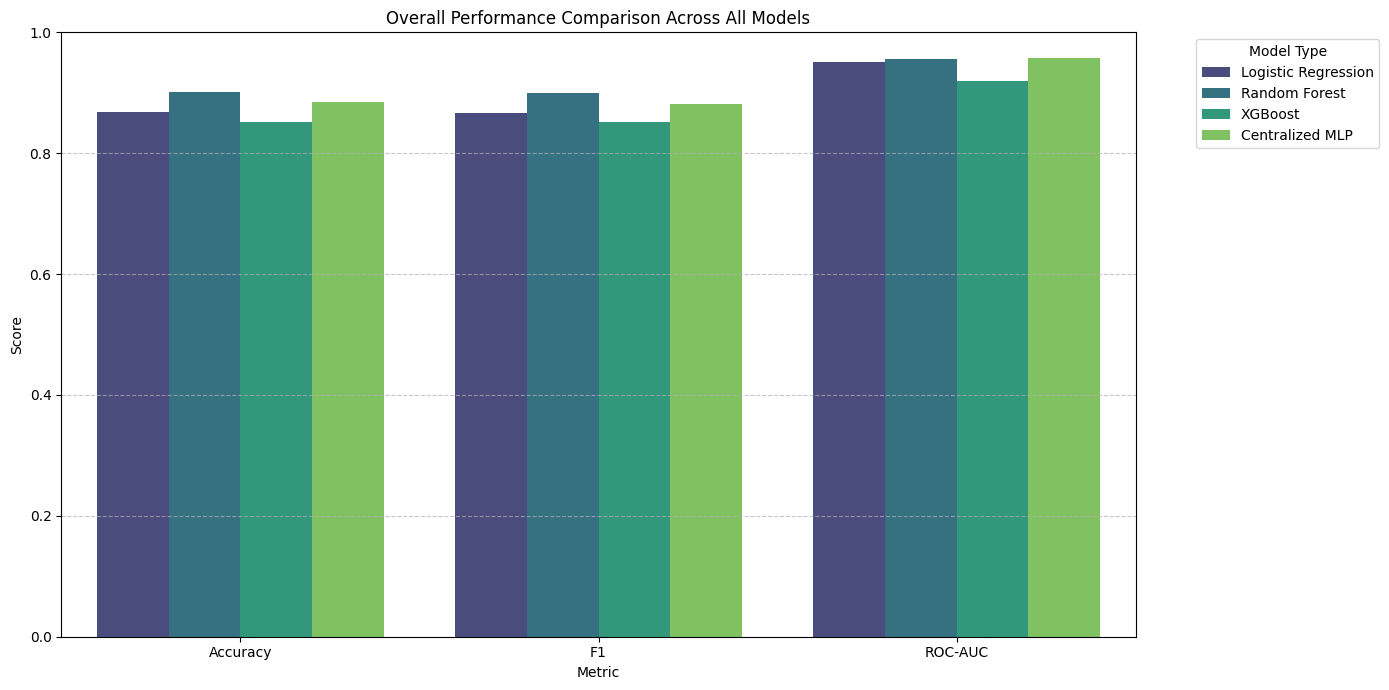

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


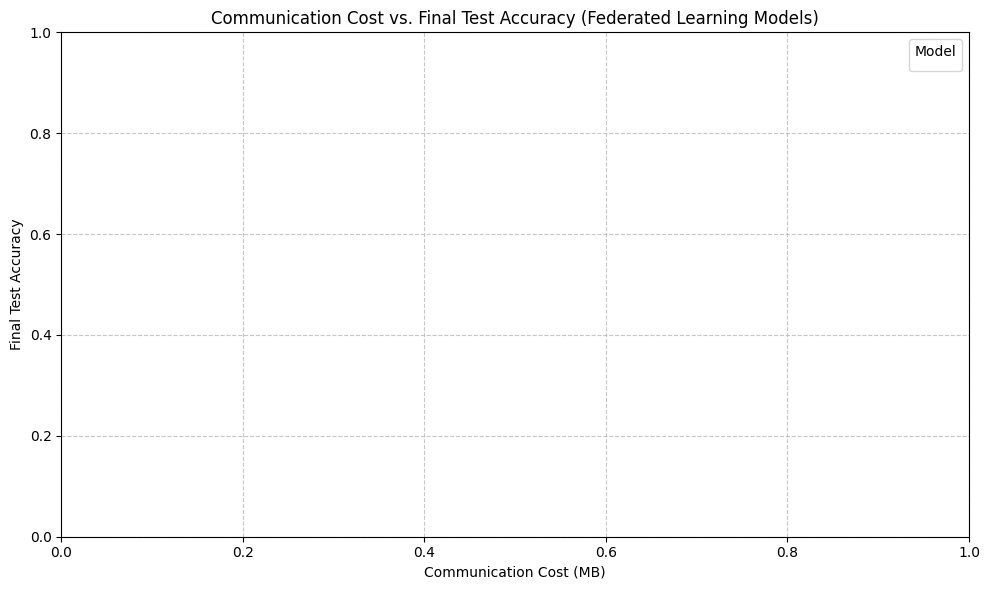

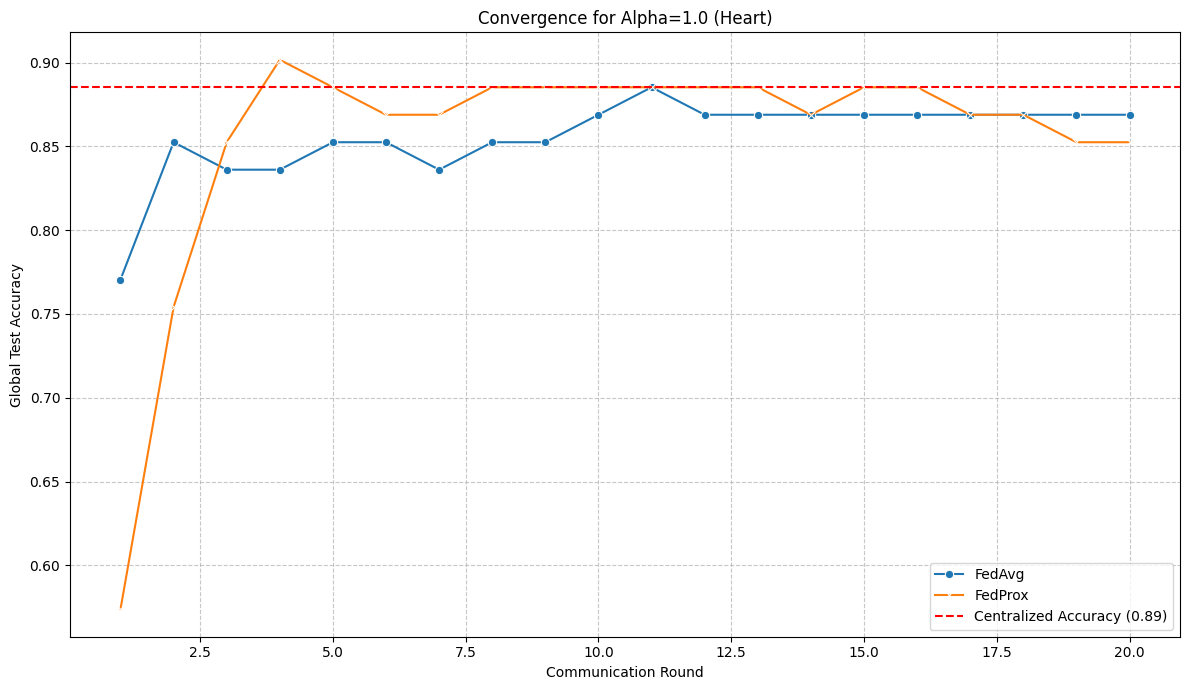

Benchmark for Heart complete.

==================== Running Seed 2/3: 100 ====================
Random seeds set for reproducibility (Seed: 100).

Starting full benchmark for dataset: Heart
Random seeds set for reproducibility (Seed: 100).

--- Preparing Dataset: Heart ---
Dataset 'heart' prepared: X_train.shape=(242, 13), X_test.shape=(61, 13), input_dim=13

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:53:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6630, Current LR: 0.001000
  Early stopping at epoch 19

  Centralized MLP Test Metrics: {'Accuracy': 0.8032786885245902, 'Precision': 0.8333333333333334, 'Recall': 0.7142857142857143, 'F1': 0.7692307692307693, 'ROC-AUC': np.float64(0.8636363636363636)}
  Centralized MLP Training Time: 0.33 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/heart/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 100...
Partitioning successful after 27 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 2.78 seconds
  Approximate communication cost: 1.15 MB



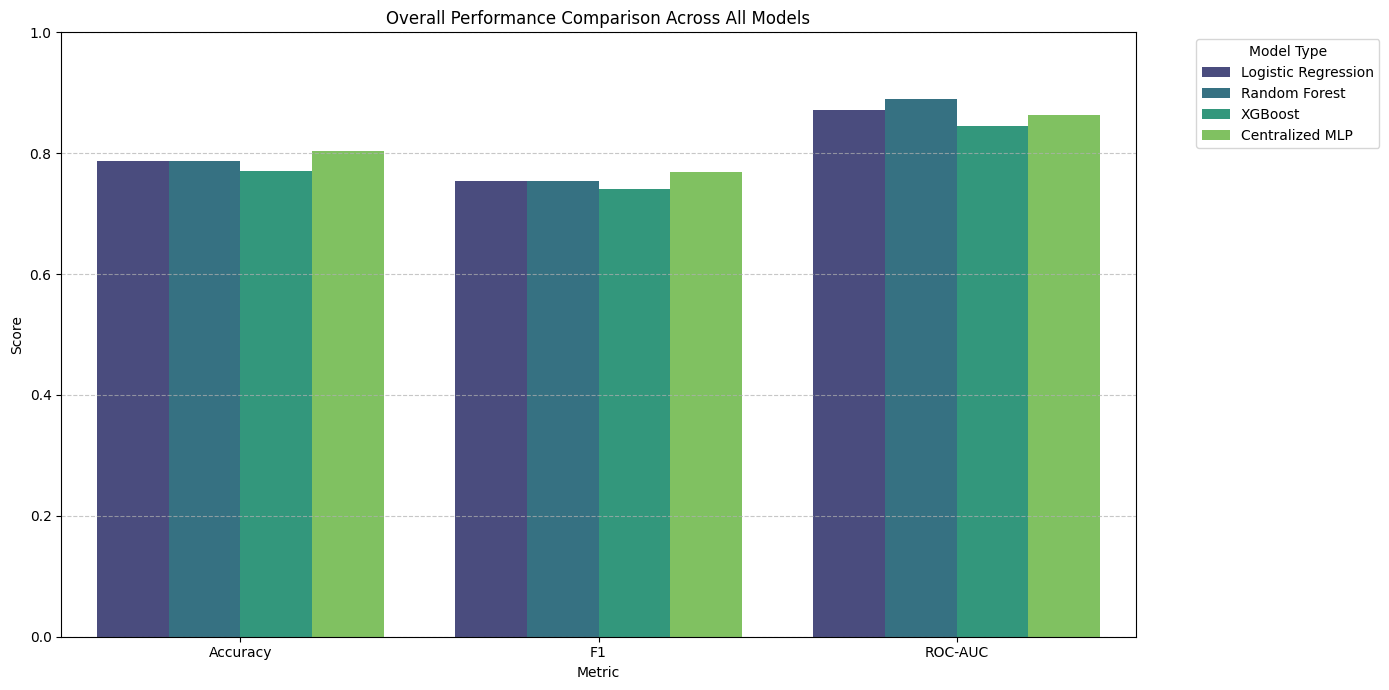

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


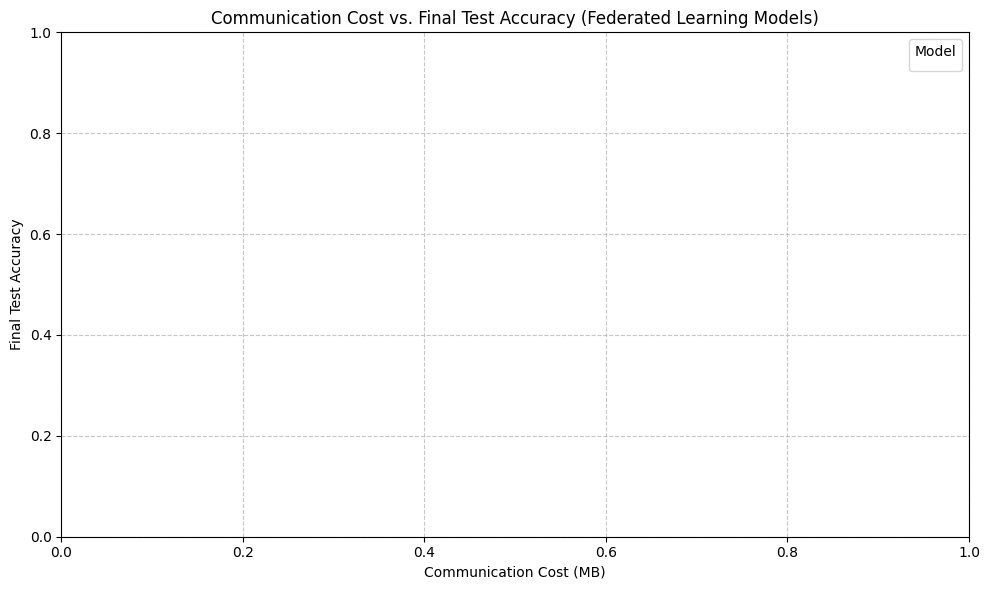

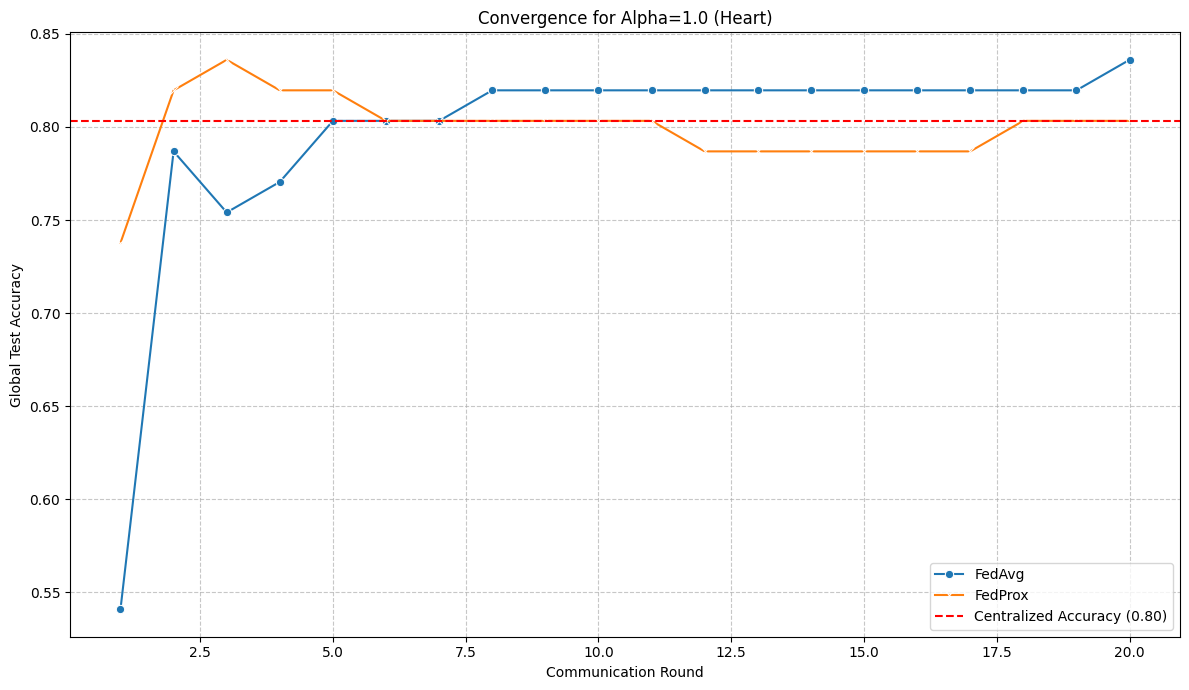

Benchmark for Heart complete.

==================== Running Seed 3/3: 200 ====================
Random seeds set for reproducibility (Seed: 200).

Starting full benchmark for dataset: Heart
Random seeds set for reproducibility (Seed: 200).

--- Preparing Dataset: Heart ---
Dataset 'heart' prepared: X_train.shape=(242, 13), X_test.shape=(61, 13), input_dim=13

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:54:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6732, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.3010, Current LR: 0.000500
  Early stopping at epoch 25

  Centralized MLP Test Metrics: {'Accuracy': 0.8524590163934426, 'Precision': 0.8064516129032258, 'Recall': 0.8928571428571429, 'F1': 0.847457627118644, 'ROC-AUC': np.float64(0.922077922077922)}
  Centralized MLP Training Time: 0.45 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/heart/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 200...
Partitioning successful after 93 attempt(s) with min_client_size=20.
  Total FedAvg runti

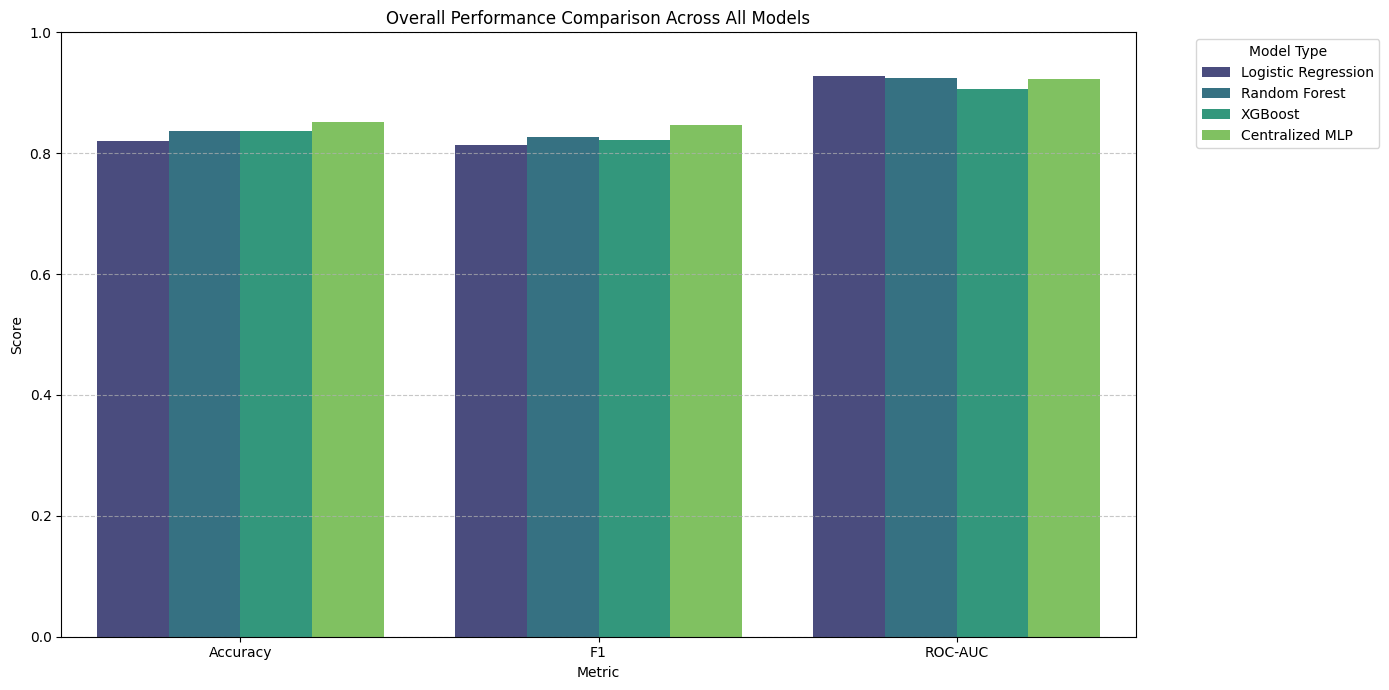

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


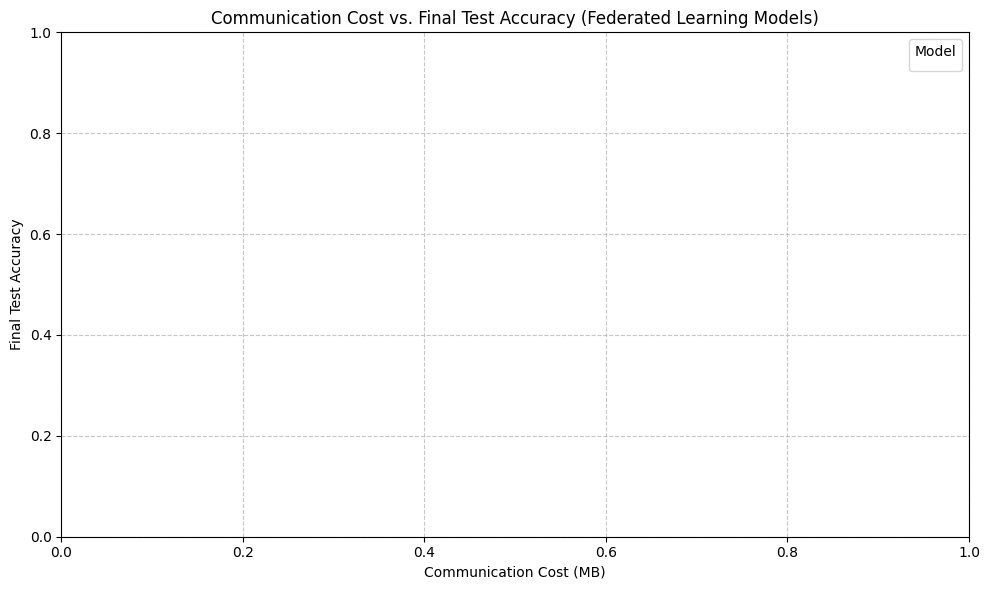

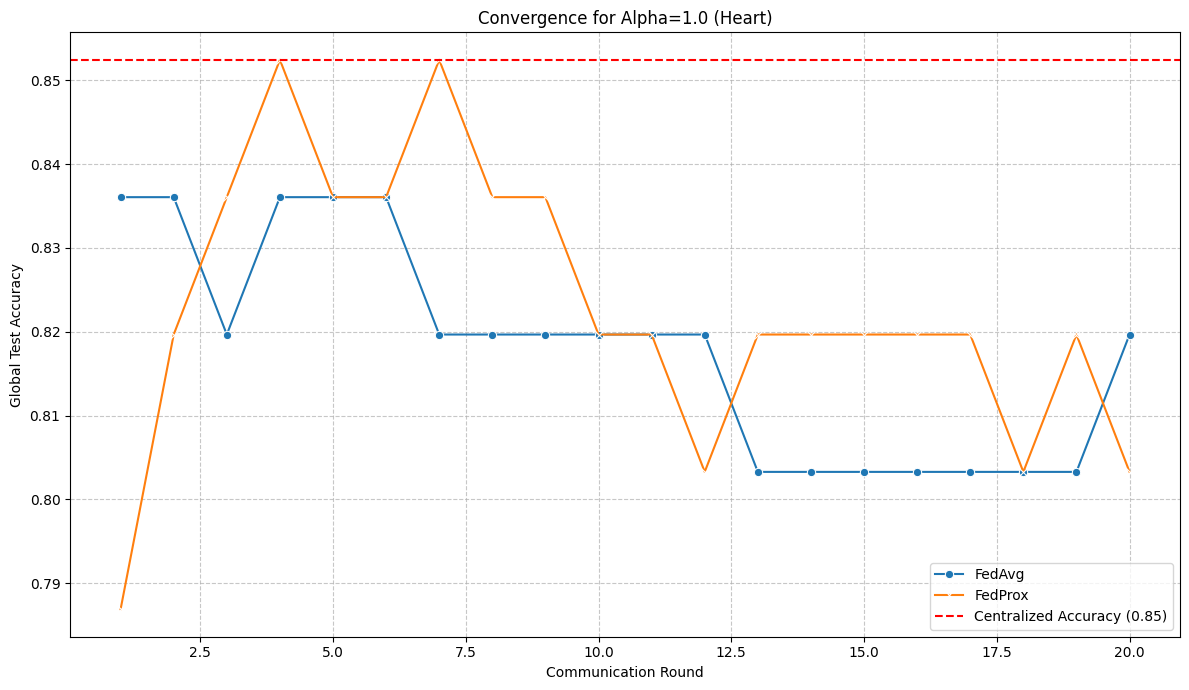

Benchmark for Heart complete.
Aggregated multi-seed metrics saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/multi_seed_aggregated_metrics.csv
Raw multi-seed comparison data saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/multi_seed_raw_comparison.csv
Raw multi-seed convergence data saved to /content/drive/MyDrive/federated_learning/results/heart/csvs/multi_seed_raw_convergence.csv
Multi-seed benchmark for Heart complete.

Starting Local Epoch Ablation for Heart (FedAvg)

--- Preparing Dataset: Heart ---
Dataset 'heart' prepared: X_train.shape=(242, 13), X_test.shape=(61, 13), input_dim=13

--- Running FedAvg with Local Epochs = 3 (Alpha=1.0, Mu=0.0) ---

Starting FedAvg experiment (alpha=1.0, mu=0.0, lr=0.001, bs=32, epochs=3) with seed 42...
Partitioning successful after 2 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 2.26 seconds
  Approximate communication cost: 1.15 MB

--- Running FedAvg with Local Epochs = 5 (Alpha=1.0, Mu

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:54:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6393, Current LR: 0.001000
  Early stopping at epoch 15

  Centralized MLP Test Metrics: {'Accuracy': 0.7142857142857143, 'Precision': 0.5961538461538461, 'Recall': 0.5740740740740741, 'F1': 0.5849056603773585, 'ROC-AUC': np.float64(0.8075925925925926)}
  Centralized MLP Training Time: 0.72 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/pima/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 42...
Partitioning successful after 3 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 5.08 seconds
  Approximate communication cost: 1.03 MB

Star

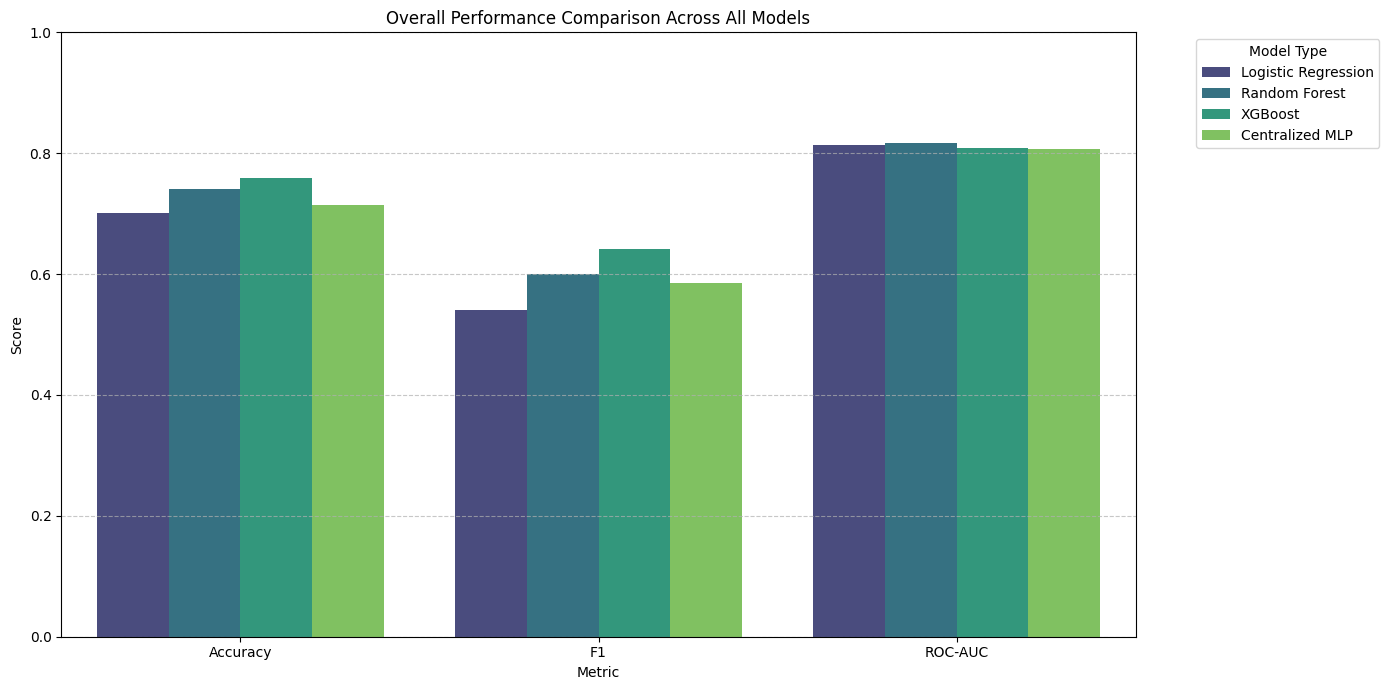

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


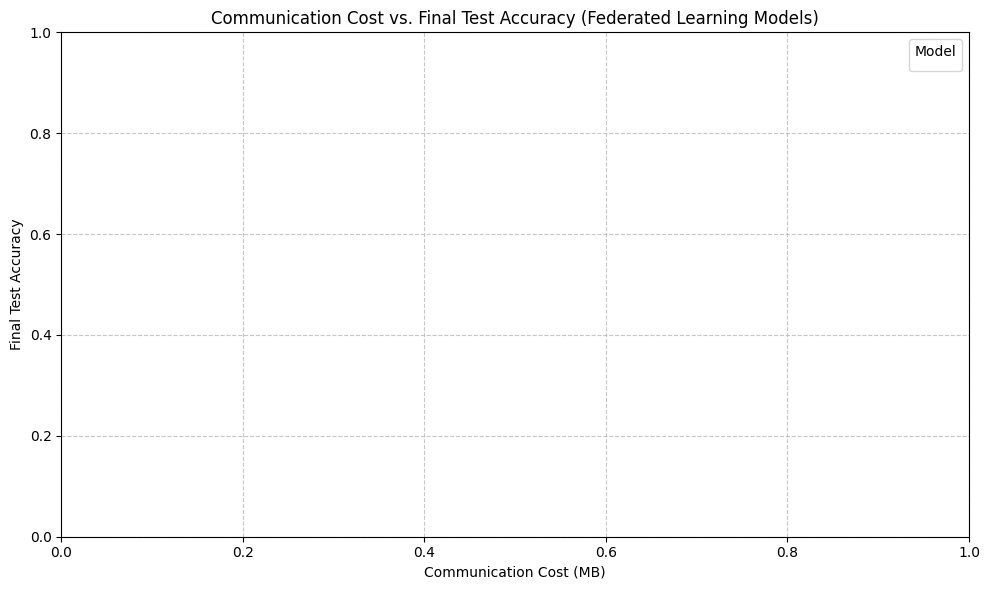

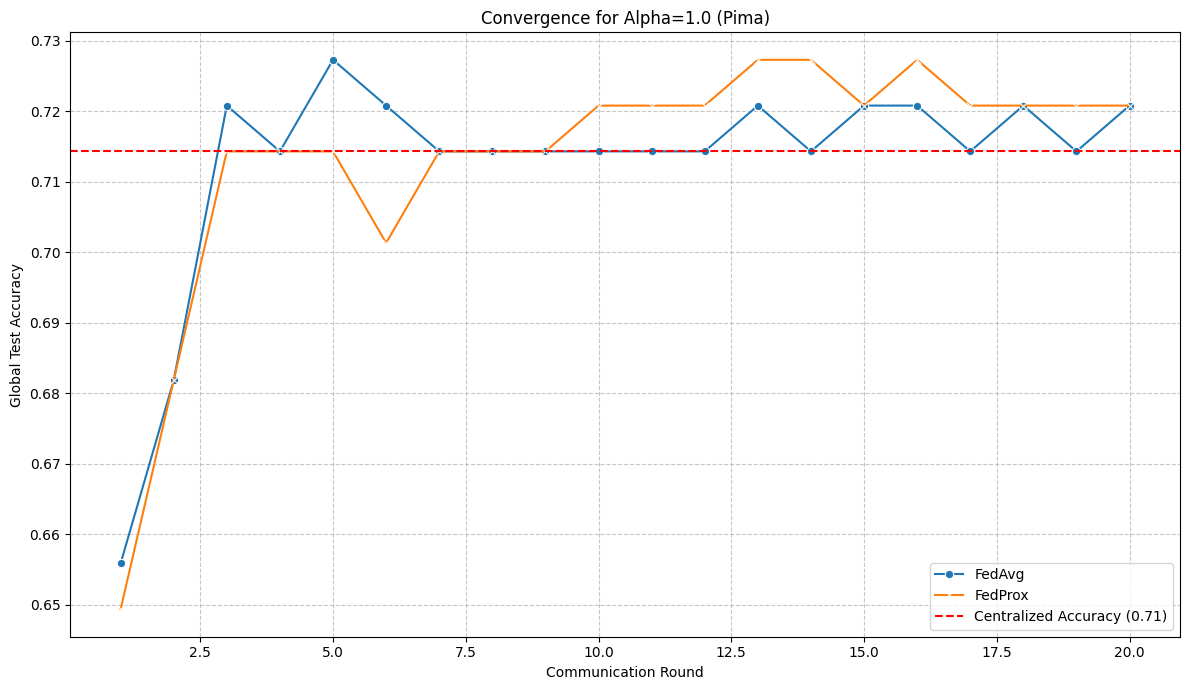

Benchmark for Pima complete.

==================== Running Seed 2/3: 100 ====================
Random seeds set for reproducibility (Seed: 100).

Starting full benchmark for dataset: Pima
Random seeds set for reproducibility (Seed: 100).

--- Preparing Dataset: Pima ---
Dataset 'pima' prepared: X_train.shape=(614, 8), X_test.shape=(154, 8), input_dim=8

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6507, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.4371, Current LR: 0.001000
  Early stopping at epoch 38

  Centralized MLP Test Metrics: {'Accuracy': 0.7467532467532467, 'Precision': 0.6666666666666666, 'Recall': 0.5555555555555556, 'F1': 0.6060606060606061, 'ROC-AUC': np.float64(0.8577777777777778)}
  Centralized MLP Training Time: 1.56 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/pima/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 100...
Partitioning successful after 25 attempt(s) with min_client_size=20.
  Total FedAvg runti

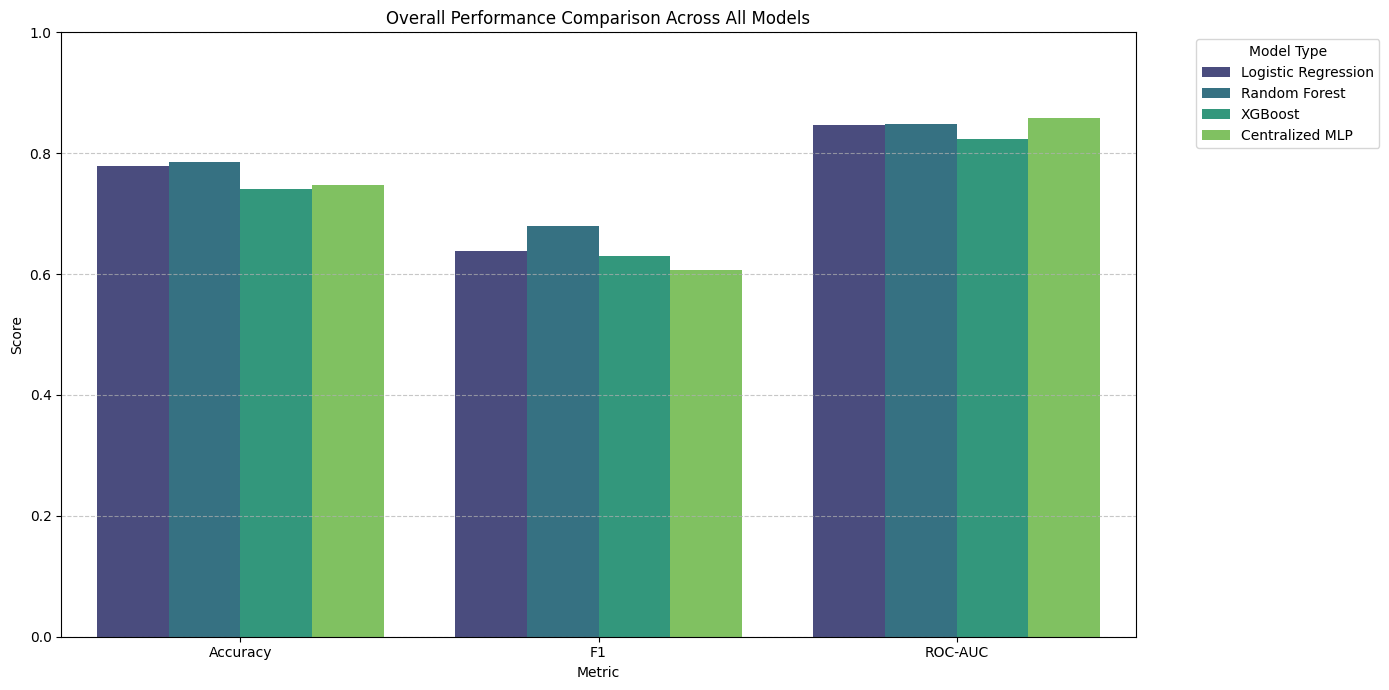

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


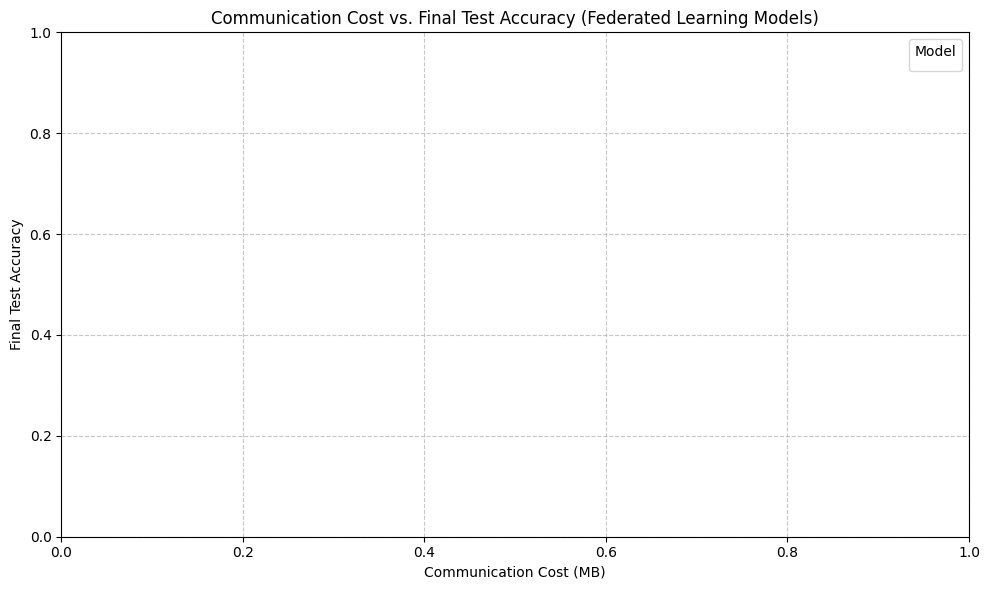

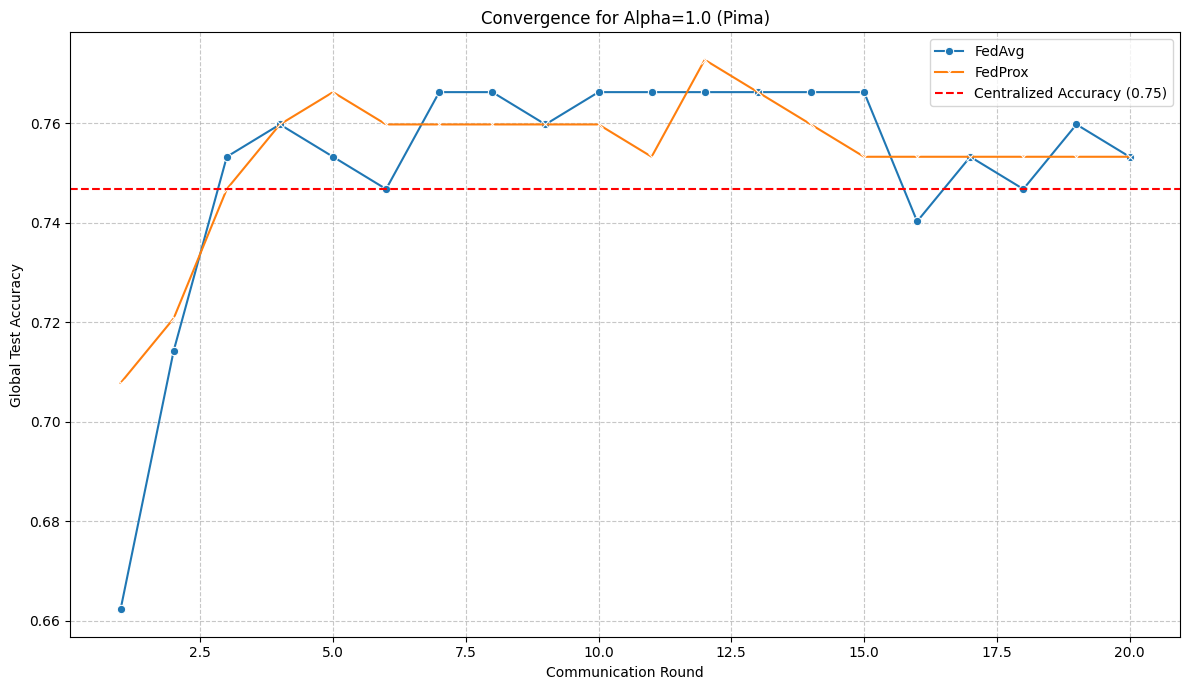

Benchmark for Pima complete.

==================== Running Seed 3/3: 200 ====================
Random seeds set for reproducibility (Seed: 200).

Starting full benchmark for dataset: Pima
Random seeds set for reproducibility (Seed: 200).

--- Preparing Dataset: Pima ---
Dataset 'pima' prepared: X_train.shape=(614, 8), X_test.shape=(154, 8), input_dim=8

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:57:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6400, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.4343, Current LR: 0.001000
  Early stopping at epoch 29

  Centralized MLP Test Metrics: {'Accuracy': 0.7857142857142857, 'Precision': 0.7058823529411765, 'Recall': 0.6666666666666666, 'F1': 0.6857142857142857, 'ROC-AUC': np.float64(0.8794444444444445)}
  Centralized MLP Training Time: 1.22 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/pima/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 200...
Partitioning successful after 85 attempt(s) with min_client_size=20.
  Total FedAvg runti

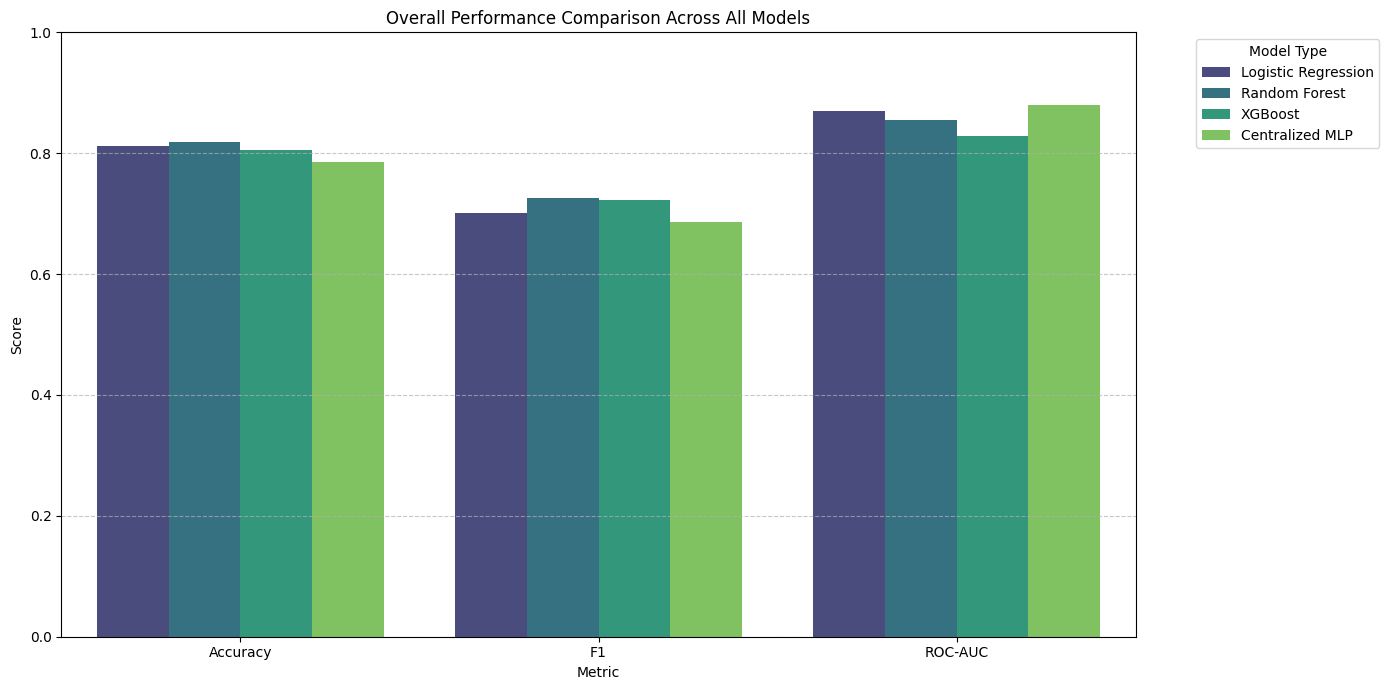

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


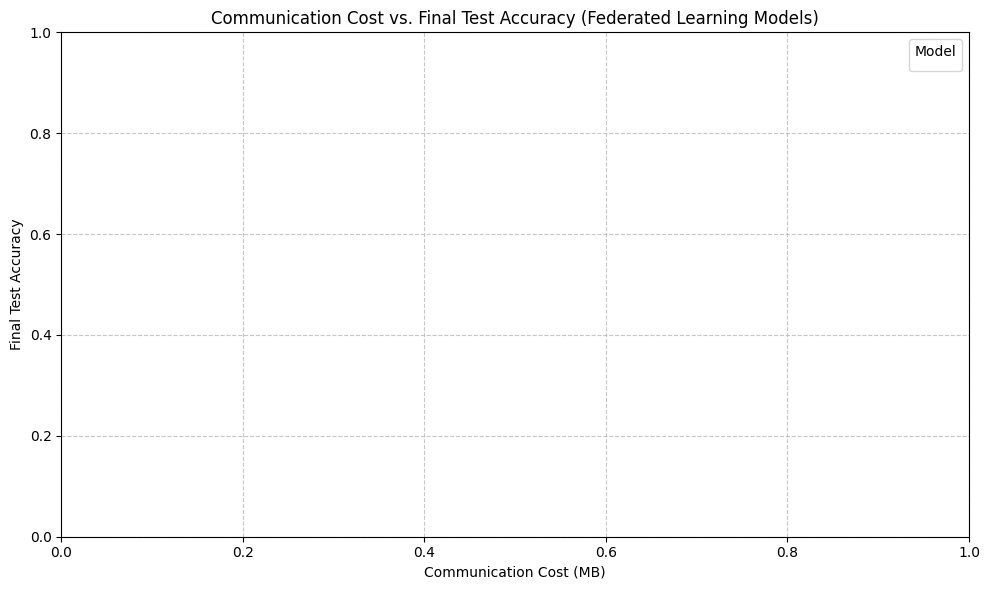

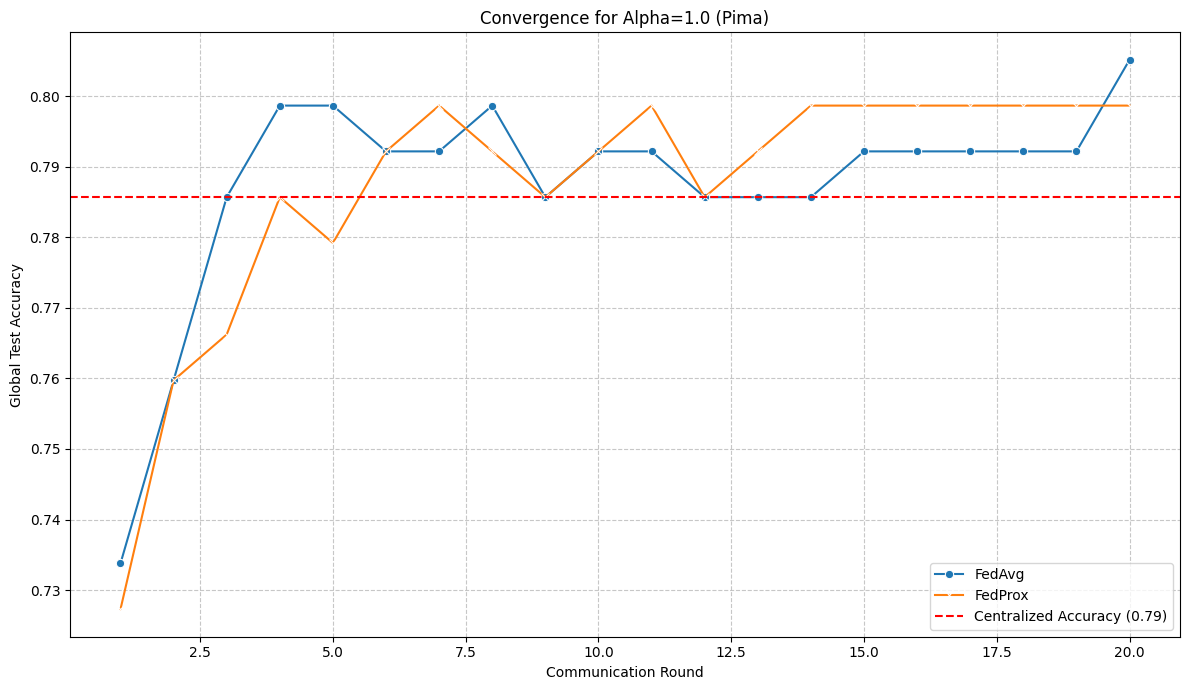

Benchmark for Pima complete.
Aggregated multi-seed metrics saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/multi_seed_aggregated_metrics.csv
Raw multi-seed comparison data saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/multi_seed_raw_comparison.csv
Raw multi-seed convergence data saved to /content/drive/MyDrive/federated_learning/results/pima/csvs/multi_seed_raw_convergence.csv
Multi-seed benchmark for Pima complete.

Starting Local Epoch Ablation for Pima (FedAvg)

--- Preparing Dataset: Pima ---
Dataset 'pima' prepared: X_train.shape=(614, 8), X_test.shape=(154, 8), input_dim=8

--- Running FedAvg with Local Epochs = 3 (Alpha=1.0, Mu=0.0) ---

Starting FedAvg experiment (alpha=1.0, mu=0.0, lr=0.001, bs=32, epochs=3) with seed 42...
Partitioning successful after 2 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 3.18 seconds
  Approximate communication cost: 1.03 MB

--- Running FedAvg with Local Epochs = 5 (Alpha=1.0, Mu=0.0) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.5761, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.0688, Current LR: 0.000500
  Epoch 40/100, Validation Loss: 0.0590, Current LR: 0.000250
  Early stopping at epoch 50

  Centralized MLP Test Metrics: {'Accuracy': 0.9824561403508771, 'Precision': 1.0, 'Recall': 0.9523809523809523, 'F1': 0.975609756097561, 'ROC-AUC': np.float64(0.9973544973544973)}
  Centralized MLP Training Time: 1.69 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 42...
Partitioning successful af

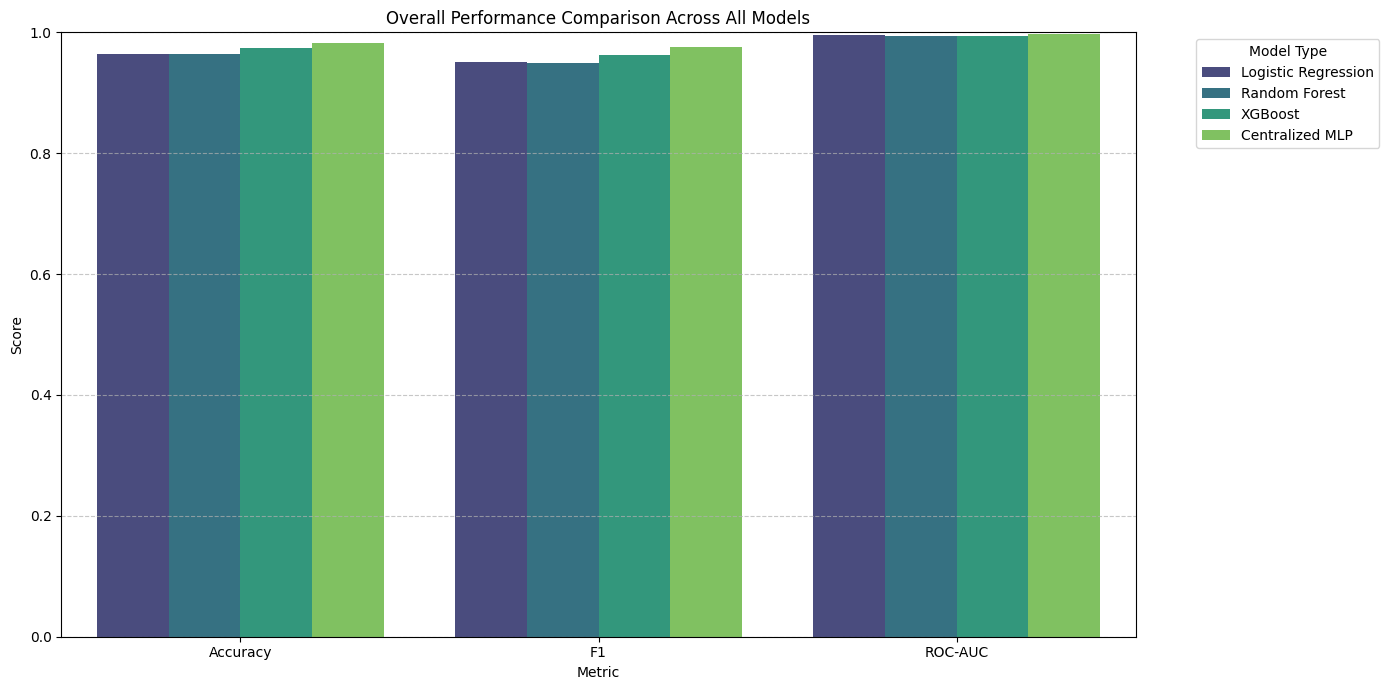

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


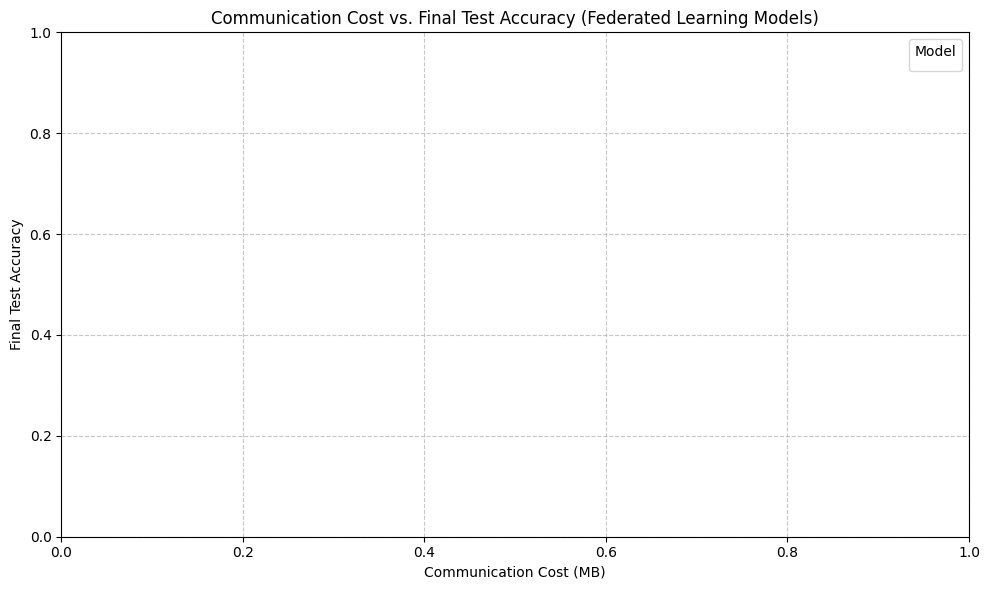

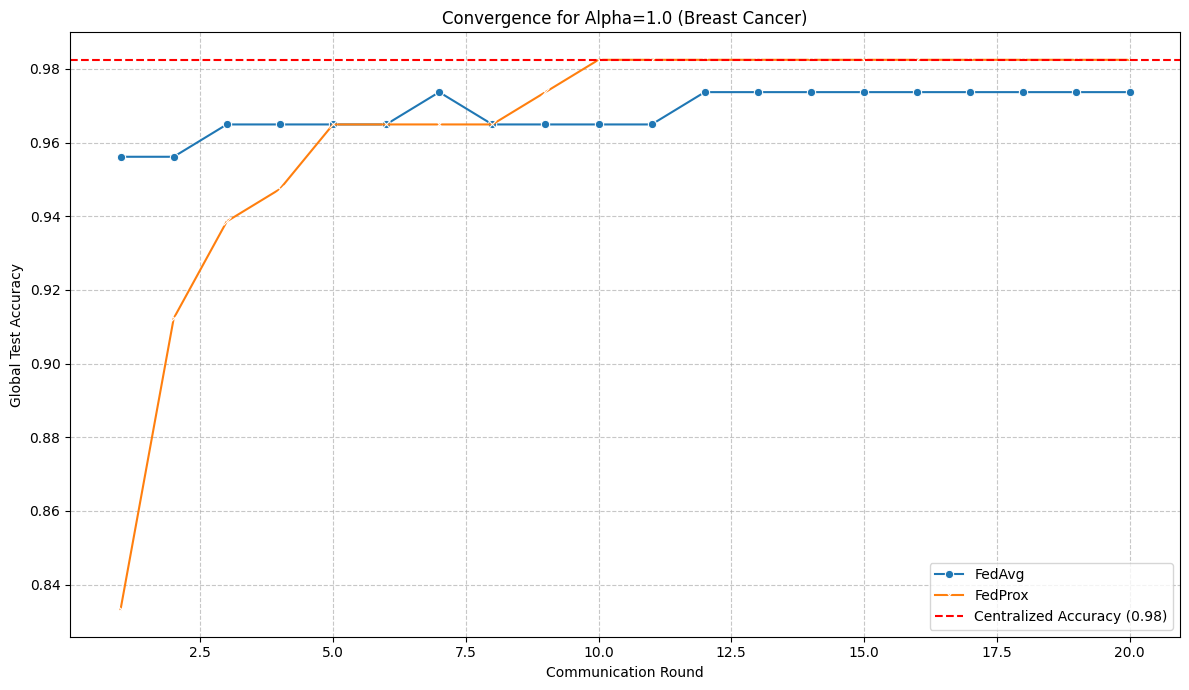

Benchmark for Breast Cancer complete.

==================== Running Seed 2/3: 100 ====================
Random seeds set for reproducibility (Seed: 100).

Starting full benchmark for dataset: Breast Cancer
Random seeds set for reproducibility (Seed: 100).

--- Preparing Dataset: Breast Cancer ---
Dataset 'breast_cancer' prepared: X_train.shape=(455, 30), X_test.shape=(114, 30), input_dim=30

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:59:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.5528, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.0925, Current LR: 0.000500
  Early stopping at epoch 24

  Centralized MLP Test Metrics: {'Accuracy': 0.9649122807017544, 'Precision': 0.9318181818181818, 'Recall': 0.9761904761904762, 'F1': 0.9534883720930233, 'ROC-AUC': np.float64(0.9990079365079365)}
  Centralized MLP Training Time: 0.82 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 100...
Partitioning successful after 14 attempt(s) with min_client_size=20.
  

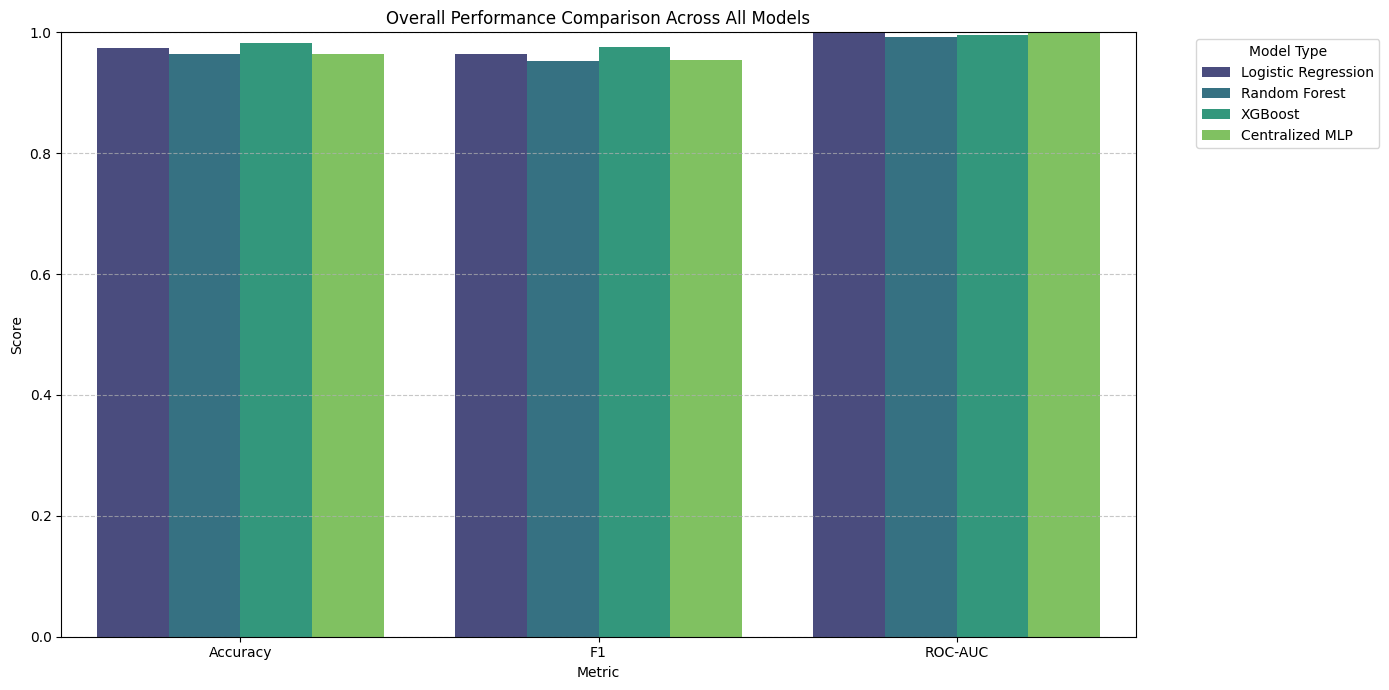

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


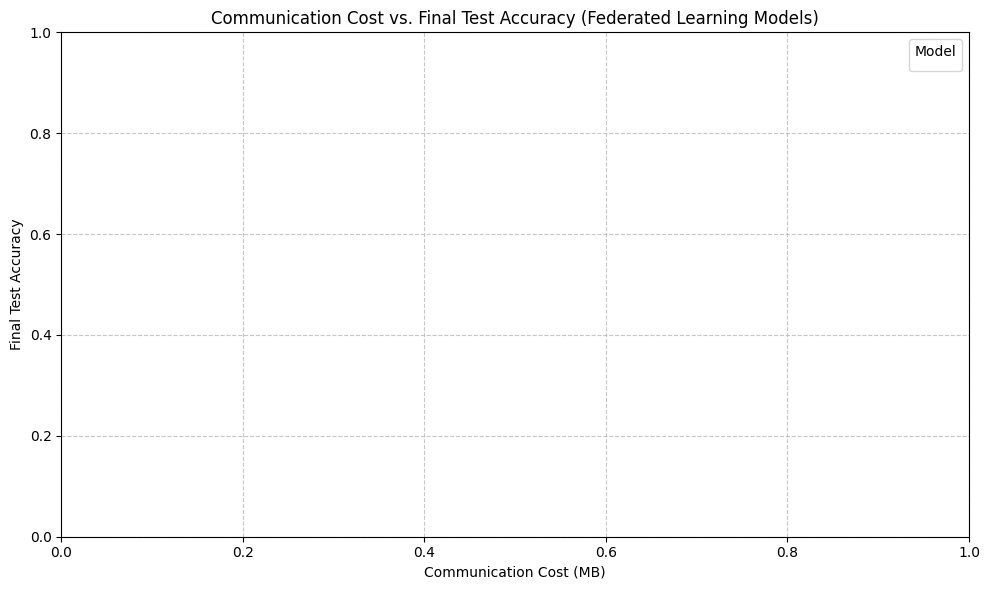

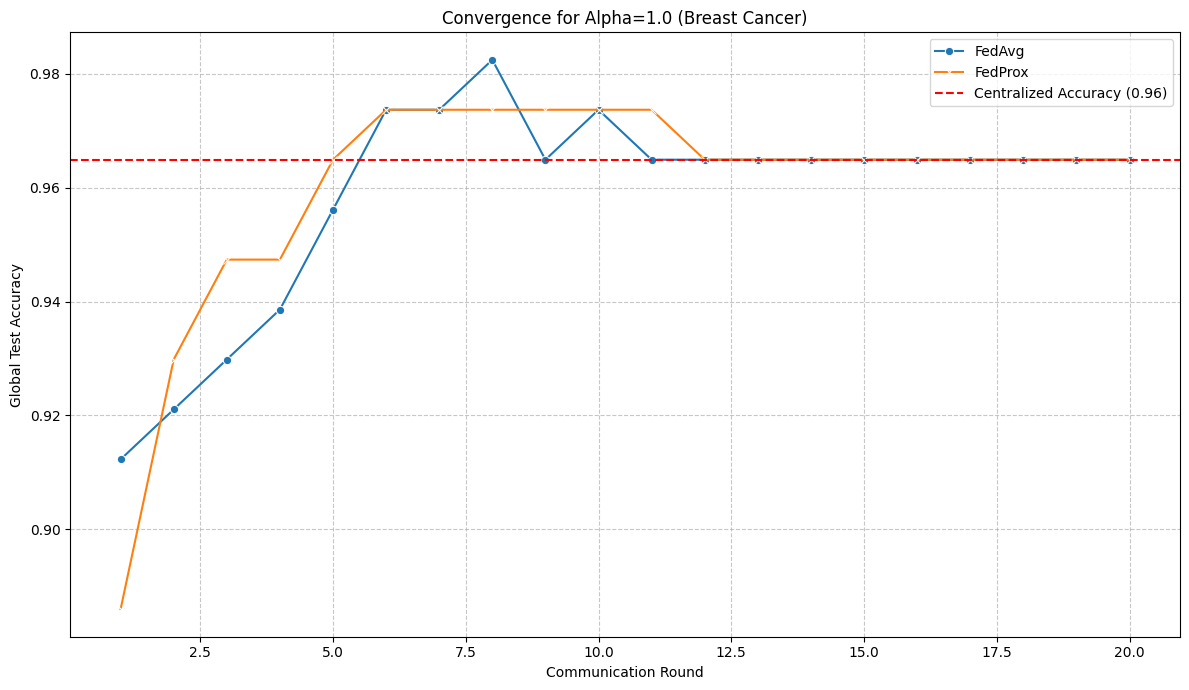

Benchmark for Breast Cancer complete.

==================== Running Seed 3/3: 200 ====================
Random seeds set for reproducibility (Seed: 200).

Starting full benchmark for dataset: Breast Cancer
Random seeds set for reproducibility (Seed: 200).

--- Preparing Dataset: Breast Cancer ---
Dataset 'breast_cancer' prepared: X_train.shape=(455, 30), X_test.shape=(114, 30), input_dim=30

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:00:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.5856, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.0374, Current LR: 0.001000
  Epoch 40/100, Validation Loss: 0.0238, Current LR: 0.000500
  Epoch 60/100, Validation Loss: 0.0182, Current LR: 0.000250
  Early stopping at epoch 65

  Centralized MLP Test Metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC-AUC': np.float64(1.0)}
  Centralized MLP Training Time: 2.10 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 200...
Partitioning successfu

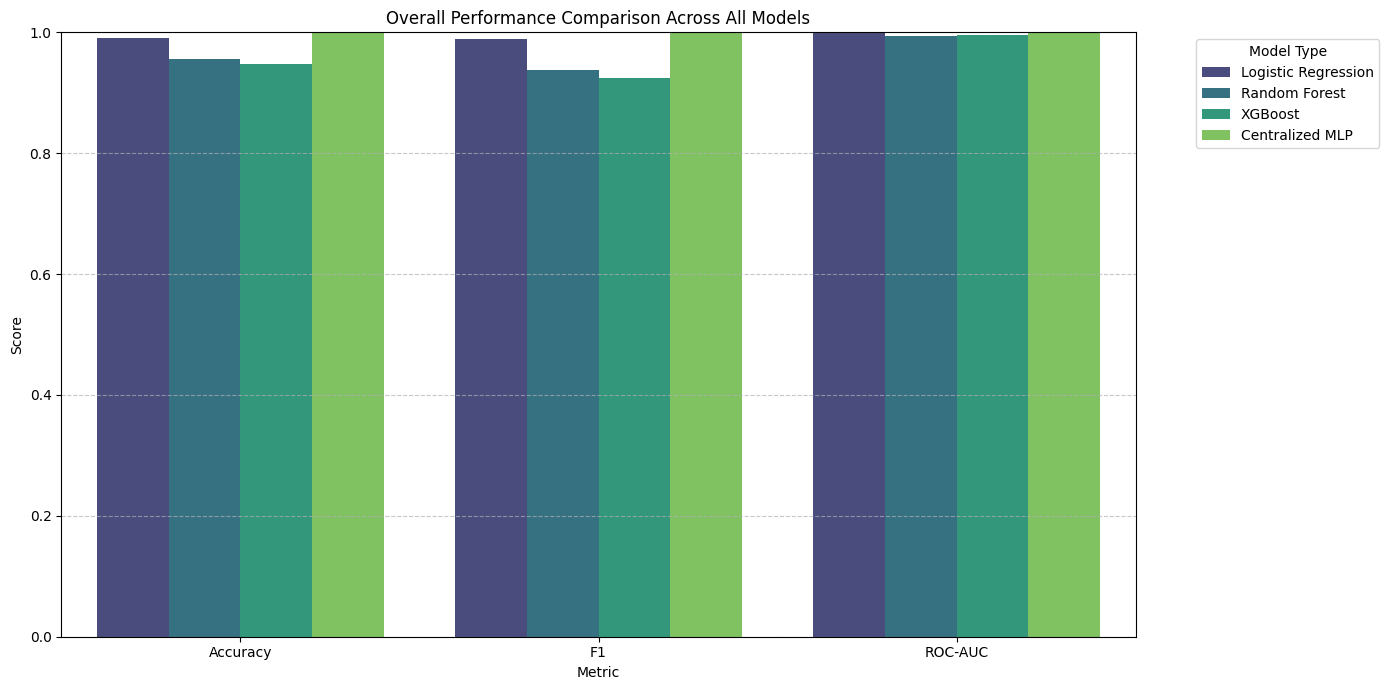

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


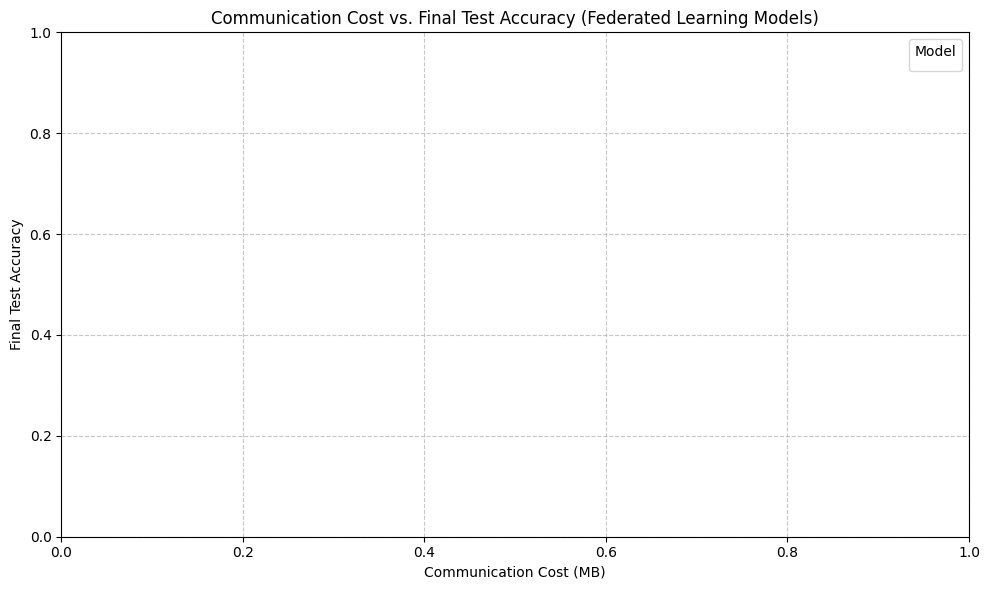

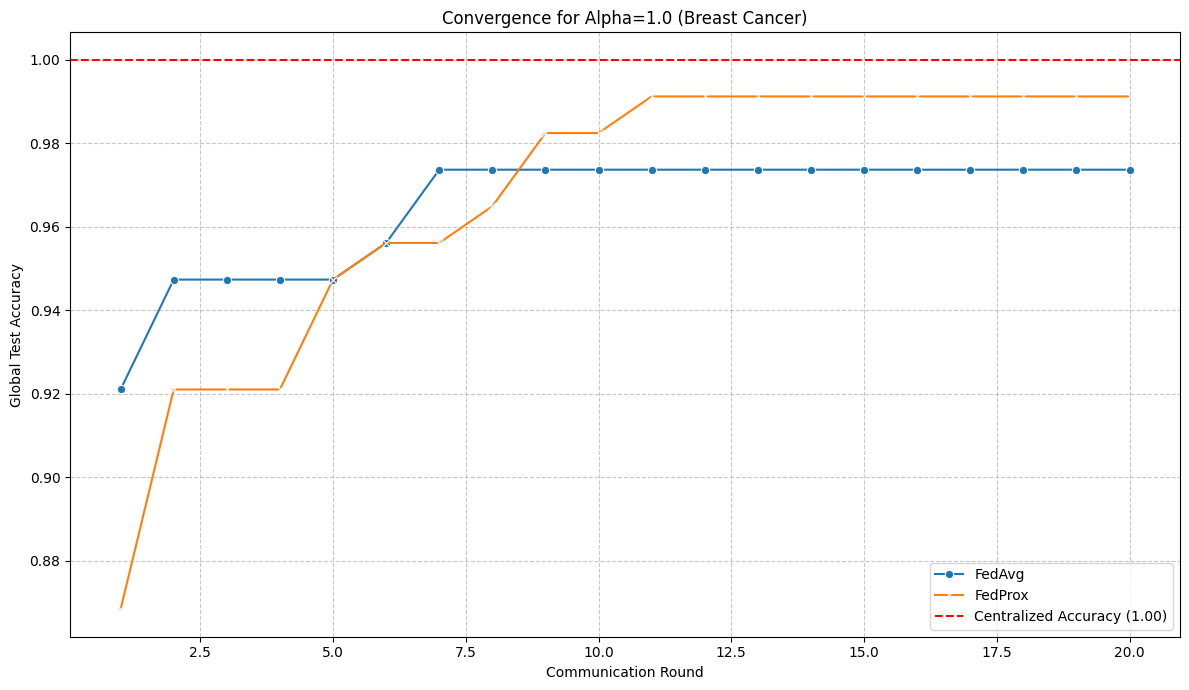

Benchmark for Breast Cancer complete.
Aggregated multi-seed metrics saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/multi_seed_aggregated_metrics.csv
Raw multi-seed comparison data saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/multi_seed_raw_comparison.csv
Raw multi-seed convergence data saved to /content/drive/MyDrive/federated_learning/results/breast_cancer/csvs/multi_seed_raw_convergence.csv
Multi-seed benchmark for Breast Cancer complete.

Starting Local Epoch Ablation for Breast Cancer (FedAvg)

--- Preparing Dataset: Breast Cancer ---
Dataset 'breast_cancer' prepared: X_train.shape=(455, 30), X_test.shape=(114, 30), input_dim=30

--- Running FedAvg with Local Epochs = 3 (Alpha=1.0, Mu=0.0) ---

Starting FedAvg experiment (alpha=1.0, mu=0.0, lr=0.001, bs=32, epochs=3) with seed 42...
Partitioning successful after 3 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 2.40 seconds
  Approximate communication cost:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:01:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6763, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.1622, Current LR: 0.001000
  Epoch 40/100, Validation Loss: 0.1432, Current LR: 0.001000
  Epoch 60/100, Validation Loss: 0.1329, Current LR: 0.001000
  Epoch 80/100, Validation Loss: 0.1264, Current LR: 0.001000
  Epoch 100/100, Validation Loss: 0.1152, Current LR: 0.001000

  Centralized MLP Test Metrics: {'Accuracy': 0.95, 'Precision': 1.0, 'Recall': 0.92, 'F1': 0.9583333333333334, 'ROC-AUC': np.float64(1.0)}
  Centralized MLP Training Time: 2.47 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/kidney/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAv

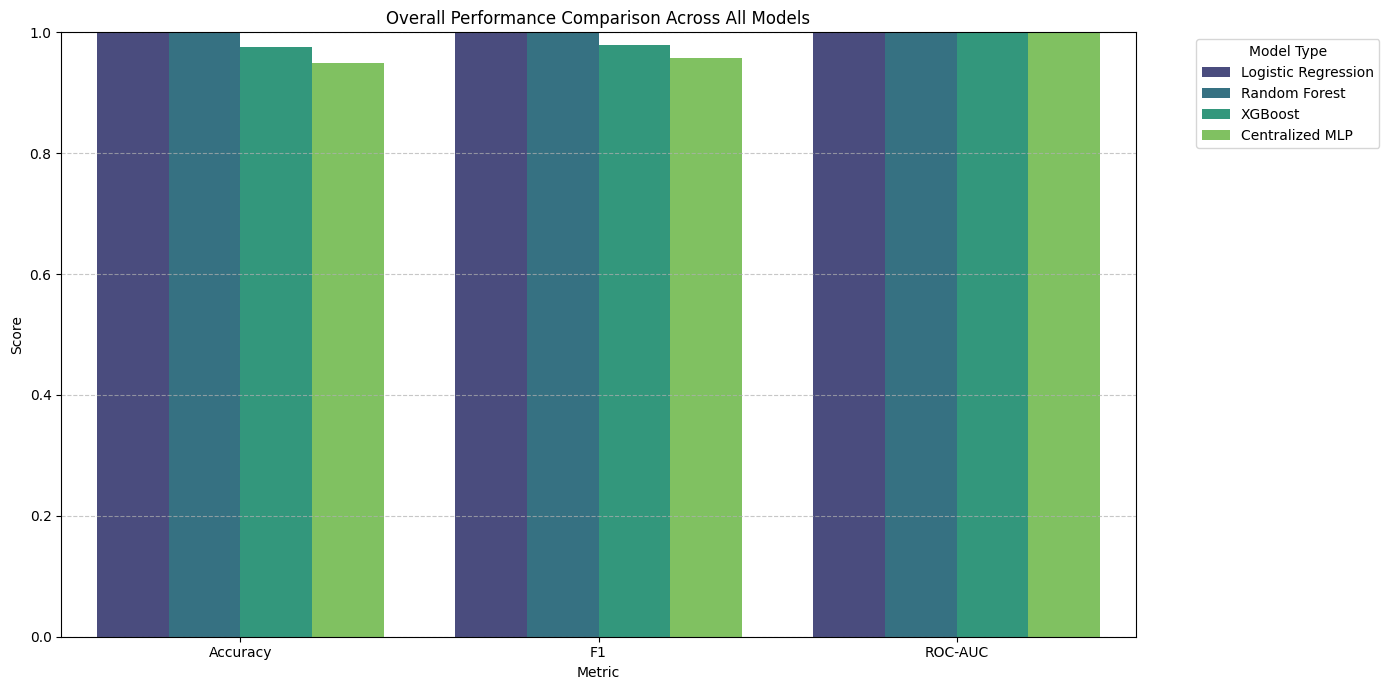

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


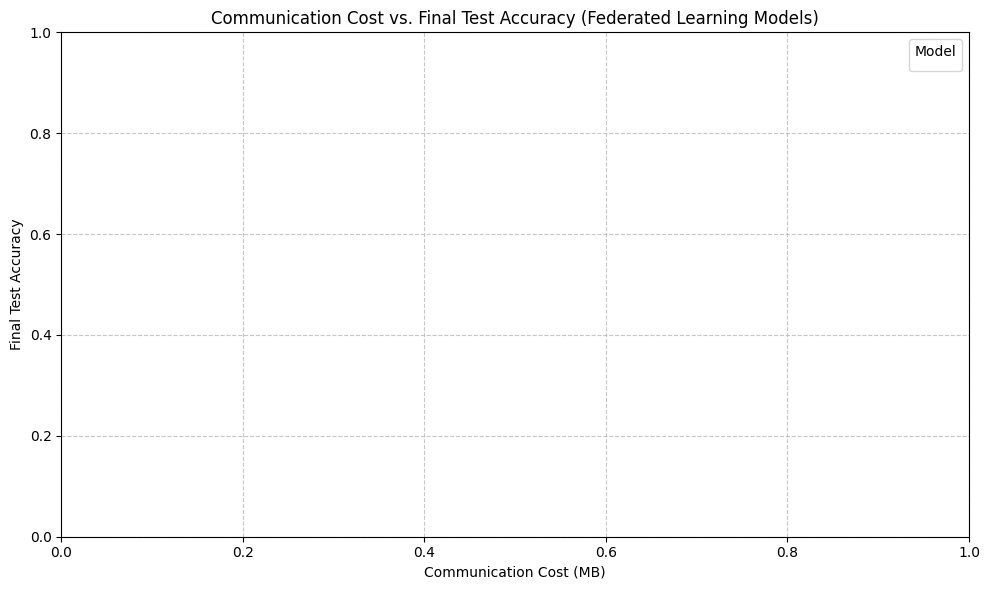

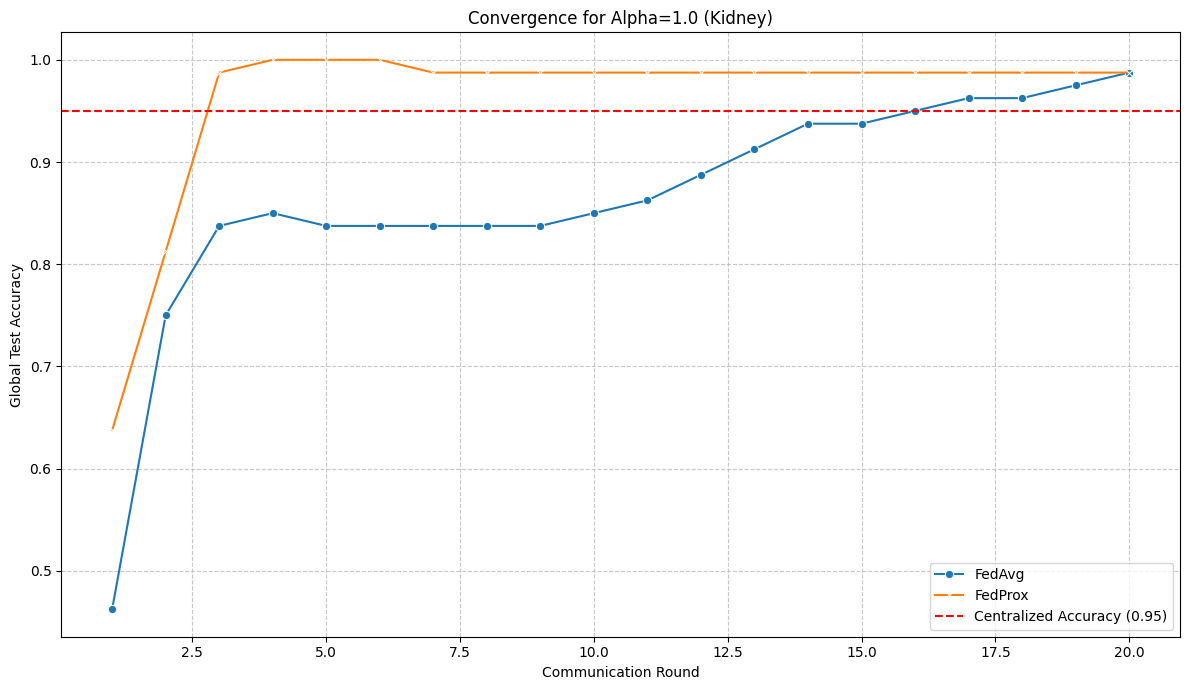

Benchmark for Kidney complete.

==================== Running Seed 2/3: 100 ====================
Random seeds set for reproducibility (Seed: 100).

Starting full benchmark for dataset: Kidney
Random seeds set for reproducibility (Seed: 100).

--- Preparing Dataset: Kidney ---
Dataset 'kidney' prepared: X_train.shape=(320, 822), X_test.shape=(80, 822), input_dim=822

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:02:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6649, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.1732, Current LR: 0.001000
  Epoch 40/100, Validation Loss: 0.1553, Current LR: 0.001000
  Epoch 60/100, Validation Loss: 0.1442, Current LR: 0.001000
  Epoch 80/100, Validation Loss: 0.1268, Current LR: 0.001000
  Epoch 100/100, Validation Loss: 0.1131, Current LR: 0.001000

  Centralized MLP Test Metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC-AUC': np.float64(1.0)}
  Centralized MLP Training Time: 2.71 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/kidney/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alp

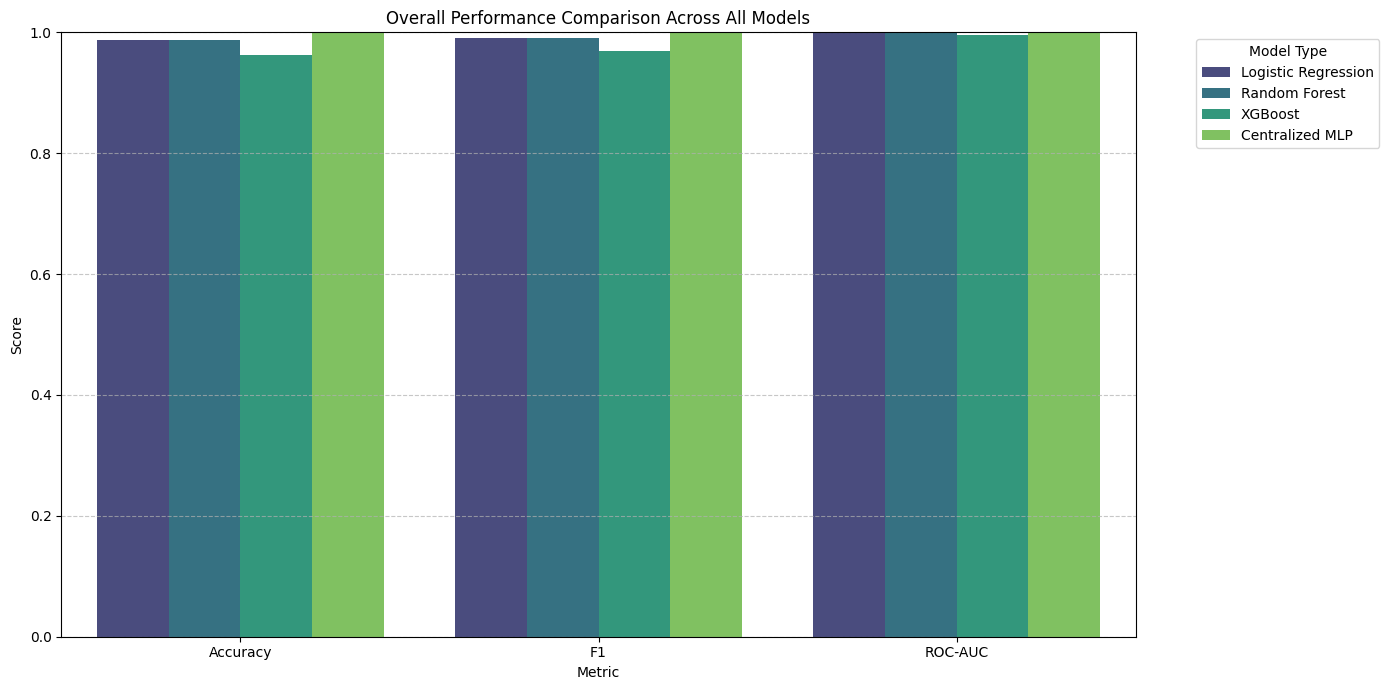

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


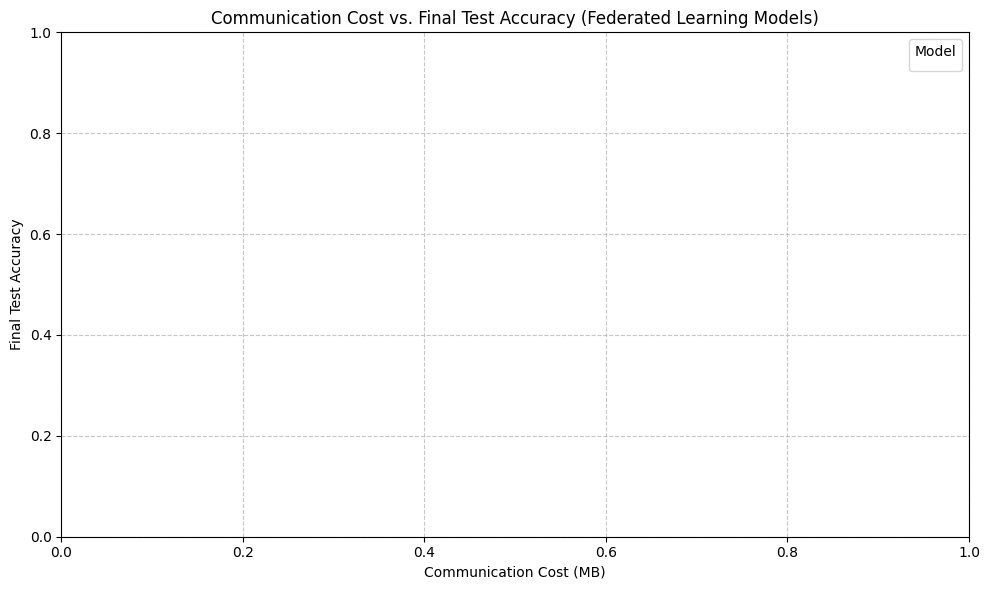

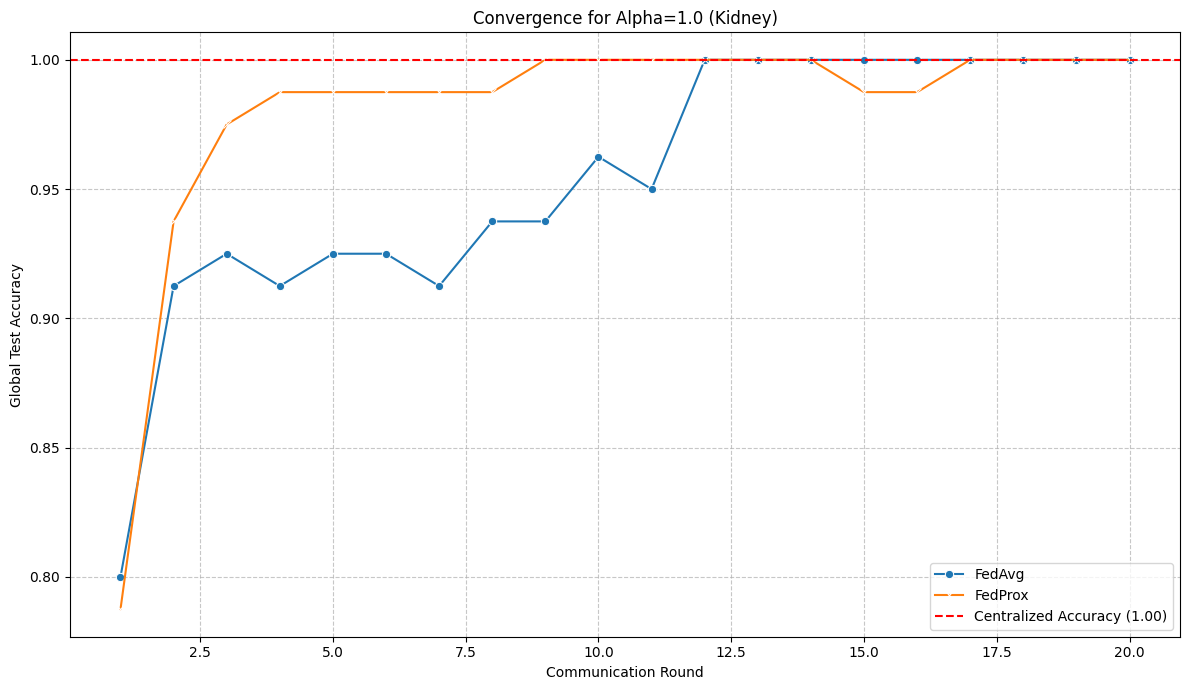

Benchmark for Kidney complete.

==================== Running Seed 3/3: 200 ====================
Random seeds set for reproducibility (Seed: 200).

Starting full benchmark for dataset: Kidney
Random seeds set for reproducibility (Seed: 200).

--- Preparing Dataset: Kidney ---
Dataset 'kidney' prepared: X_train.shape=(320, 822), X_test.shape=(80, 822), input_dim=822

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:02:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.6748, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.1826, Current LR: 0.001000
  Epoch 40/100, Validation Loss: 0.1644, Current LR: 0.001000
  Epoch 60/100, Validation Loss: 0.1443, Current LR: 0.001000
  Epoch 80/100, Validation Loss: 0.1223, Current LR: 0.001000
  Epoch 100/100, Validation Loss: 0.1034, Current LR: 0.001000

  Centralized MLP Test Metrics: {'Accuracy': 0.9875, 'Precision': 1.0, 'Recall': 0.98, 'F1': 0.98989898989899, 'ROC-AUC': np.float64(0.9993333333333333)}
  Centralized MLP Training Time: 2.83 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/kidney/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---


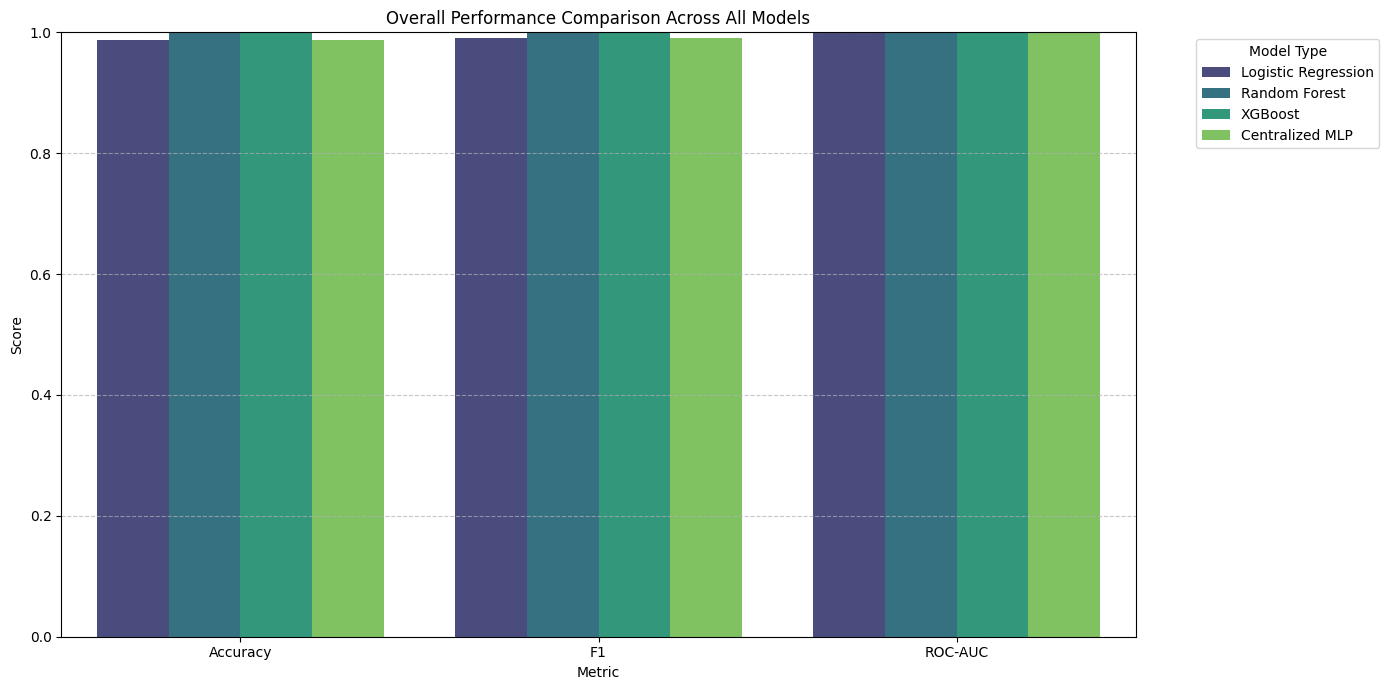

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


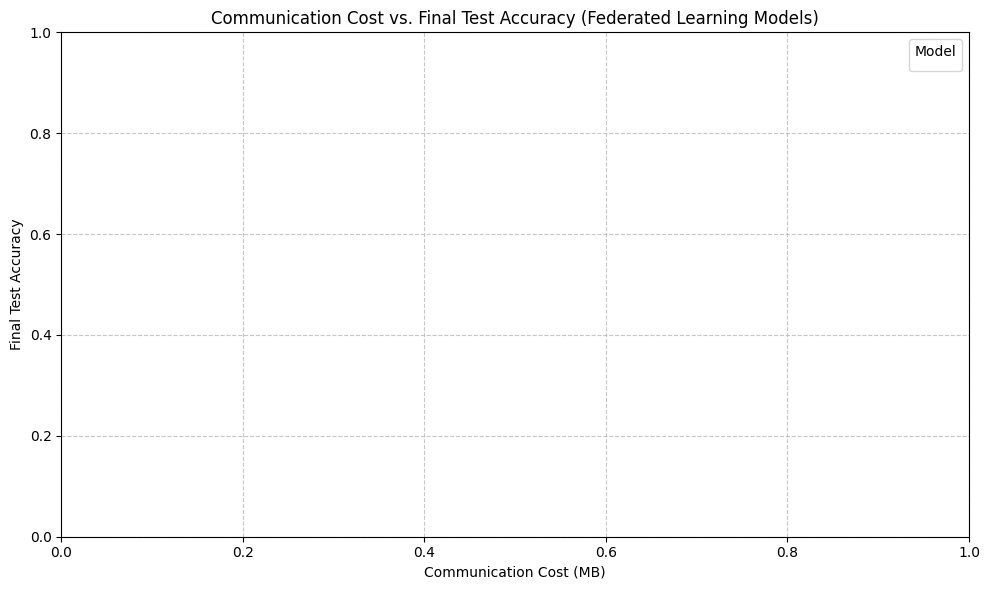

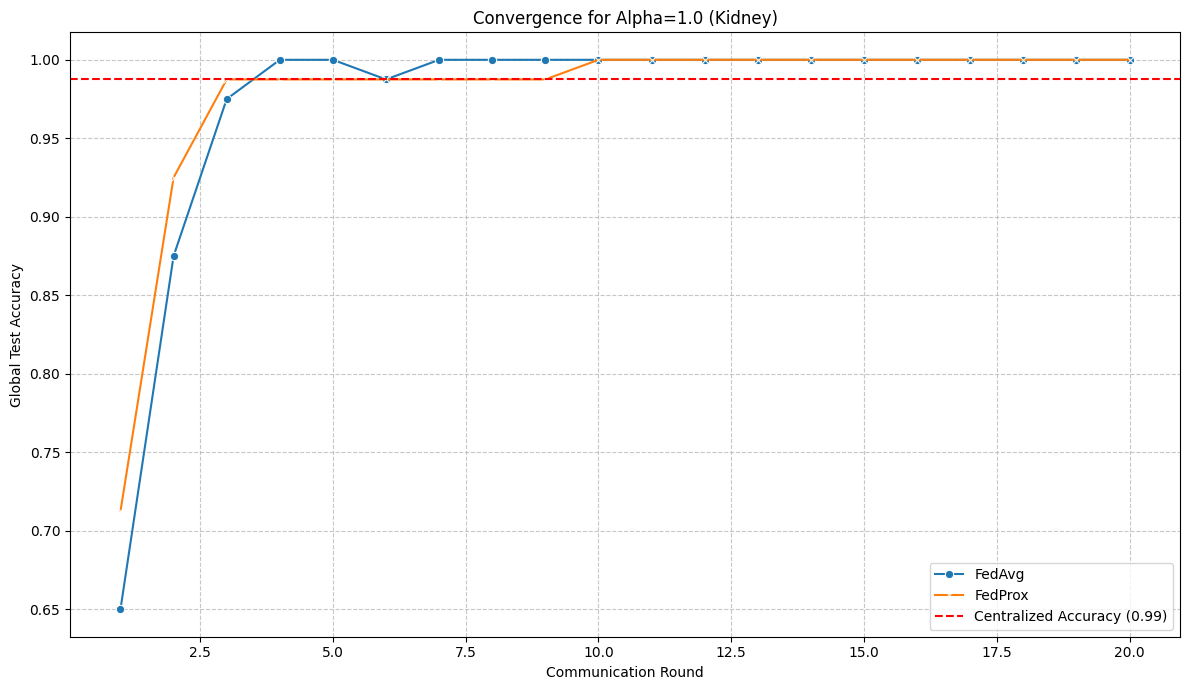

Benchmark for Kidney complete.
Aggregated multi-seed metrics saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/multi_seed_aggregated_metrics.csv
Raw multi-seed comparison data saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/multi_seed_raw_comparison.csv
Raw multi-seed convergence data saved to /content/drive/MyDrive/federated_learning/results/kidney/csvs/multi_seed_raw_convergence.csv
Multi-seed benchmark for Kidney complete.

Starting Local Epoch Ablation for Kidney (FedAvg)

--- Preparing Dataset: Kidney ---
Dataset 'kidney' prepared: X_train.shape=(320, 822), X_test.shape=(80, 822), input_dim=822

--- Running FedAvg with Local Epochs = 3 (Alpha=1.0, Mu=0.0) ---

Starting FedAvg experiment (alpha=1.0, mu=0.0, lr=0.001, bs=32, epochs=3) with seed 42...
Partitioning successful after 1 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 2.11 seconds
  Approximate communication cost: 20.90 MB

--- Running FedAvg with Local Epochs = 5 (A

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:03:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.1574, Current LR: 0.001000
  Early stopping at epoch 14

  Centralized MLP Test Metrics: {'Accuracy': 0.952054794520548, 'Precision': 1.0, 'Recall': 0.02, 'F1': 0.0392156862745098, 'ROC-AUC': np.float64(0.822798353909465)}
  Centralized MLP Training Time: 3.71 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/stroke/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 42...
Partitioning successful after 2 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 29.97 seconds
  Approximate communication cost: 1.20 MB

Starting FedProx experiment (a

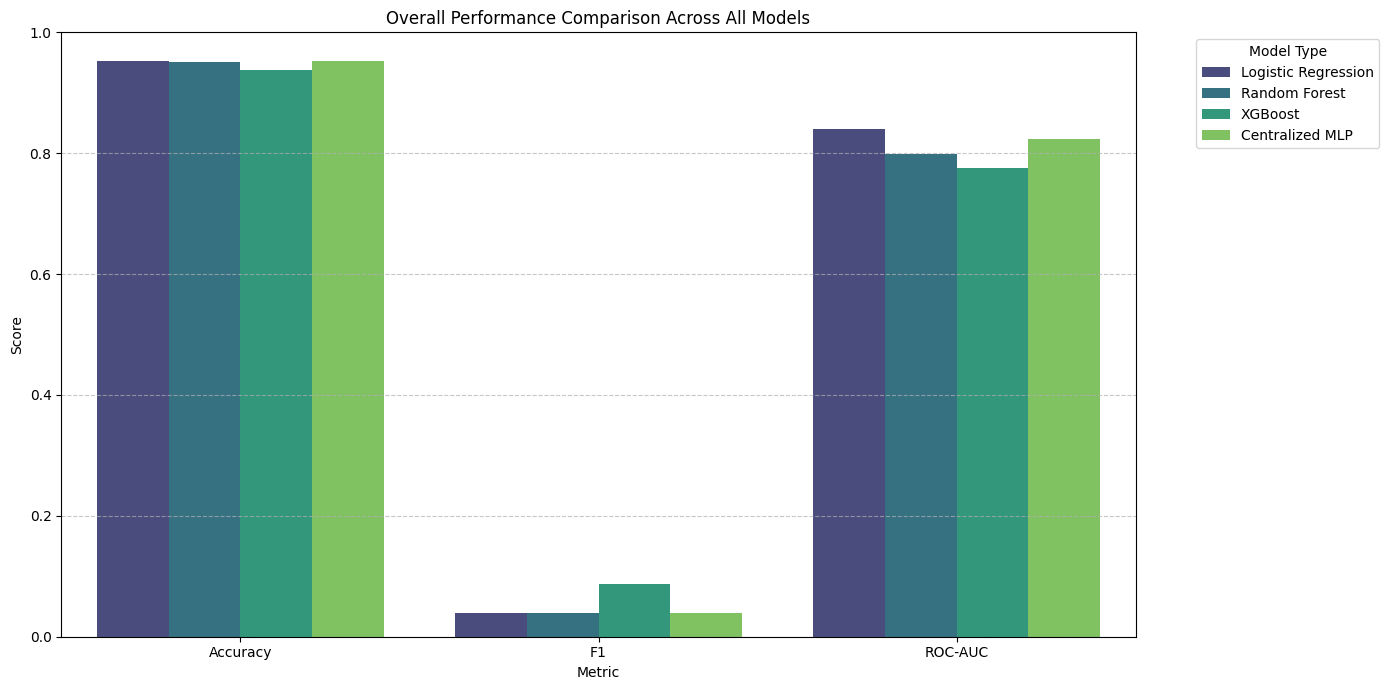

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


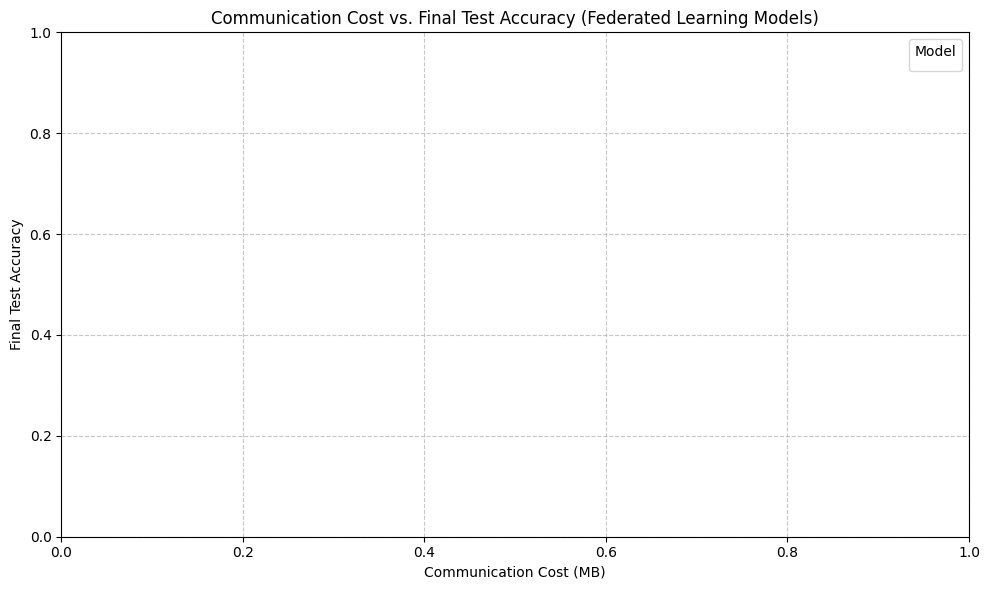

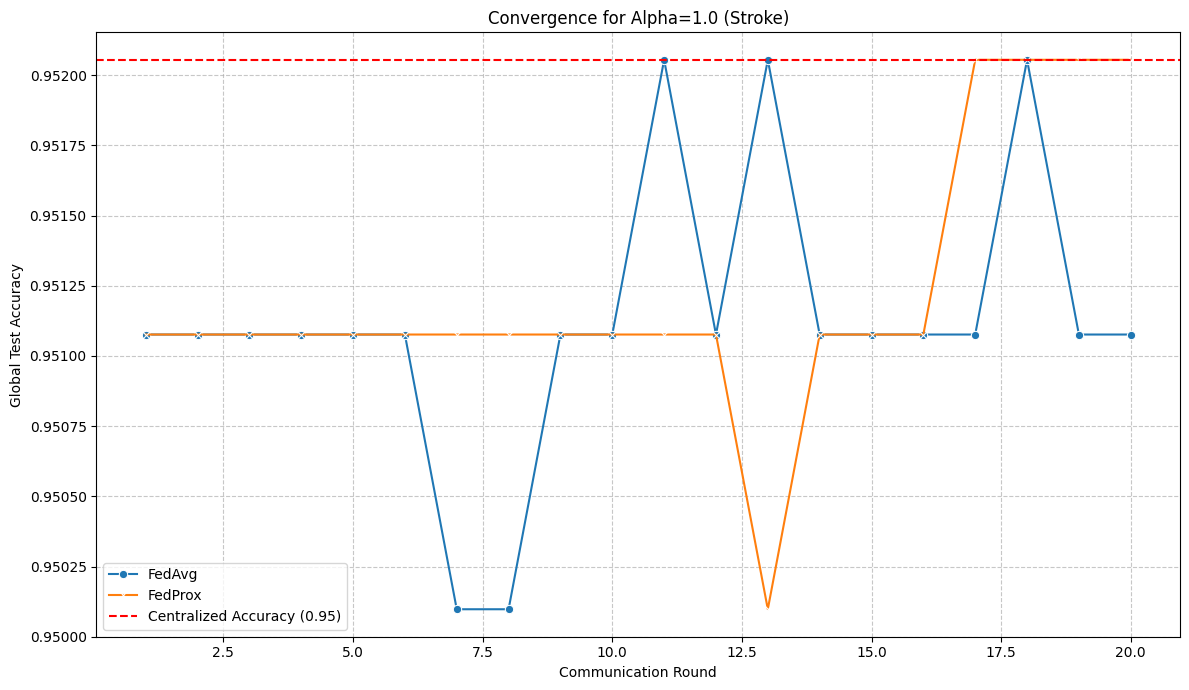

Benchmark for Stroke complete.

==================== Running Seed 2/3: 100 ====================
Random seeds set for reproducibility (Seed: 100).

Starting full benchmark for dataset: Stroke
Random seeds set for reproducibility (Seed: 100).

--- Preparing Dataset: Stroke ---
Dataset 'stroke' prepared: X_train.shape=(4087, 15), X_test.shape=(1022, 15), input_dim=15

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.1637, Current LR: 0.001000
  Epoch 20/100, Validation Loss: 0.1451, Current LR: 0.000250
  Early stopping at epoch 21

  Centralized MLP Test Metrics: {'Accuracy': 0.9510763209393346, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC-AUC': np.float64(0.8222427983539095)}
  Centralized MLP Training Time: 5.62 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/stroke/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 100...
Partitioning successful after 5 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 29.83 seconds
  Approximate communicat

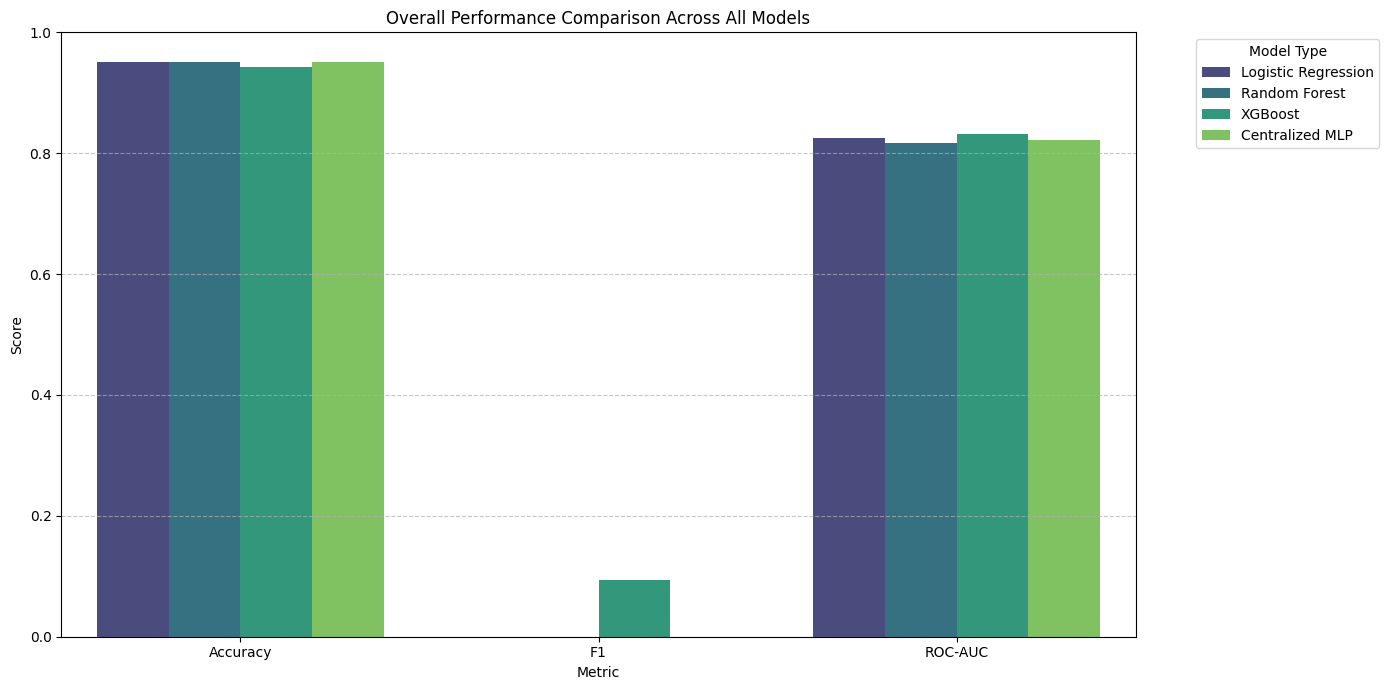

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


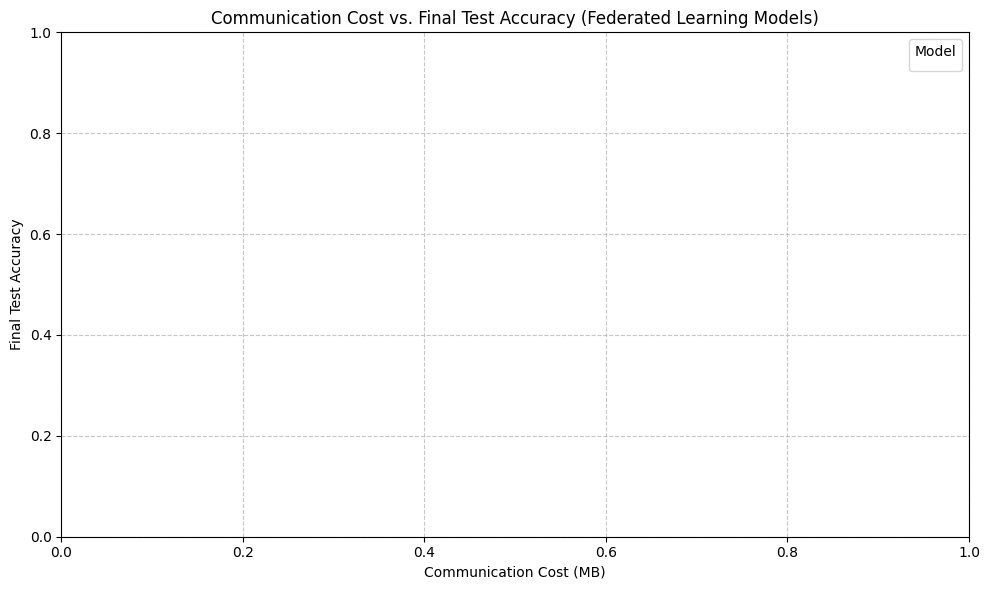

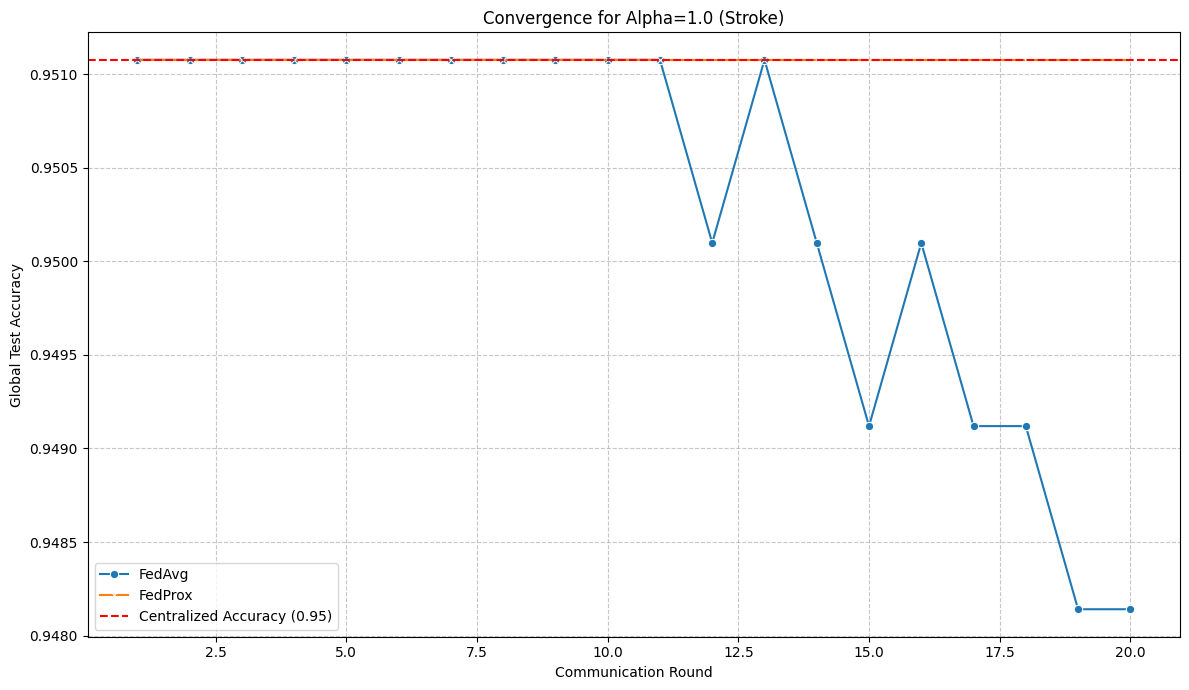

Benchmark for Stroke complete.

==================== Running Seed 3/3: 200 ====================
Random seeds set for reproducibility (Seed: 200).

Starting full benchmark for dataset: Stroke
Random seeds set for reproducibility (Seed: 200).

--- Preparing Dataset: Stroke ---
Dataset 'stroke' prepared: X_train.shape=(4087, 15), X_test.shape=(1022, 15), input_dim=15

--- Running Classical ML Baselines ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:15:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classical ML Baselines complete.

--- Running Centralized MLP ---

--- Starting Centralized MLP Training ---
  Epoch 1/100, Validation Loss: 0.1875, Current LR: 0.001000
  Early stopping at epoch 14

  Centralized MLP Test Metrics: {'Accuracy': 0.9510763209393346, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC-AUC': np.float64(0.8534979423868312)}
  Centralized MLP Training Time: 3.89 seconds
  Centralized model saved to /content/drive/MyDrive/federated_learning/results/stroke/centralized_model.pth
  Centralized metrics saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/centralized_metrics.csv
Centralized MLP complete.

--- Running Federated Learning Experiments (FedAvg & FedProx) ---

Starting FedAvg experiment (alpha=0.3, mu=0.0, lr=0.001, bs=32, epochs=5) with seed 200...
Partitioning successful after 1 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 29.39 seconds
  Approximate communication cost: 1.20 MB

Starting FedProx experiment (alpha=0.3, mu=

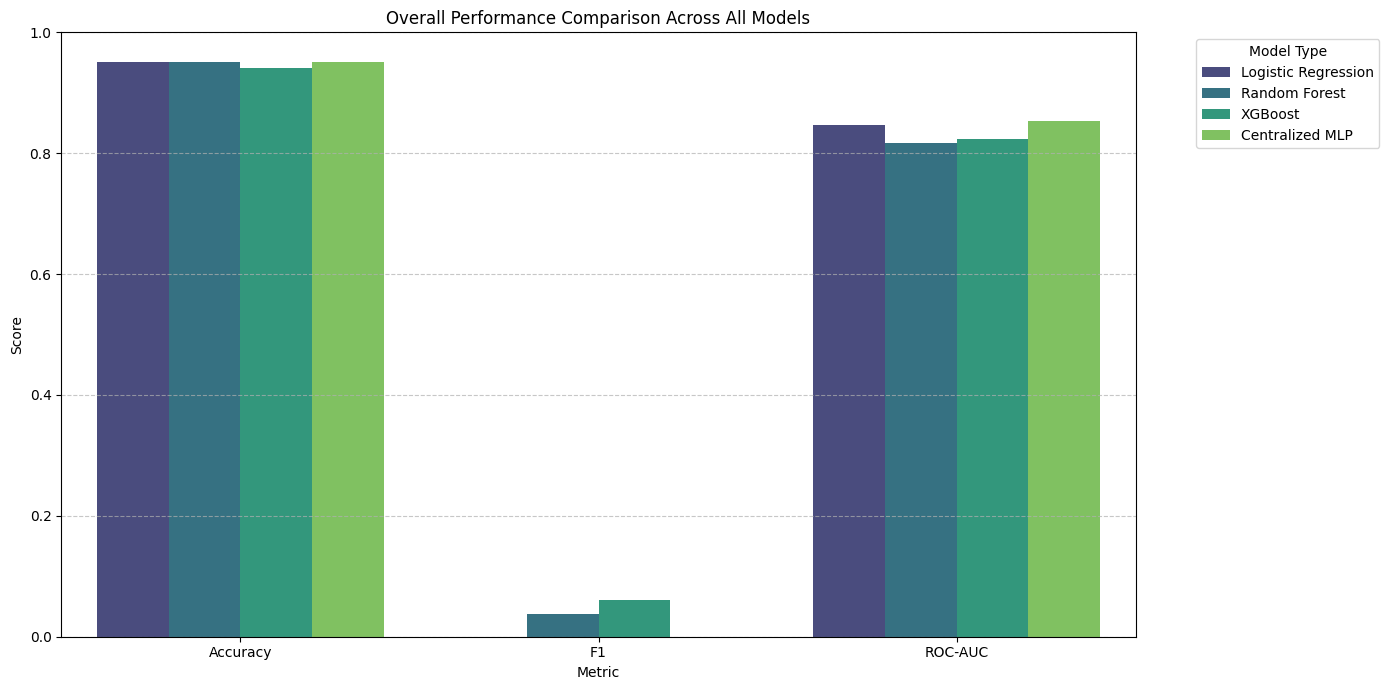

/tmp/ipykernel_630/3503771376.py:59: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_630/3503771376.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')


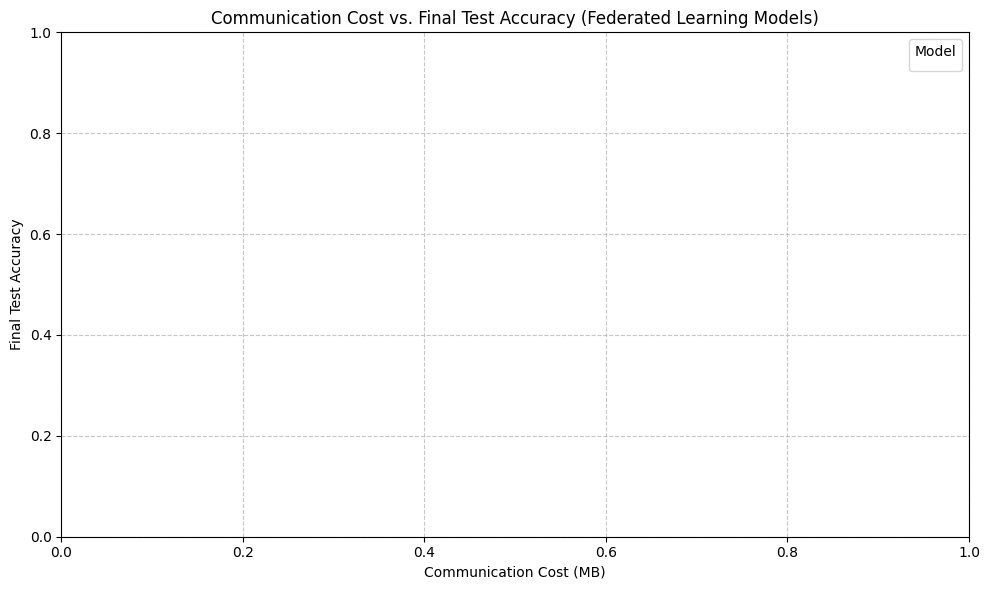

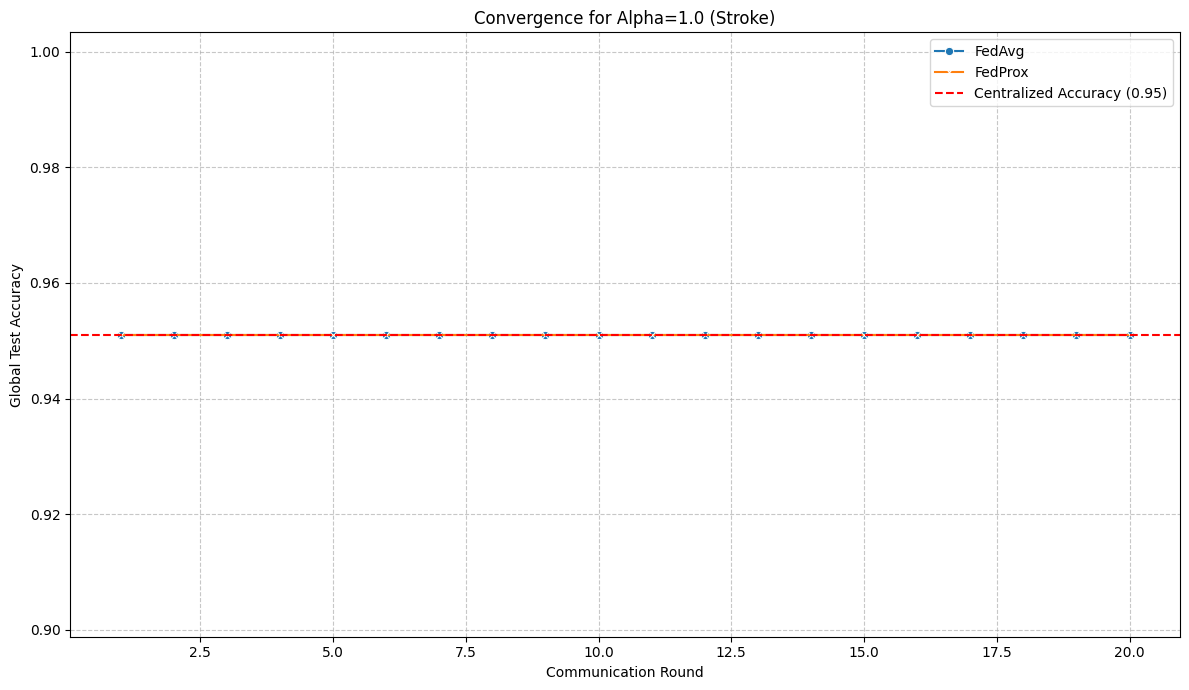

Benchmark for Stroke complete.
Aggregated multi-seed metrics saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/multi_seed_aggregated_metrics.csv
Raw multi-seed comparison data saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/multi_seed_raw_comparison.csv
Raw multi-seed convergence data saved to /content/drive/MyDrive/federated_learning/results/stroke/csvs/multi_seed_raw_convergence.csv
Multi-seed benchmark for Stroke complete.

Starting Local Epoch Ablation for Stroke (FedAvg)

--- Preparing Dataset: Stroke ---
Dataset 'stroke' prepared: X_train.shape=(4087, 15), X_test.shape=(1022, 15), input_dim=15

--- Running FedAvg with Local Epochs = 3 (Alpha=1.0, Mu=0.0) ---

Starting FedAvg experiment (alpha=1.0, mu=0.0, lr=0.001, bs=32, epochs=3) with seed 42...
Partitioning successful after 1 attempt(s) with min_client_size=20.
  Total FedAvg runtime: 18.15 seconds
  Approximate communication cost: 1.20 MB

--- Running FedAvg with Local Epochs = 5 (A

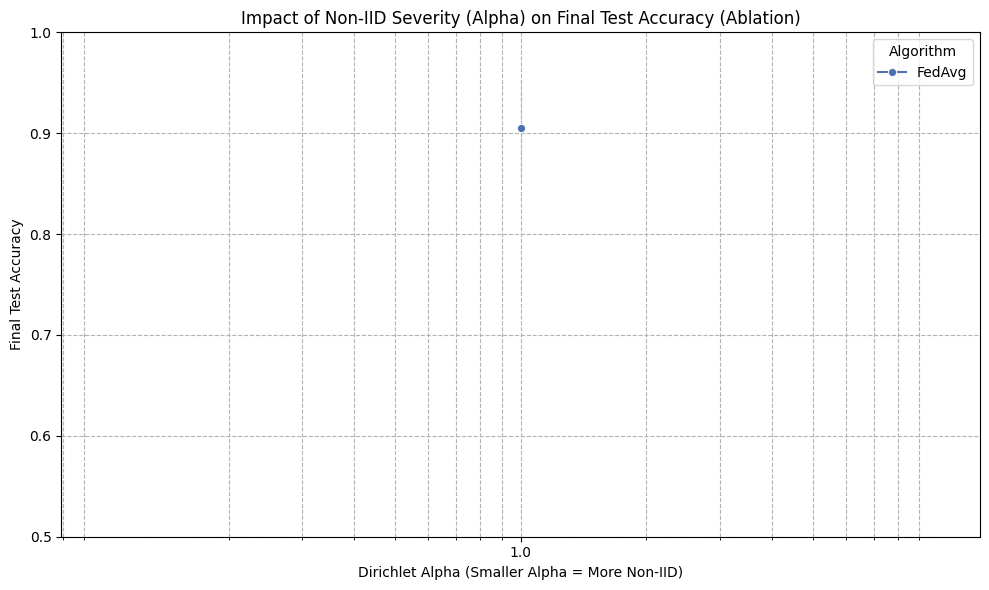

Generated ablation: Accuracy vs Alpha plot.


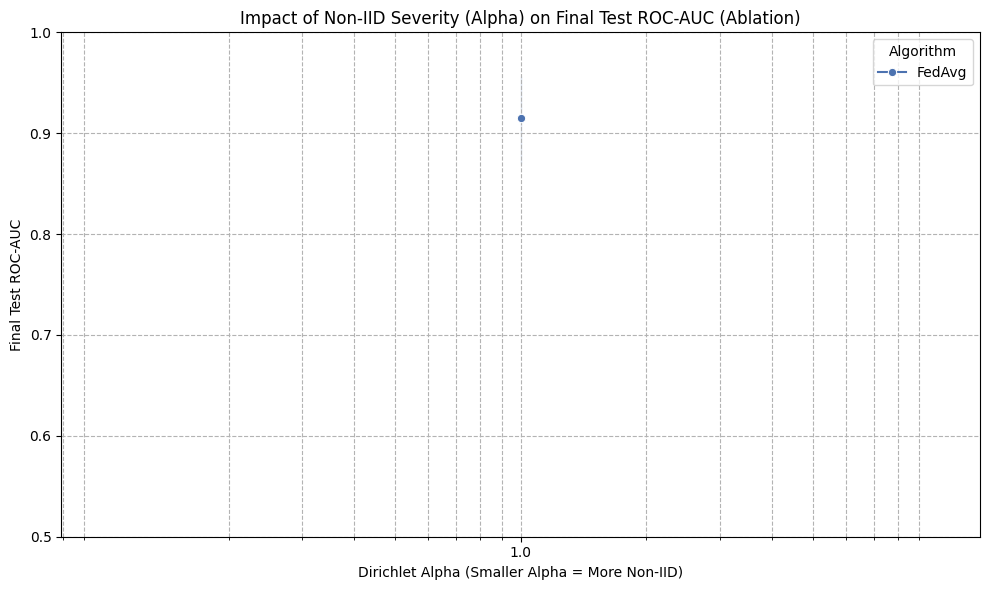

Generated ablation: ROC-AUC vs Alpha plot.


/tmp/ipykernel_630/1882687493.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev


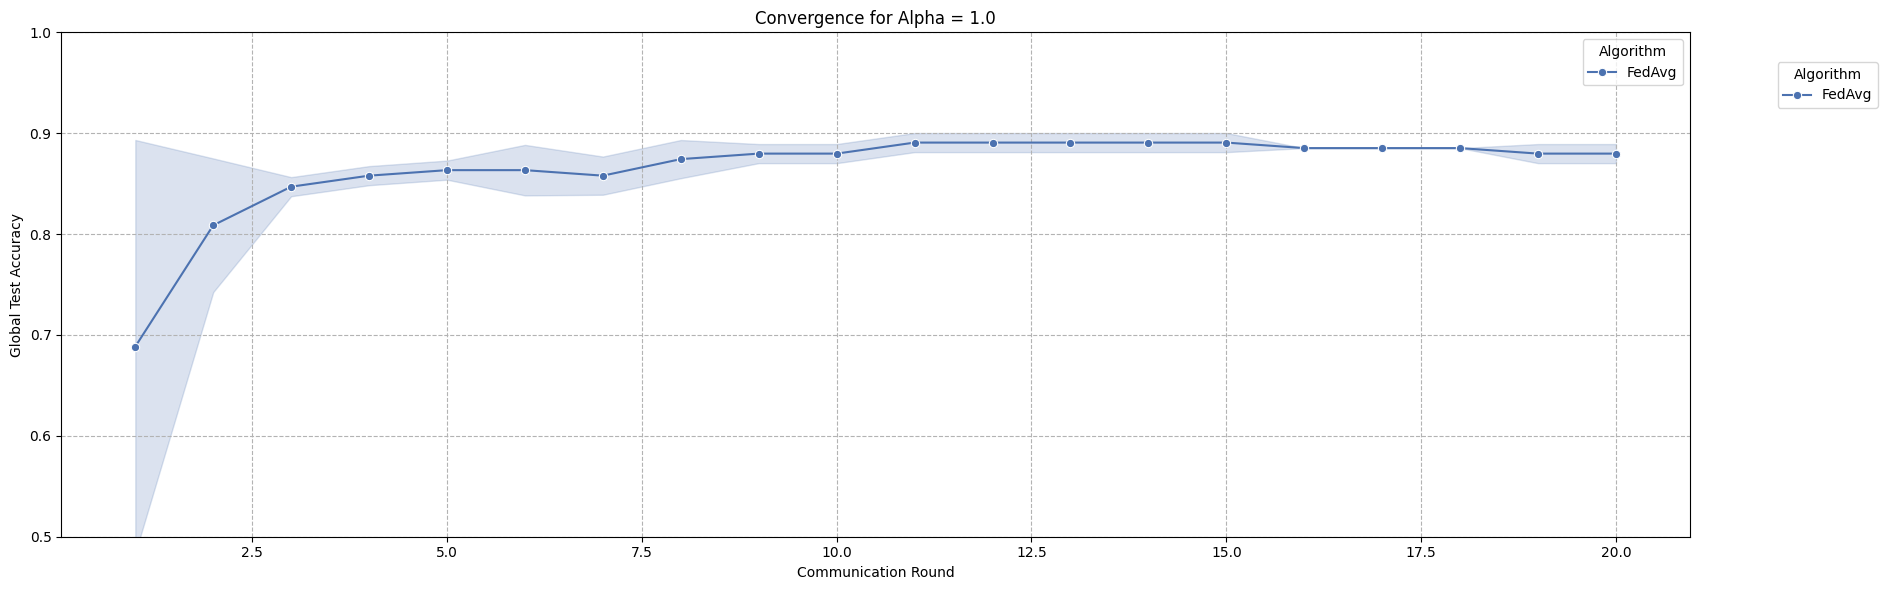

Generated ablation: Convergence plots for heart by Alpha.


/tmp/ipykernel_630/1882687493.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev


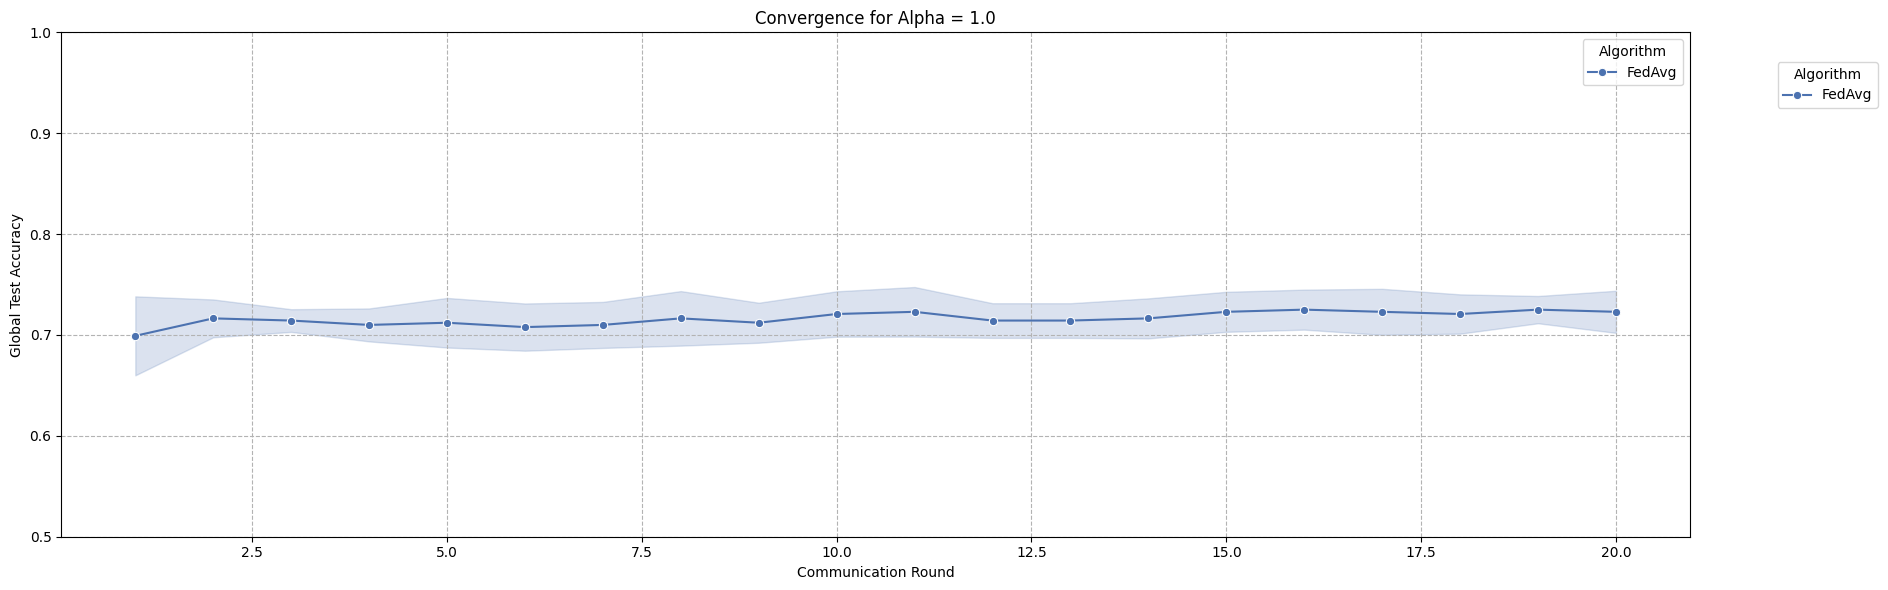

Generated ablation: Convergence plots for pima by Alpha.


/tmp/ipykernel_630/1882687493.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev


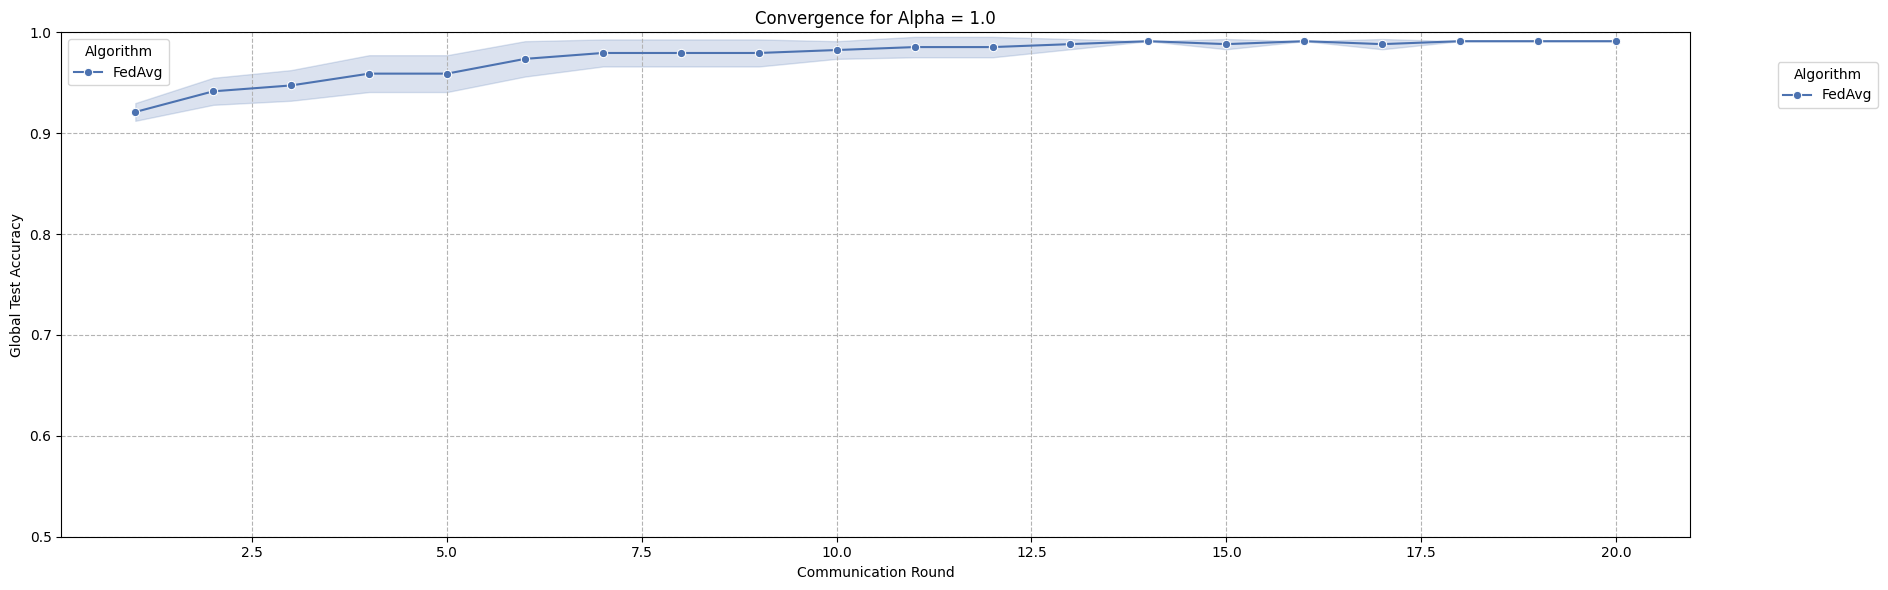

Generated ablation: Convergence plots for breast_cancer by Alpha.


/tmp/ipykernel_630/1882687493.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev


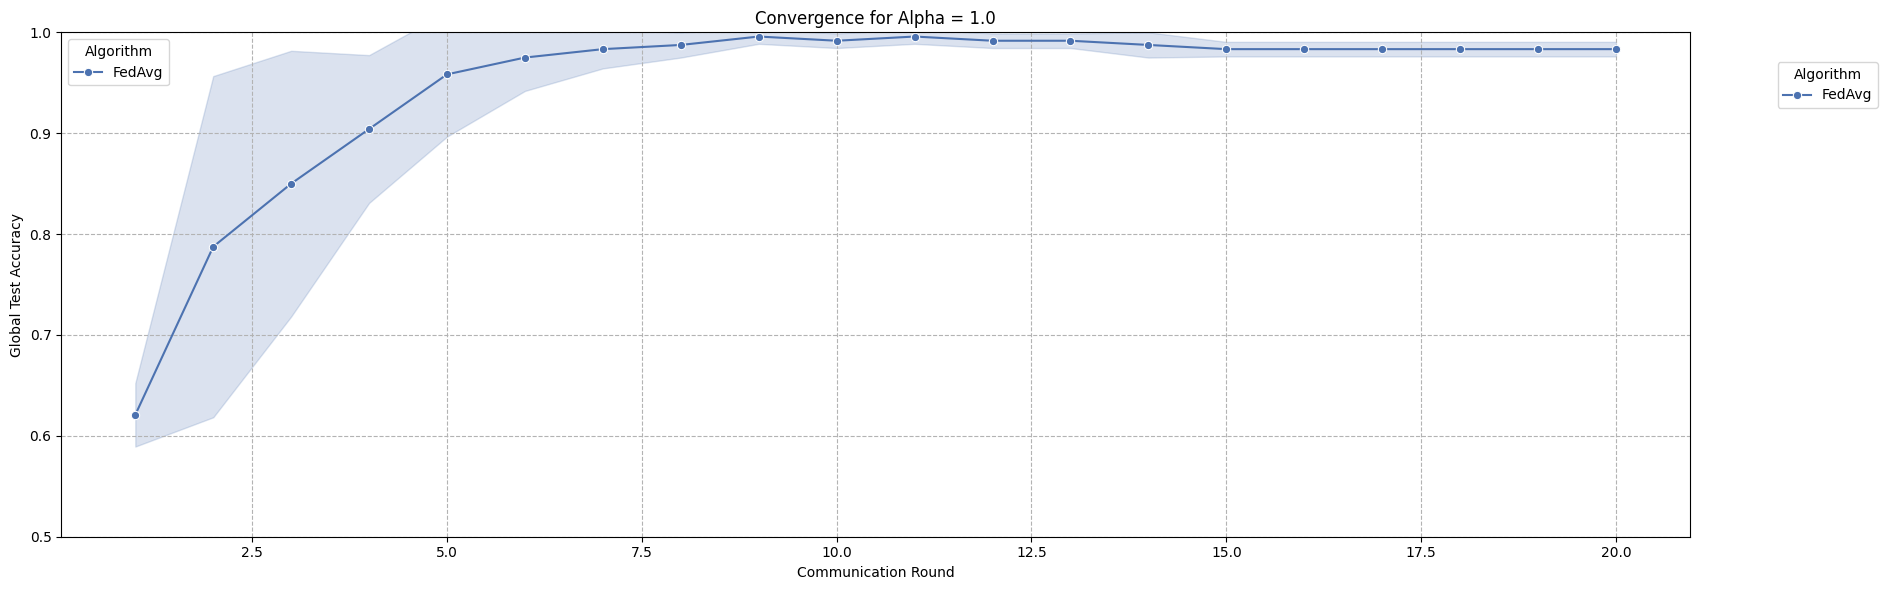

Generated ablation: Convergence plots for kidney by Alpha.


/tmp/ipykernel_630/1882687493.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd') # Plot with std dev


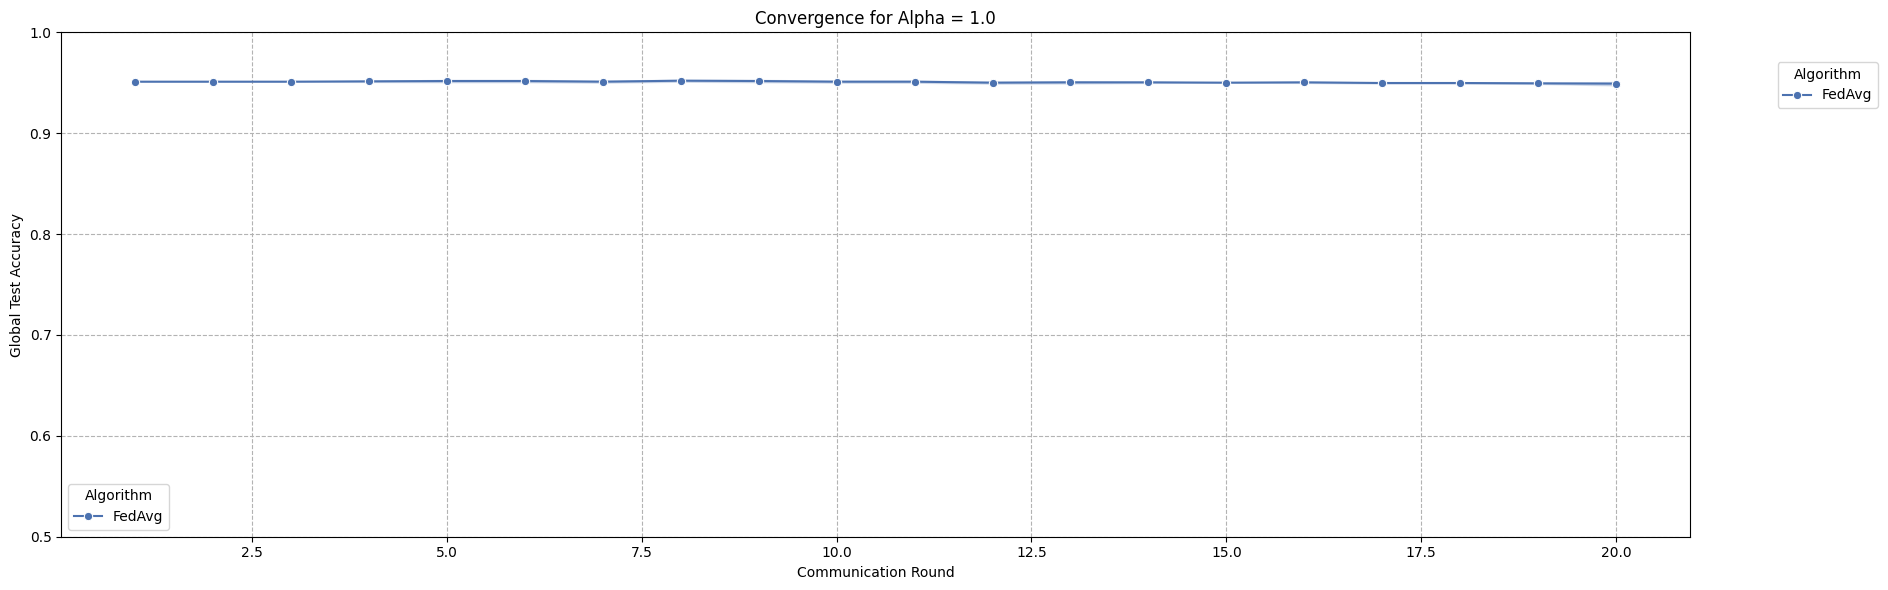

Generated ablation: Convergence plots for stroke by Alpha.


/tmp/ipykernel_630/1882687493.py:115: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=local_epoch_df, x='Local Epochs', y='Accuracy', hue='Algorithm', marker='o', palette='deep', ci='sd')


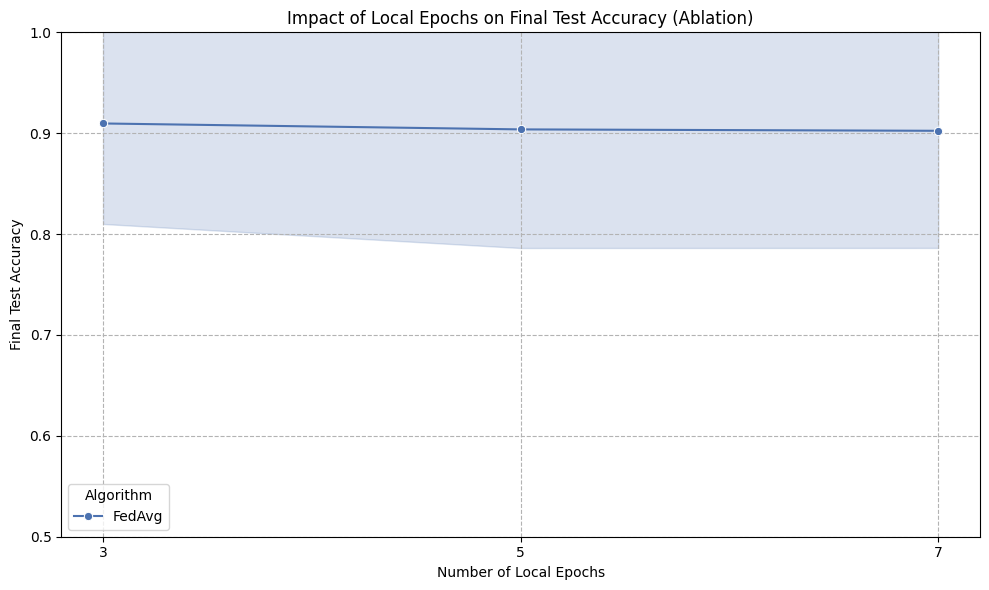

Generated ablation: Local Epochs vs Accuracy plot.


/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')


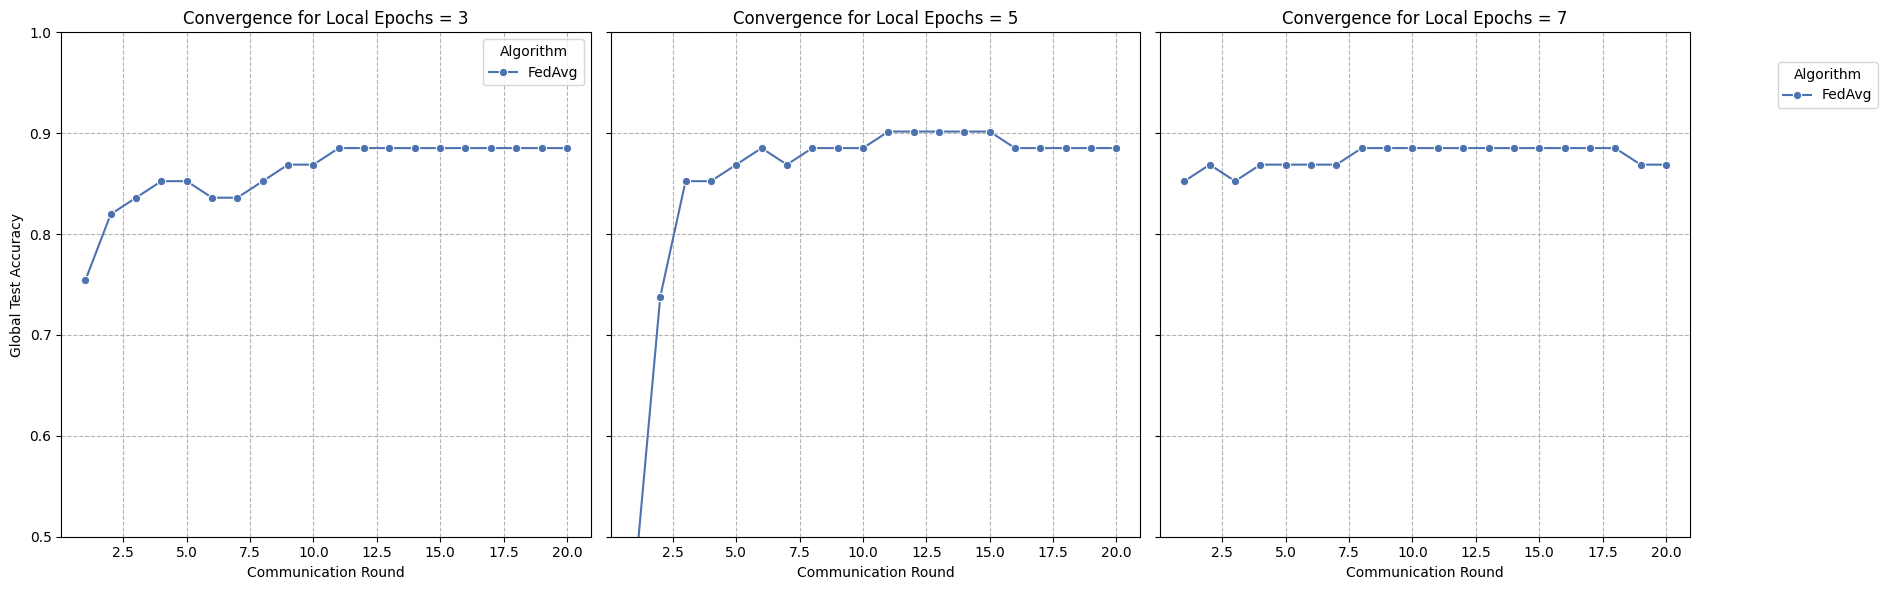

Generated ablation: Convergence plots for heart by Local Epochs.


/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')


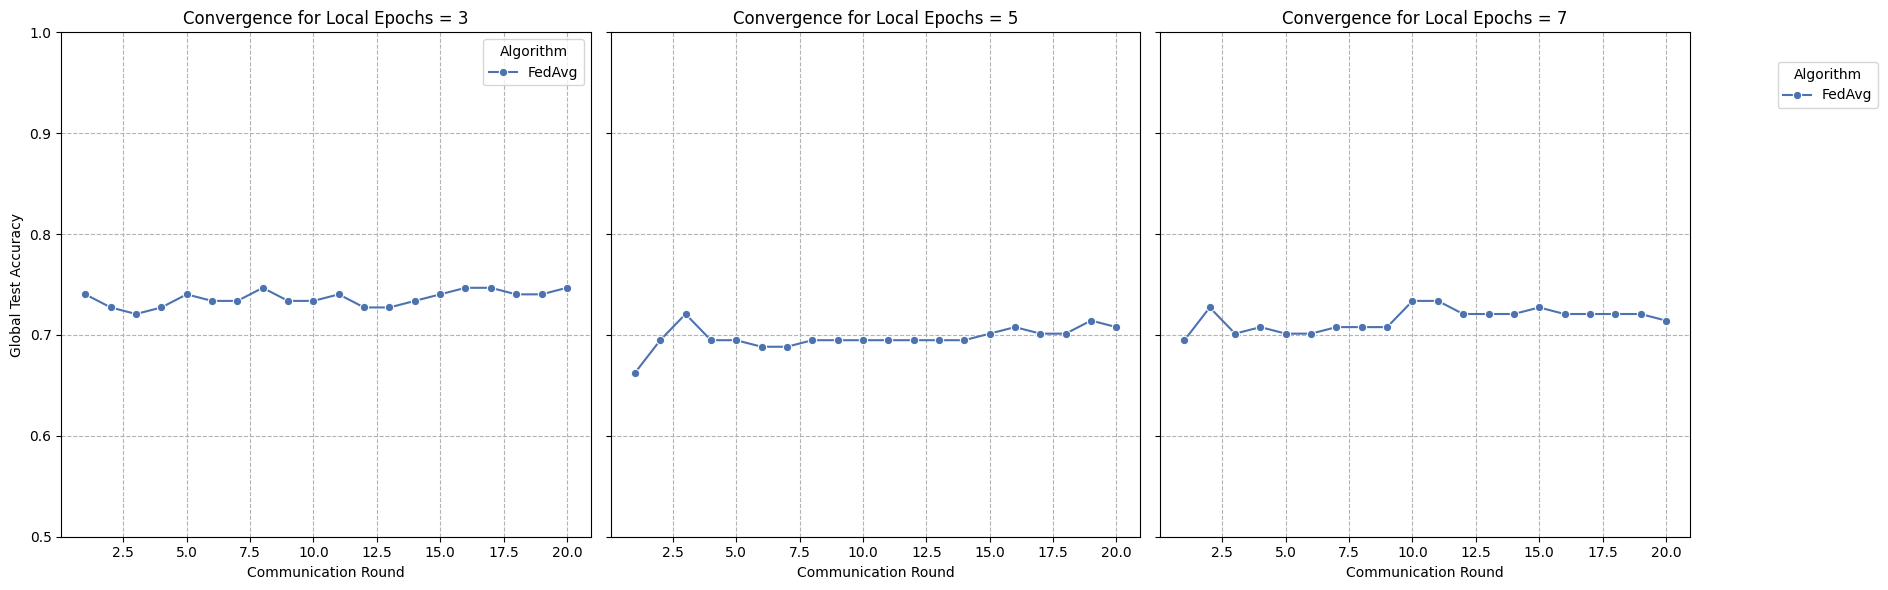

Generated ablation: Convergence plots for pima by Local Epochs.


/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')


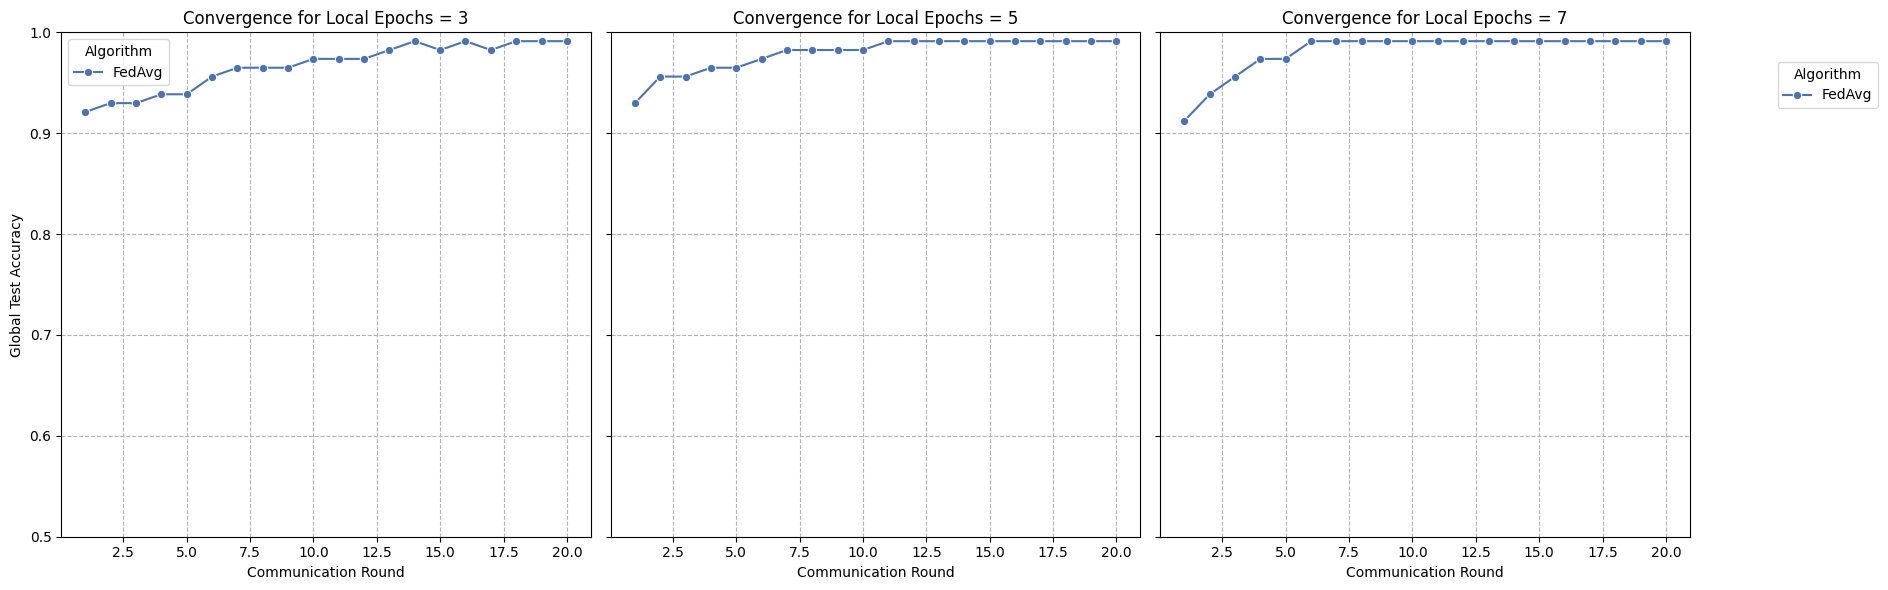

Generated ablation: Convergence plots for breast_cancer by Local Epochs.


/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')


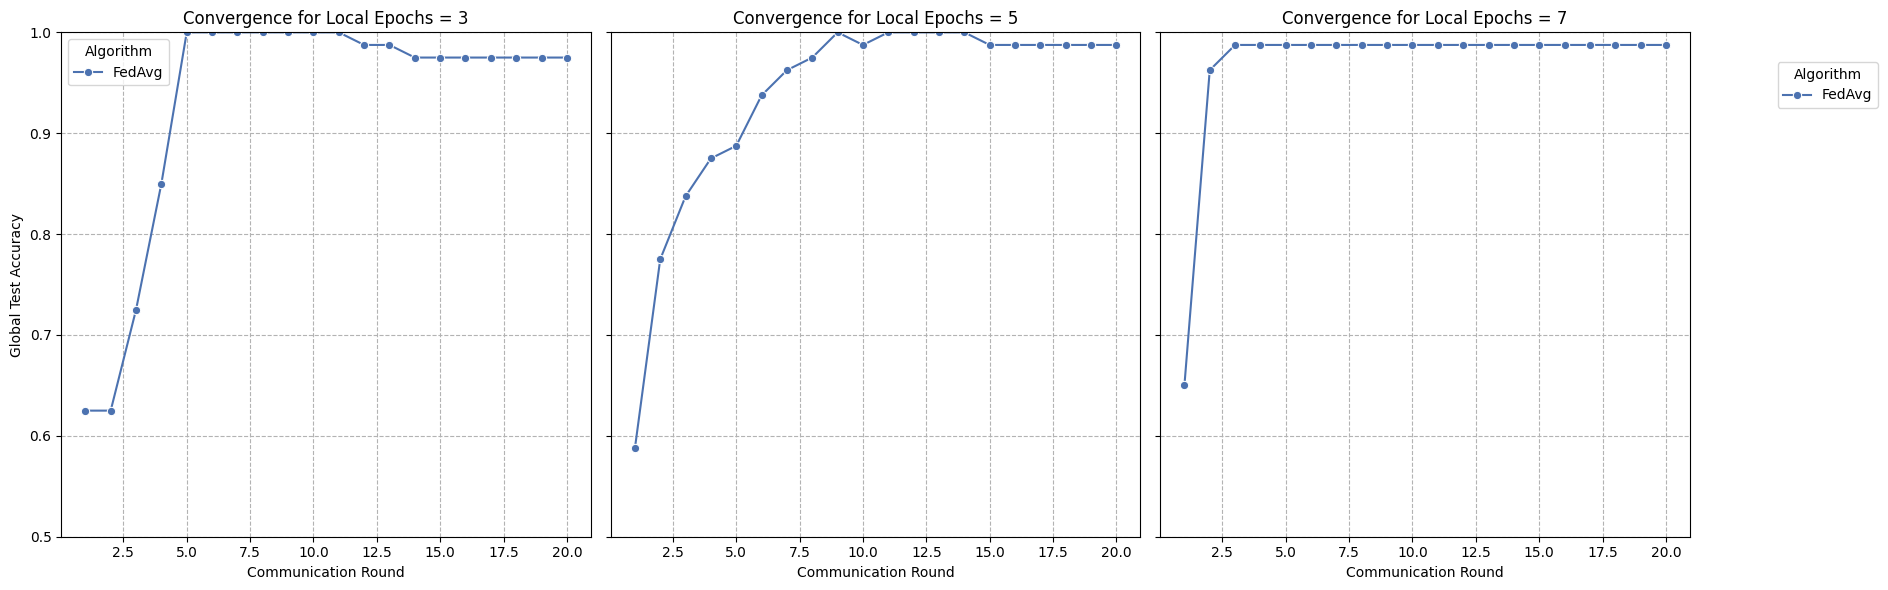

Generated ablation: Convergence plots for kidney by Local Epochs.


/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')
/tmp/ipykernel_630/1882687493.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=subset_df, x='Round', y='Accuracy', hue='Algorithm', marker='o', ax=axes[i], palette='deep', ci='sd')


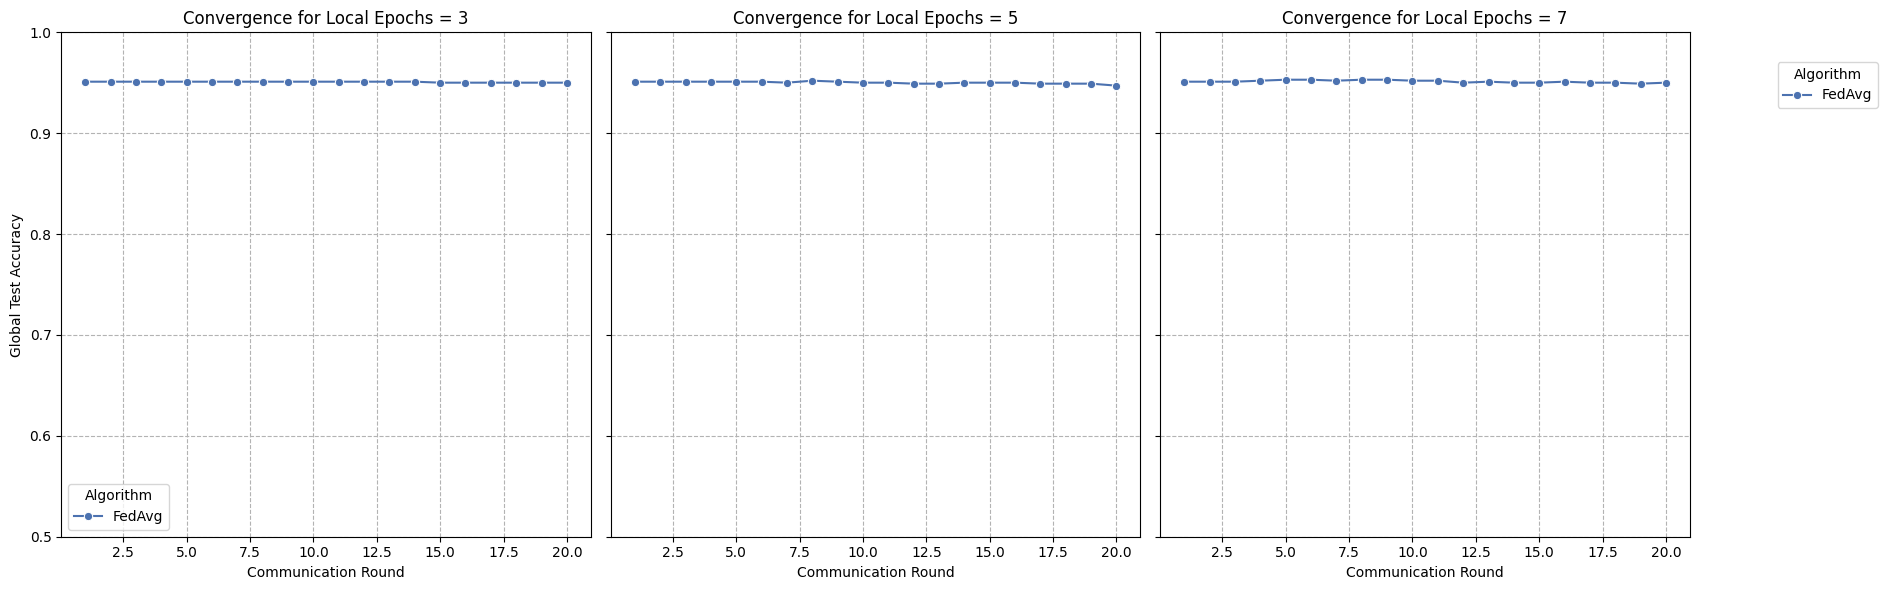

Generated ablation: Convergence plots for stroke by Local Epochs.
Skipping communication cost vs. accuracy plot: Required columns not found or no data.
Final plot generation complete.

                                      EXPORTING FINAL REPORTS                                       

--- Starting Final Report Export ---
No overall benchmark summary data to export.
Exported overall benchmark convergence history to: /content/drive/MyDrive/federated_learning/results/final_reports/benchmark_convergence_all_datasets.csv
Exported ablation study summary to: /content/drive/MyDrive/federated_learning/results/final_reports/ablation_summary_all_datasets.csv
Exported ablation study convergence history to: /content/drive/MyDrive/federated_learning/results/final_reports/ablation_convergence_all_datasets.csv
Generated comprehensive summary report to: /content/drive/MyDrive/federated_learning/results/final_reports/SUMMARY_REPORT.txt
Final report export complete.

                              MASTER

In [23]:
# 19.1: Master Benchmark Orchestrator
def run_master_benchmark(
    dataset_keys: List[str] = list(DATASET_REGISTRY.keys()),
    random_seeds: List[int] = RANDOM_SEEDS,
    fl_rounds: int = FL_ROUNDS,
    local_epochs: int = LOCAL_EPOCHS,
    learning_rate: float = LEARNING_RATE_DEFAULT,
    weight_decay: float = WEIGHT_DECAY_DEFAULT,
    batch_size: int = BATCH_SIZE_DEFAULT,
    lr_scheduler_active: bool = True,
    max_grad_norm: float = MAX_GRAD_NORM_DEFAULT,
    alpha_values: List[float] = ALPHA_VALUES,
    fedprox_mu_values: List[float] = FEDPROX_MU_VALUES,
    ablation_local_epochs: List[int] = ABLATION_LOCAL_EPOCHS,
    min_client_size_partition: int = MIN_CLIENT_SIZE_DEFAULT,
    max_attempts_partition: int = MAX_ATTEMPTS_PARTITION,
    results_base_dir: str = RESULTS_DIR
):
    """
    Orchestrates the entire multi-dataset, multi-seed federated learning benchmark,
    including classical ML, centralized DL, FedAvg, FedProx, ablation studies,
    and final plot generation.
    """
    print(f"\n{'='*100}\n{'STARTING MASTER BENCHMARK ORCHESTRATION'.center(100)}\n{'='*100}")

    overall_all_dataset_summary = []
    overall_all_dataset_convergence = []
    overall_all_ablation_summary = []
    overall_all_ablation_convergence = []

    for dataset_key in dataset_keys:
        print(f"\n{'#'*80}\n{'PROCESSING DATASET: ' + dataset_key.replace('_', ' ').upper().center(76)}\n{'#'*80}")

        # --- Run Multi-Seed Benchmark for overall performance comparison ---
        multi_seed_results = run_multi_seed_benchmark(
            dataset_key=dataset_key,
            random_seeds=random_seeds,
            fl_rounds=fl_rounds,
            local_epochs=local_epochs,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            batch_size=batch_size,
            lr_scheduler_active=lr_scheduler_active,
            max_grad_norm=max_grad_norm,
            alpha_values=alpha_values,
            fedprox_mu_values=fedprox_mu_values,
            min_client_size_partition=min_client_size_partition,
            max_attempts_partition=max_attempts_partition,
            results_base_dir=results_base_dir
        )

        if multi_seed_results:
            # Add dataset info to the aggregated metrics from multi-seed
            aggregated_metrics_df = multi_seed_results['aggregated_metrics']
            aggregated_metrics_df['Dataset'] = dataset_key
            overall_all_dataset_summary.append(aggregated_metrics_df)

            # Raw convergence data will also need dataset key
            raw_convergence_df = multi_seed_results['raw_convergence_data']
            raw_convergence_df['Dataset'] = dataset_key
            overall_all_dataset_convergence.append(raw_convergence_df)

        # --- Run Local Epoch Ablation Study ---
        local_epoch_ablation_results = run_local_epoch_ablation(
            dataset_key=dataset_key,
            local_epoch_values=ablation_local_epochs,
            alpha=1.0, # Typically run on IID or a fixed non-IID setting for this ablation
            algorithm='FedAvg', # Run FedAvg for local epoch ablation
            random_seed=RANDOM_SEED, # Use the primary random seed for this
            fl_rounds=fl_rounds,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            batch_size=batch_size,
            lr_scheduler_active=lr_scheduler_active,
            max_grad_norm=max_grad_norm,
            min_client_size_partition=min_client_size_partition,
            max_attempts_partition=max_attempts_partition,
            results_base_dir=results_base_dir
        )

        if local_epoch_ablation_results:
            ablation_summary_df = local_epoch_ablation_results['ablation_summary']
            ablation_convergence_df = local_epoch_ablation_results['ablation_convergence']
            overall_all_ablation_summary.append(ablation_summary_df)
            overall_all_ablation_convergence.append(ablation_convergence_df)

    # --- Consolidate all collected results ---
    final_all_dataset_summary_df = pd.concat(overall_all_dataset_summary, ignore_index=True) if overall_all_dataset_summary else pd.DataFrame()
    final_all_dataset_convergence_df = pd.concat(overall_all_dataset_convergence, ignore_index=True) if overall_all_dataset_convergence else pd.DataFrame()
    final_all_ablation_summary_df = pd.concat(overall_all_ablation_summary, ignore_index=True) if overall_all_ablation_summary else pd.DataFrame()
    final_all_ablation_convergence_df = pd.concat(overall_all_ablation_convergence, ignore_index=True) if overall_all_ablation_convergence else pd.DataFrame()

    print(f"\n{'='*100}\n{'GENERATING FINAL PLOTS'.center(100)}\n{'='*100}")
    # --- Generate all final plots ---
    generate_final_plots(
        final_all_dataset_summary_df,
        final_all_dataset_convergence_df,
        final_all_ablation_summary_df,
        final_all_ablation_convergence_df,
        results_base_dir
    )

    print(f"\n{'='*100}\n{'EXPORTING FINAL REPORTS'.center(100)}\n{'='*100}")
    # --- Export final reports ---
    export_final_reports(
        final_all_dataset_summary_df,
        final_all_dataset_convergence_df,
        final_all_ablation_summary_df,
        final_all_ablation_convergence_df,
        results_base_dir
    )

    print(f"\n{'='*100}\n{'MASTER BENCHMARK ORCHESTRATION COMPLETE'.center(100)}\n{'='*100}")

# Call the master benchmark orchestrator to run the entire process
print("Calling run_master_benchmark() to start the full process...")
run_master_benchmark()